# **PROJECT Titanic Survival Analysis**

# PART A - Data Loading and Exploration </mark>

>The objective of Part A – Data Loading and Exploration is to perform an initial diagnosis of the Titanic dataset through Exploratory Data Analysis (EDA) and descriptive metrics.

## 1.Download and Load Data 

>In the code below, we will install the necessary dependencies in Fabric to run the code.

In [ ]:
# Configuration in Microsoft Fabric

%matplotlib inline
%pip install seaborn shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 6.1 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


>Below are the imports that will be used throughout all stages of the project.

In [ ]:
# Data manipulation and visualization
import pandas as pd #DataFrames
import numpy as np #Mathematical and numerical operations
import matplotlib.pyplot as plt #Basic plotting
import seaborn as sns #Advanced statistical visualizations

# Statistics and Monitorization
import shap #Model interpretability (explaining predictions)
import mlflow #Logging and tracking of experiments and models
from scipy.stats import chi2_contingency #Chi-Square Independence Test

# Preprocessing and Pipelines
from sklearn.pipeline import Pipeline #Sequential organization of model steps
from sklearn.compose import ColumnTransformer #Apply different transformations to different columns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder #Normalization and variable encoding
from sklearn.impute import SimpleImputer #Basic handling of missing values
from sklearn.base import BaseEstimator, TransformerMixin #Creation of custom transformers

# Classification Models
from sklearn.linear_model import LogisticRegression #Logistic Regressor model
from sklearn.ensemble import RandomForestClassifier #Random Forest model
from sklearn.tree import DecisionTreeClassifier #Decision tree model
from sklearn.svm import SVC #Support Vector Machine model

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge #Linear and Ridge Regression models
from sklearn.tree import DecisionTreeRegressor #Decision tree for regression
from sklearn.ensemble import RandomForestRegressor #Random Forest model for regression

# Validation and Metrics
from sklearn.model_selection import train_test_split #Splits the dataset into training and testing sets
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)   #Metrics for evaluating classification models
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score #Metrics for evaluating regression models
from itertools import product # Generates all possible combinations between lists
from sklearn.model_selection import GridSearchCV, StratifiedKFold, KFold, RepeatedStratifiedKFold, RepeatedKFold, cross_val_score #Tools for cross-validation and hyperparameter optimization
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score #Metrics for evaluating regression


In [ ]:
# Reading the training dataset from the lakehouse storage

train_df = pd.read_csv("/lakehouse/default/Files/train.csv")
train_df.head(10)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
#Initial data exploration

train_df.info()
train_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


(891, 12)

The Titanic dataset contains 891 observations and 12 variables, including both numerical and categorical features such as Age, Fare, Sex, and Pclass. From an initial analysis, it is possible to identify the presence of missing values in some variables, namely Age, Cabin, and Embarked.
</p>

## 2.Exploratory Data Analysis

In [5]:
train_df.describe() 

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<p>
The dataset includes 891 passengers, with a survival rate of 38%, meaning most individuals did not survive. The average age is around 30, though some values are missing. Most passengers traveled in 3rd class, reflecting lower socioeconomic status.

The Fare variable shows a skewed distribution with notable outliers. Family‑related features (SibSp and Parch) have low averages, indicating that most passengers traveled alone.
</p>

### Target Variables

Text(0.5, 1.0, 'Distribuição da Idade dos Passageiros')

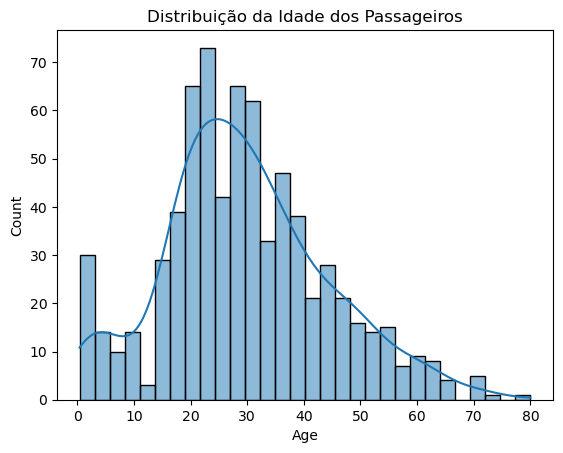

In [6]:
sns.histplot(data=train_df, x="Age", bins=30, kde=True)
plt.title("Distribuição da Idade dos Passageiros")

>The age distribution is right‑skewed, with most passengers between 20 and 40 years old. Fewer children and elderly passengers appear, and older ages create a long right tail.

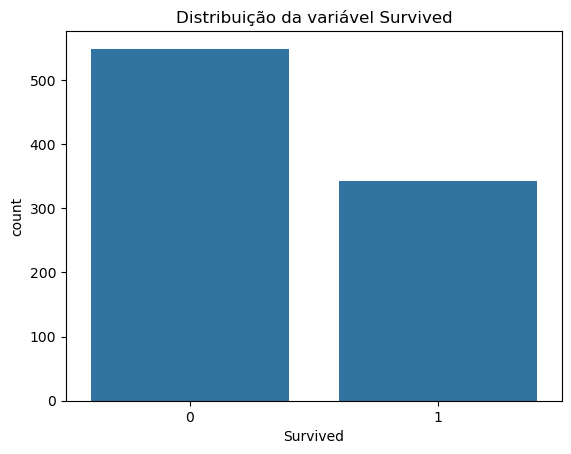

In [7]:
sns.countplot(x="Survived", data=train_df)
plt.title("Distribuição da variável Survived")
plt.show()

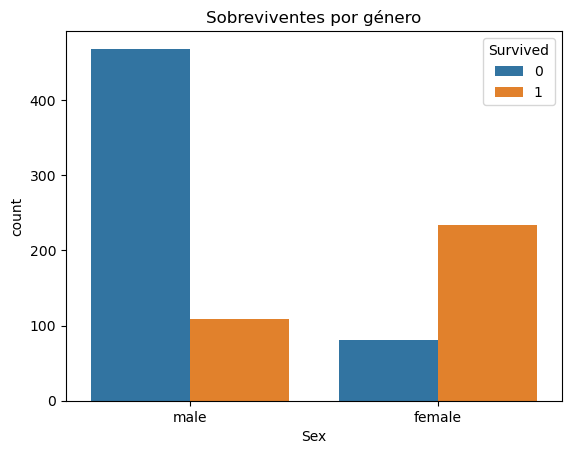

In [ ]:
# Comparison of the feature 'Sex' with the target 'Survived'
sns.countplot(x="Sex", hue="Survived", data=train_df)
plt.title("Sobreviventes por género")
plt.show()

> The chart shows that women had a significantly higher survival rate than men.

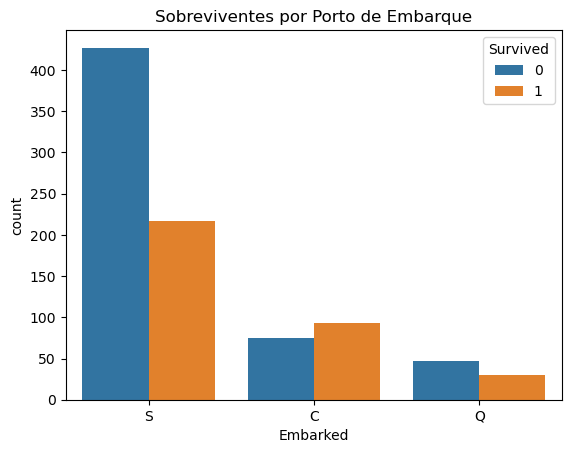

In [9]:
sns.countplot(x="Embarked", hue="Survived", data=train_df)
plt.title("Sobreviventes por Porto de Embarque")
plt.show()

>Most passengers boarded in Southampton (S), while Queenstown (Q) had far fewer. Cherbourg (C) shows a relatively higher proportion of survivors. These differences may be influenced by other factors, such as passenger class.

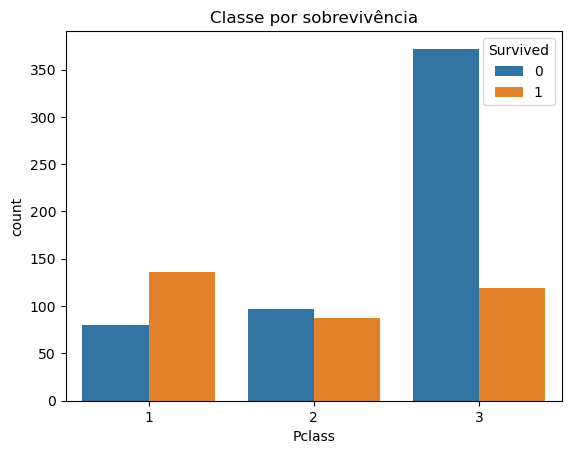

In [10]:
sns.countplot(x="Pclass", hue="Survived", data=train_df)
plt.title("Classe por sobrevivência")
plt.show()

>The proportion of survivors varies significantly across passenger classes. First‑class passengers show a higher survival rate, while third‑class passengers have a much larger share of non‑survivors.

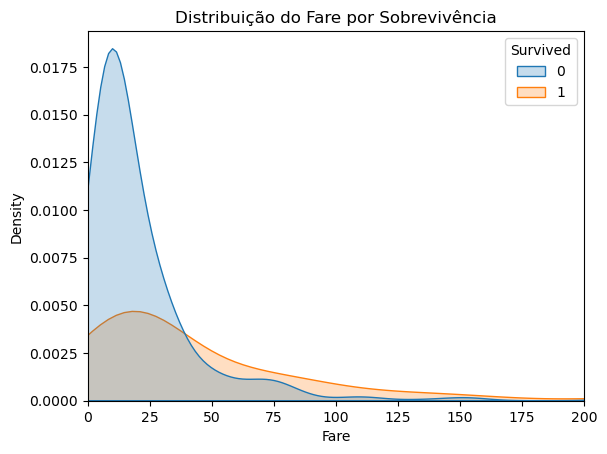

In [11]:
sns.kdeplot(data=train_df, x="Fare", hue="Survived", fill=True)
plt.xlim(0, 200) 
plt.title("Distribuição do Fare por Sobrevivência")
plt.show()

>The distribution of Fare shows clear differences between survivors and non‑survivors. Survivors generally paid higher fares, while non‑survivors are concentrated at lower values.
>This suggests that ticket price — and therefore socioeconomic class — may have influenced survival probability. The distribution is also right‑skewed, indicating the presence of extreme values.

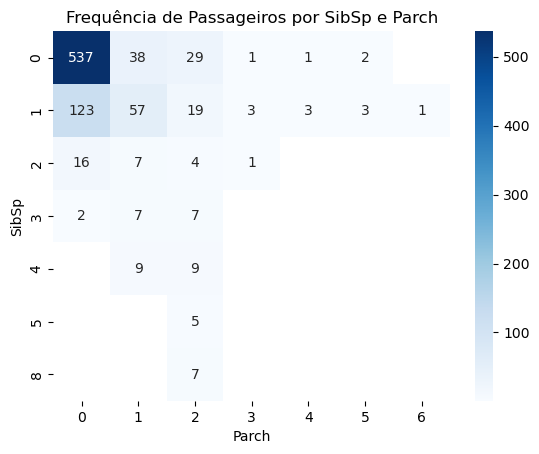

In [12]:
pivot = train_df.pivot_table(
    index="SibSp",
    columns="Parch",
    values="PassengerId",
    aggfunc="count"
)

sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues")
plt.title("Frequência de Passageiros por SibSp e Parch")
plt.show()

>Most passengers have zero values in both variables, indicating that the majority traveled alone. Small family groups appear in combinations such as (1,0), (0,1), and (1,1), while large families are rare in the dataset.
>Although SibSp and Parch represent different types of family relationships, the plot suggests they capture a similar underlying concept: the presence and size of a family group on board. This also indicates that the information may be split across both variables, making their individual impact harder to interpret.

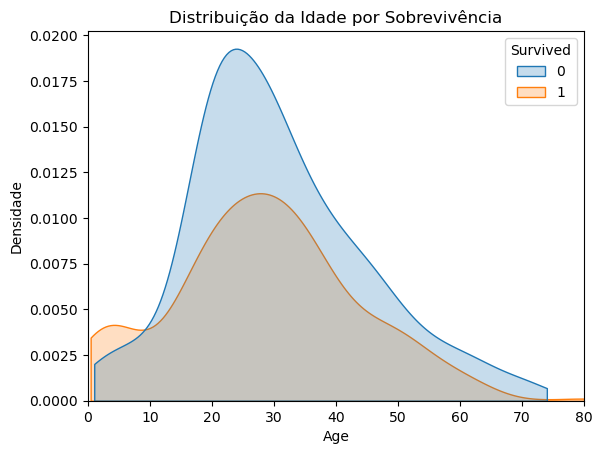

In [13]:
sns.kdeplot(data=train_df, x="Age", hue="Survived", fill=True, cut=0)

plt.xlim(0, train_df["Age"].max())
plt.title("Distribuição da Idade por Sobrevivência")
plt.xlabel("Age")
plt.ylabel("Densidade")

plt.show()

>The relationship between age and survival is not linear, with different patterns emerging across age groups. Younger passengers show distinct survival behaviors compared to adults and the elderly.
>This suggests the presence of meaningful age segments, making structured age intervals more relevant for analysis.

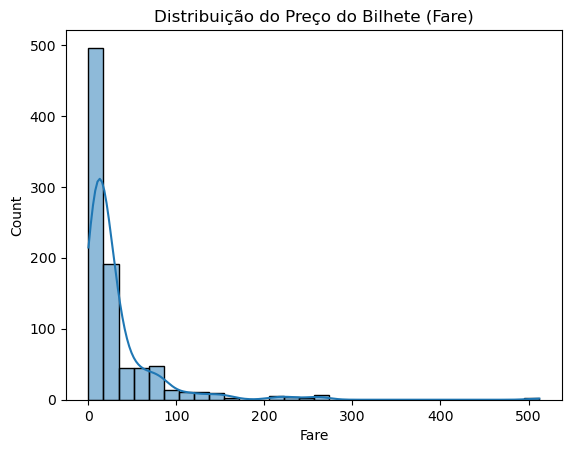

In [14]:
sns.histplot(train_df["Fare"], bins=30, kde=True)
plt.title("Distribuição do Preço do Bilhete (Fare)")
plt.show()

>The Fare variable is highly right‑skewed. In Part C, since we will use models sensitive to scale and linearity—such as Logistic Regression and Support Vector Machines—we will apply a log transformation to Fare. This helps reduce skewness, lessen the impact of extreme values, and produce a distribution closer to normality, improving model stability and performance.

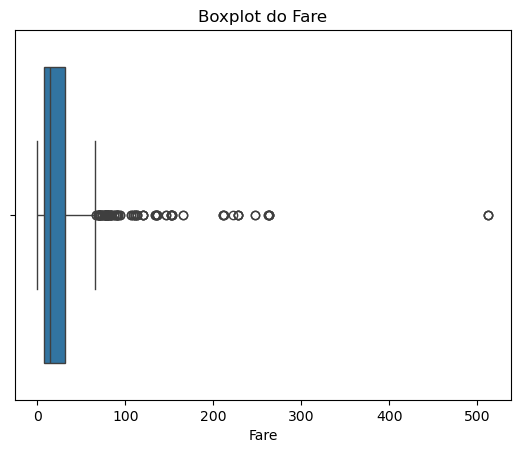

In [16]:
sns.boxplot(x=train_df["Fare"])
plt.title("Boxplot do Fare")
plt.show()

>The Fare variable shows a strongly right‑skewed distribution, with most values concentrated at the lower end and a few very high outliers. The boxplot highlights this wide dispersion and the presence of extreme values. Given this behavior, grouping Fare into quantile‑based categories is appropriate, as it reduces the influence of outliers and better captures differences across price levels.

# PART B - Data Preprocessing 

## 1. Handled Missing Values

In [ ]:
# Identify Missing Values (only columns with missing entries)

missing_values = train_df.isna().sum()
print(missing_values[missing_values > 0])

Age         177
Cabin       687
Embarked      2
dtype: int64


<p>
Since the "Cabin" column contains many missing values, we created a binary variable called "HasCabin", which takes the value 1 when a cabin is recorded and 0 otherwise.
</p>

In [18]:
train_df["HasCabin"] = train_df["Cabin"].notna().astype(int) #Criação da variável binária "HasCabin"
train_df["Title"] = train_df["Name"].str.extract(r",\s*(.*?)\.", expand=False) #feature engineering para extrair apenas o título social

<p>
At this stage of the project, missing-value imputation was not performed yet, as all imputations were applied later within each model’s baseline pipeline to avoid data leakage. The strategy was defined based on preliminary tests using the Logistic Regression (LR) model.

For this first model, we evaluated different approaches for imputing missing values in the Age variable. Several predefined strategies were tested and compared using model performance. The best result (ROC_AUC = 0.871811) was obtained by imputing Age using the median within Age–Title groups.

For the Embarked variable, two strategies were tested: removing rows with missing values and imputing the mode. After evaluating the predictive performance of the Logistic Regression model, removing the missing records produced a slightly better score. This approach was therefore adopted and applied consistently across all models.

Note: Detailed test strategies and results are provided in the appendix.
</p>


## 2.Handle Duplicates

In [ ]:
# Check for duplicate records (rows) in the dataset

print(train_df.duplicated().any())
print(train_df.duplicated().sum())

False
0


## 3. Feature Engineering

In [ ]:
# 1. Creation of Family, Age (AgeGroup), and Ticket Price (FareCategory) features

train_df["FamilySize"] = train_df["SibSp"] + train_df["Parch"] + 1  # Create FamilySize feature
train_df["IsAlone"] = (train_df["FamilySize"] == 1).astype(int)  # Create IsAlone feature

train_df["AgeGroup"] = pd.cut( # Create AgeGroup feature
    train_df["Age"], 
    bins=[0, 12, 19, 59, 100], 
    labels=["Child", "Teen", "Adult", "Senior"]
)
train_df["FareCategory"] = pd.qcut(  # Create FareCategory feature
    train_df["Fare"], 
    q=4, 
    labels=["Low", "Medium", "High", "Very High"]
)


# 2. Extraction and Processing of Title


# Extract title from the Name column (Mr, Mrs, Miss, Master)
train_df["Title"] = train_df["Name"].str.extract(r",\s*(.*?)\.", expand=False)


# Remove unwanted prefixes (e.g., "the")
train_df["Title"] = train_df["Title"].str.replace("the ", "", regex=False)


# Identify the 4 most frequent titles (Mr, Miss, Mrs, Master)
top4_titles = train_df["Title"].value_counts().nlargest(4).index


# Group all other titles as "Other"
train_df["Title"] = train_df["Title"].apply(lambda x: x if x in top4_titles else "Other")


# Display the resulting new columns
print(train_df[["FamilySize", "IsAlone", "AgeGroup", "FareCategory", "Title"]].head())

   FamilySize  IsAlone AgeGroup FareCategory Title
0           2        0    Adult          Low    Mr
1           2        0    Adult    Very High   Mrs
2           1        1    Adult       Medium  Miss
3           2        0    Adult    Very High   Mrs
4           1        1    Adult       Medium    Mr


## 5. Handle Outliers

<p>
For outlier detection, we applied the Interquartile Range (IQR) method, using a multiplier of 3 instead of the standard 1.5 to capture only extreme outliers. This choice is justified by the strong positive skewness of the Fare variable. Using the lower threshold (1.5) would incorrectly flag many legitimate first‑class fares as outliers, leading to unnecessary loss of information relevant for survival prediction.
</p>


🔹 Age
Lower bound: -33.50 | Upper bound: 91.62
Nº de outliers: 0

🔹 Fare
Lower bound: -61.36 | Upper bound: 100.27
Nº de outliers: 53

🔹 FamilySize
Lower bound: -2.00 | Upper bound: 5.00
Nº de outliers: 47

Top outliers Fare:
         Fare  Pclass  Survived  HasCabin
258  512.3292       1         1         0
737  512.3292       1         1         1
679  512.3292       1         1         1
27   263.0000       1         0         1
341  263.0000       1         1         1
88   263.0000       1         1         1
438  263.0000       1         0         1
311  262.3750       1         1         1
742  262.3750       1         1         1
299  247.5208       1         1         1


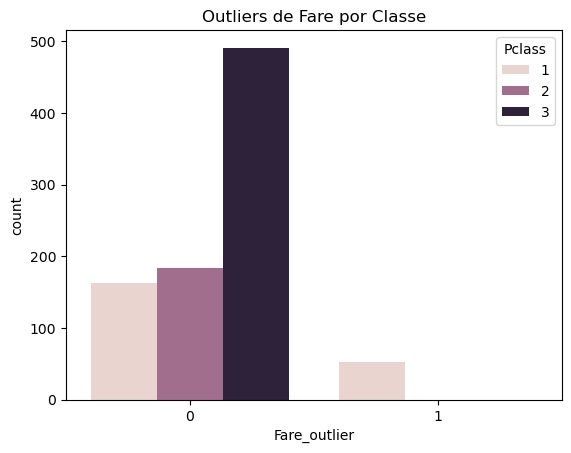

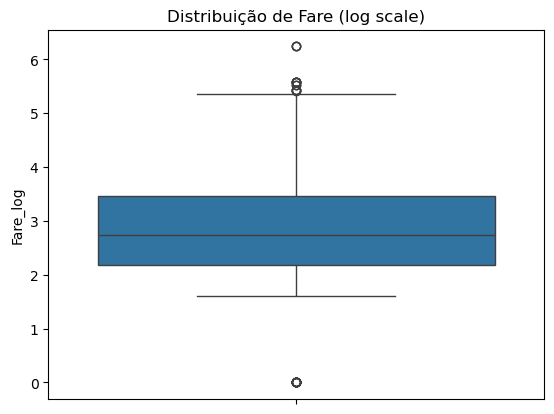

In [ ]:
#Code to detect outliers


# 1. Function to detect outliers (IQR)

def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR

    mask = (df[col] < lower) | (df[col] > upper)
    outliers = df[mask]

    return outliers, lower, upper


# 2. Apply to selected variables

vars_num = ["Age", "Fare", "FamilySize"]

for col in vars_num:
    outliers, lower, upper = detect_outliers(train_df, col)
    
    print(f"\n🔹 {col}")
    print(f"Lower bound: {lower:.2f} | Upper bound: {upper:.2f}")
    print(f"Nº de outliers: {len(outliers)}")


# 3. Analyze Fare outliers

outliers_fare, lower, upper = detect_outliers(train_df, "Fare")

print("\nTop outliers Fare:")
print(
    outliers_fare[["Fare", "Pclass", "Survived", "HasCabin"]]
    .sort_values(by="Fare", ascending=False)
    .head(10)
)


# 4. Create an outliers flag for Fare

train_df["Fare_outlier"] = 0
train_df.loc[
    (train_df["Fare"] < lower) | (train_df["Fare"] > upper),
    "Fare_outlier"
] = 1


# 5. Relationship between Fare outliers and Pclass

sns.countplot(
    data=train_df,
    x="Fare_outlier",
    hue="Pclass"
)
plt.title("Outliers de Fare por Classe")
plt.show()


# 6. Logaritmic Transformation (Log1p)

train_df["Fare_log"] = np.log1p(train_df["Fare"])  #log1p is used instead og log because some passengers paid 0. and log(0) is undefined, while log(0+1) is valid

# 7. Boxplot with log scale (better readability)

sns.boxplot(
    data=train_df,
    y="Fare_log"
)
plt.title("Distribuição de Fare (log scale)")
plt.show()

>The bar chart comparing Fare_outlier and Pclass shows that almost all extreme outliers belong to 1st class. When Fare_outlier equals 1, only passengers from Pclass 1 appear. This confirms that these outliers are not measurement errors but reflect higher‑class passengers, supporting the decision not to remove them.

>In the boxplot, the logarithmic scale provides a much clearer view of the data distribution, making it easier to interpret the variability in ticket prices.

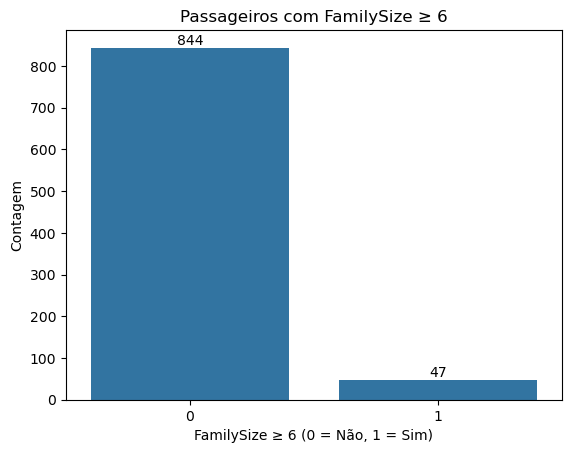

In [ ]:
# Create binary variable (FamilySize >= 6)

train_df["FamilySize_large"] = (train_df["FamilySize"] >= 6).astype(int)


# Plot
ax = sns.countplot(x="FamilySize_large", data=train_df)

plt.title("Passageiros com FamilySize ≥ 6")
plt.xlabel("FamilySize ≥ 6 (0 = Não, 1 = Sim)")
plt.ylabel("Contagem")


# Add labels with the values
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.show()

>The bar chart shows that the 47 outliers in FamilySize correspond to large families (six or more members). Since these values represent real situations rather than measurement errors, they are valid observations and should be kept in the dataset.

<p>
Outlier Treatment — In the Fare_Category column, new classes were created to accommodate extreme values: a “Very Extremely High” category for unusually high fares, and a “Free” category for passengers who paid no fare.
</p>

In [ ]:
df = train_df.copy()

# calculate upper bound for outliers using IQR
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 3 * IQR

# calculate quantiles ignoring zeros and extreme outliers
quantiles = df[(df["Fare"] > 0) & (df["Fare"] <= upper)]["Fare"].quantile([0.25, 0.5, 0.75])

def categorize_fare(x):
    if x == 0:
        return "Free"
    elif x > upper:
        return "Very Extremely High"
    elif x <= quantiles[0.25]:
        return "Low"
    elif x <= quantiles[0.5]:
        return "Medium"
    elif x <= quantiles[0.75]:
        return "High"
    else:
        return "Very High"

df["FareCategory"] = df["Fare"].apply(categorize_fare)

# view counts
df["FareCategory"].value_counts()

FareCategory
Low                    208
Very High              205
Medium                 205
High                   205
Very Extremely High     53
Free                    15
Name: count, dtype: int64

## 4. Encode categorical variables

<p>
We chose to apply encoding directly within each model’s pipeline for two main reasons: functionality, since machine learning models require numerical inputs, and data‑leakage prevention, ensuring that category mappings are learned exclusively from the training data.

At this stage, the encoding has not yet been applied. It will be implemented later in Parts C and D, within each model’s baseline pipeline, so that the encoding is fitted (.fit()) only on the training set. This prevents information from the test set from influencing the training process and preserves the integrity of model validation.

Depending on the nature of each variable, two encoding techniques were used:

Ordinal Encoding: Applied to variables with an inherent order, such as FareCategory, AgeGroup, and FamilySize. In these cases, it is important for the model to understand that categories like “High” represent a higher level than “Low”.

One‑Hot Encoding: Applied to nominal variables such as Embarked, Sex, Title, HasCabin, and IsAlone, ensuring consistency and scalability within the pipeline.

Special Case — Pclass:  
Although Pclass is already numeric (1, 2, 3), we applied One‑Hot Encoding so that the model treats each class independently rather than assuming equal spacing between them. This allows the model to better capture survival differences across passenger classes.
</p>


<p>
To assess the presence of multicollinearity among the features, two heatmaps were created: one for the categorical variables and another for the numerical variables. This approach allowed for a clear visualization of the correlations between variables, making it easier to identify strong relationships that could potentially affect model performance.
</p>

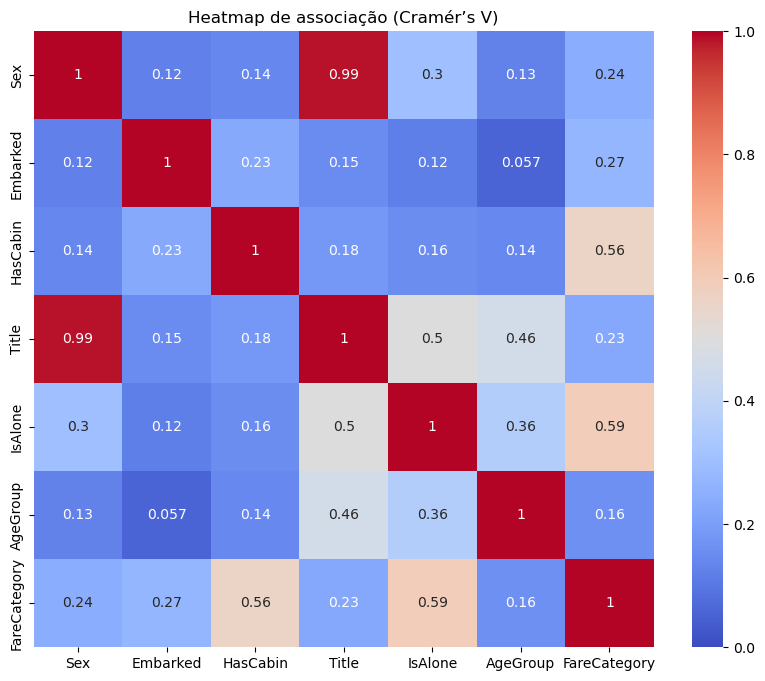

In [ ]:
#HEATMAP FOR CATEGORICAL VARIABLES

#Since categorical variables do not have a mean or a real numerical distance, Pearson correlation is not appropriate. Instead, we need a frequency-based association measure (chi-square method)

# Function to compute Cramér’s V

def cramers_v(x, y):
    tabela = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabela)[0]  #chi-square statistic; measures dependence between variables
    n = tabela.sum().sum()
    r, k = tabela.shape

    return np.sqrt(chi2 / (n * (min(k - 1, r - 1))))  #Converts χ² into Cramér’s V


# Select categorical variables
cat_cols = ['Sex', 'Embarked', 'HasCabin', 'Title', 'IsAlone', 'AgeGroup', 'FareCategory'] 


# Create association matrix
n = len(cat_cols)
matriz = pd.DataFrame(np.zeros((n, n)), index=cat_cols, columns=cat_cols)

for i in range(n):
    for j in range(n):
        if i == j:
            matriz.iloc[i, j] = 1.0
        else:
            matriz.iloc[i, j] = cramers_v(train_df[cat_cols[i]], train_df[cat_cols[j]])


# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Heatmap de associação (Cramér’s V)")
plt.show()

>The heatmap shows a strong association between FareCategory and the variables IsAlone and HasCabin, with values of 0.59 and 0.56, respectively. There is also a very high association between Sex and Title (0.99), indicating substantial redundancy between these variables.

>Note: These findings will be considered in Parts C and D of the project, particularly during feature selection, to avoid multicollinearity and improve model performance.

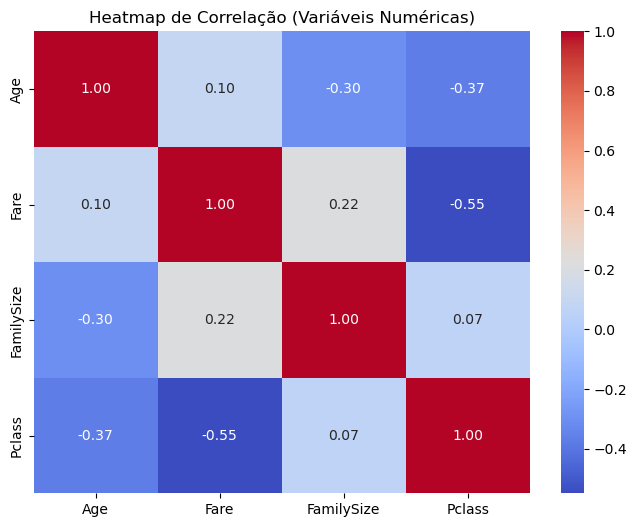

In [ ]:
#Heatmap for numeric variables


# Select numeric variables
num_cols = ['Age', 'Fare', 'FamilySize', 'Pclass' ]


# Create correlation matrix
corr_matrix = train_df[num_cols].corr()


# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap de Correlação (Variáveis Numéricas)")

plt.show()


>The heatmap shows no very strong correlations among the numerical variables. The most relevant relationship is a moderate negative correlation between Fare and Pclass (-0.55), indicating that passengers in higher classes (Pclass = 1) tend to pay higher fares.

In [ ]:
# Correlation analysis between the feature "IsAlone" and "FamilySize"

corr_family = train_df["IsAlone"].corr(train_df["FamilySize"])
print(f"Correlação IsAlone vs FamilySize: {corr_family:.4f}")

Correlação IsAlone vs FamilySize: -0.6909


>There is a strong negative correlation (-0.69), which is expected since larger families are less likely to be classified as “alone.”
>Because IsAlone is derived from FamilySize, some mathematical redundancy exists—though not as extreme as the redundancy between Title and Sex.
>We should test which of these variables provides the greatest predictive value when used independently in the model.


In [ ]:
# Correlation analysis between the feature "Embarked" and "Pclass"

# We use normalize='index' to view the percentage of classes by embarkation port
ctab_embarked_pclass = pd.crosstab(train_df["Embarked"], train_df["Pclass"], normalize="index")
print("Distribuição de Pclass por Porto de Embarque:")
print(ctab_embarked_pclass)


Distribuição de Pclass por Porto de Embarque:
Pclass           1         2         3
Embarked                              
C         0.505952  0.101190  0.392857
Q         0.025974  0.038961  0.935065
S         0.197205  0.254658  0.548137


>This analysis checks whether a specific embarkation port (e.g., Cherbourg) is overly associated with a particular passenger class (e.g., 1st class). Although some relationship exists, it is not strong enough to justify removing either variable.

In [ ]:
#Dataset with new features

train_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked,HasCabin,Title,FamilySize,IsAlone,AgeGroup,FareCategory,Fare_outlier,Fare_log,FamilySize_large
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,S,0,Mr,2,0,Adult,Low,0,2.110213,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,C,1,Mrs,2,0,Adult,Very High,0,4.280593,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,S,0,Miss,1,1,Adult,Medium,0,2.188856,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,S,1,Mrs,2,0,Adult,Very High,0,3.990834,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,S,0,Mr,1,1,Adult,Medium,0,2.202765,0
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,...,Q,0,Mr,1,1,NaN,Medium,0,2.246893,0
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,...,S,1,Mr,1,1,Adult,Very High,0,3.967694,0
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,...,S,0,Master,5,0,Child,High,0,3.094446,0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,...,S,0,Mrs,3,0,Adult,Medium,0,2.495954,0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,...,C,0,Mrs,2,0,Teen,High,0,3.436268,0


# PART C - Classification Task Survival Prediction

## 1.Data Preparation

<p>
The dataset must first be split into training and validation/test sets to prevent data leakage.
Normalization (e.g., using StandardScaler) should be performed only after this split, using statistics computed exclusively from the training set. Methods that rely on the mean or standard deviation must not use information from the full dataset, as this would bias the results.
The same principle applies to missing‑value imputation: the imputer should be fitted on the training data (fit_transform) and then applied to the validation/test set (transform) without recalculating statistics.
Likewise, categorical encoding must be fitted only on the training data and then applied consistently to the remaining sets to ensure the model’s integrity and consistency.


In [ ]:
#Code to split the dataset into training and test sets

mlflow.autolog(disable=True)


# Load the data
data = train_df


# Separate the target variable from the predictors 

y = data["Survived"]
X = data.drop(["Survived"], axis=1)


# Split the data into training and valdiation subsets

X_train_full, X_valid_full, y_train, y_valid = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=0,
    stratify=y   # The titanic dataset is imbalanced (around 60% did not survive, around 40% survived).
)                #Without stratify, the train/test split could have different class distributions, leading to biased validation results                                           

In [ ]:
# Removal of nulls in the embarked column and imputation of nulls in Age/AgeGroup

# 1. Removing nulls in embarked


# training set
X_train_full = X_train_full.dropna(subset=["Embarked"])
y_train = y_train.loc[X_train_full.index]


# validation set
X_valid_full = X_valid_full.dropna(subset=["Embarked"])
y_valid = y_valid.loc[X_valid_full.index]


# 2. Age Imputation (learned from training data)


# learn values from the training set
title_age_map = X_train_full.groupby("Title")["Age"].median()
global_age_median = X_train_full["Age"].median()


# Training set

# impute age
X_train_full["Age"] = X_train_full["Age"].fillna(
    X_train_full["Title"].map(title_age_map)
)

X_train_full["Age"] = X_train_full["Age"].fillna(global_age_median)


# create AgeGroup
X_train_full["AgeGroup"] = pd.cut(
    X_train_full["Age"],
    bins=[0, 12, 18, 60, float("inf")],
    labels=["Child", "Teen", "Adult", "Senior"],
    right=False
)


# Validation set

# impute Age using training information
X_valid_full["Age"] = X_valid_full["Age"].fillna(
    X_valid_full["Title"].map(title_age_map)
)

X_valid_full["Age"] = X_valid_full["Age"].fillna(global_age_median)


# create AgeGroup
X_valid_full["AgeGroup"] = pd.cut(
    X_valid_full["Age"],
    bins=[0, 12, 18, 60, float("inf")],
    labels=["Child", "Teen", "Adult", "Senior"],
    right=False
)


# 3. Verification

print("=== NaNs ===")
print("Train Age:", X_train_full["Age"].isna().sum())
print("Train AgeGroup:", X_train_full["AgeGroup"].isna().sum())
print("Valid Age:", X_valid_full["Age"].isna().sum())
print("Valid AgeGroup:", X_valid_full["AgeGroup"].isna().sum())

print("\n=== Distribuição AgeGroup (Train) ===")
print(X_train_full["AgeGroup"].value_counts(dropna=False))

print("\n=== Distribuição AgeGroup (Valid) ===")
print(X_valid_full["AgeGroup"].value_counts(dropna=False))

=== NaNs ===
Train Age: 0
Train AgeGroup: 0
Valid Age: 0
Valid AgeGroup: 0

=== Distribuição AgeGroup (Train) ===
AgeGroup
Adult     594
Child      58
Teen       39
Senior     19
Name: count, dtype: int64

=== Distribuição AgeGroup (Valid) ===
AgeGroup
Adult     153
Child      14
Teen        6
Senior      6
Name: count, dtype: int64


<p>
<b>Note:</b> The strategy for handling missing values is described in Annex - Part B"

In [31]:
X_train_full.isnull().sum()

PassengerId           0
Pclass                0
Name                  0
Sex                   0
Age                   0
SibSp                 0
Parch                 0
Ticket                0
Fare                  0
Cabin               552
Embarked              0
HasCabin              0
Title                 0
FamilySize            0
IsAlone               0
AgeGroup              0
FareCategory          0
Fare_outlier          0
Fare_log              0
FamilySize_large      0
dtype: int64

>Next, using the Random Forest Classifier, we evaluated the importance of each feature with the goal of selecting the most relevant variables to be used across the four models.

In [ ]:
#Feature Importance Code


# 1. Training data already split

features = [
    "Pclass", "Sex", "Title", "Fare", "FareCategory",
    "FamilySize", "IsAlone", "HasCabin", "Embarked",
    "Age", "AgeGroup"
]

X = X_train_full[features].copy()
y = y_train.loc[X.index].copy()


# 2. Define column groups

numeric_cols = ["Fare", "FamilySize", "Age"]
ordinal_cols = ["FareCategory", "AgeGroup"]
onehot_cols = ["Title", "Sex", "Pclass", "HasCabin", "Embarked", "IsAlone"]


# 3. Preprocessing pipelines

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=[
            ["Free", "Low", "Medium", "High", "Very High", "Very Extremely High"],  # FareCategory
            ["Child", "Teen", "Adult", "Senior"]                                     # AgeGroup
        ],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("ord", ordinal_pipeline, ordinal_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 4. Final pipeline for feature importance

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])


# 5. Train on the training set

model_pipeline.fit(X, y)


# 6. Detailed importances (after transformation)

feature_names = model_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = model_pipeline.named_steps["model"].feature_importances_

importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("=== Detailed Importances (Transformed Features) ===")
print(importance_series)


# 7. Aggregate importances by original feature

aggregated_importances = {}

for feature, importance in importance_series.items():
    if feature.startswith("num__"):
        original_name = feature.replace("num__", "")

    elif feature.startswith("ord__"):
        original_name = feature.replace("ord__", "")

    elif feature.startswith("oh__"):
        transformed_name = feature.replace("oh__", "")

        if transformed_name.startswith("Title_"):
            original_name = "Title"
        elif transformed_name.startswith("Sex_"):
            original_name = "Sex"
        elif transformed_name.startswith("Pclass_"):
            original_name = "Pclass"
        elif transformed_name.startswith("HasCabin_"):
            original_name = "HasCabin"
        elif transformed_name.startswith("Embarked_"):
            original_name = "Embarked"
        elif transformed_name.startswith("IsAlone_"):
            original_name = "IsAlone"
        else:
            original_name = transformed_name

    else:
        original_name = feature

    aggregated_importances[original_name] = aggregated_importances.get(original_name, 0) + importance

aggregated_importance_series = pd.Series(aggregated_importances).sort_values(ascending=False)

print("\n=== Aggregated Feature Importances ===")
print(aggregated_importance_series)

=== Detailed Importances (Transformed Features) ===
num__Age             0.206472
num__Fare            0.201920
oh__Sex_male         0.137978
oh__Title_Mr         0.111494
num__FamilySize      0.065328
oh__Pclass_3         0.053755
ord__FareCategory    0.040055
oh__HasCabin_1       0.034760
oh__Title_Mrs        0.032448
oh__Title_Miss       0.026568
ord__AgeGroup        0.023483
oh__Embarked_S       0.020004
oh__Pclass_2         0.014214
oh__IsAlone_1        0.012985
oh__Embarked_Q       0.010475
oh__Title_Other      0.008060
dtype: float64

=== Aggregated Feature Importances ===
Age             0.206472
Fare            0.201920
Title           0.178570
Sex             0.137978
Pclass          0.067969
FamilySize      0.065328
FareCategory    0.040055
HasCabin        0.034760
Embarked        0.030479
AgeGroup        0.023483
IsAlone         0.012985
dtype: float64


>The most important features were Age, Fare, Title, Sex, Pclass, and FamilySize. Later, when training all models with the same feature set for comparison, the variable Sex was removed due to its high multicollinearity with Title, which could introduce redundancy and negatively affect models such as SVM and Logistic Regression. All remaining features were kept.

## 2. Baseline Model

=== Logistic Regression - Validation Metrics ===
Accuracy : 0.7933
Precision: 0.7759
Recall   : 0.6522
F1-score : 0.7087
ROC-AUC  : 0.8512

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       110
           1       0.78      0.65      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179


=== Confusion Matrix ===
[[97 13]
 [24 45]]


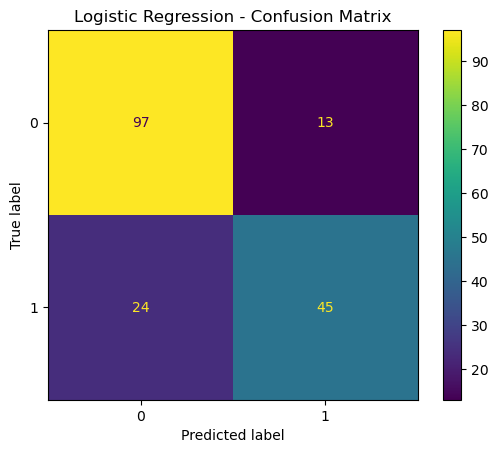

In [ ]:
#Baseline for LR model - The pipeline includes creation of Fare_log, normalization of numerical features and encoding


# 1. Create Fare_log 
# The logarithmic transformation of Fare helps make the distribution more normal and linearizes relationships, which benefits Logistic Regression

X_train_full = X_train_full.copy()
X_valid_full = X_valid_full.copy()

X_train_full["Fare_log"] = np.log1p(X_train_full["Fare"])
X_valid_full["Fare_log"] = np.log1p(X_valid_full["Fare"])


# 2. Define features

selected_features = ["Title", "Pclass", "Age", "Fare_log", "FamilySize"]

X_train_sel = X_train_full[selected_features].copy()
X_val_sel = X_valid_full[selected_features].copy()

y_train_aligned = y_train.loc[X_train_sel.index]
y_val_aligned = y_valid.loc[X_val_sel.index]


# 3. Define column types

numeric_cols = ["FamilySize", "Fare_log", "Age"]
onehot_cols = ["Title", "Pclass"]


# 4. Pipelines by variable type

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 5. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 6. Final pipeline with Logistic Regression

model_lr = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=0
    ))
])


# 7. Train model

model_lr.fit(X_train_sel, y_train_aligned)


# 8. Predictions

y_pred_lr = model_lr.predict(X_val_sel)
y_prob_lr = model_lr.predict_proba(X_val_sel)[:, 1]


# 9. Metrics

accuracy_lr = accuracy_score(y_val_aligned, y_pred_lr)
precision_lr = precision_score(y_val_aligned, y_pred_lr)
recall_lr = recall_score(y_val_aligned, y_pred_lr)
f1_lr = f1_score(y_val_aligned, y_pred_lr)
roc_auc_lr = roc_auc_score(y_val_aligned, y_prob_lr)

print("=== Logistic Regression - Validation Metrics ===")
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1-score : {f1_lr:.4f}")
print(f"ROC-AUC  : {roc_auc_lr:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_val_aligned, y_pred_lr))


# 10. Confusion Matrix


cm_lr = confusion_matrix(y_val_aligned, y_pred_lr)
print("\n=== Confusion Matrix ===")
print(cm_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

=== SVM - Validation Metrics ===
Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1-score : 0.7244
ROC-AUC  : 0.8375

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


=== Confusion Matrix ===
[[98 12]
 [23 46]]


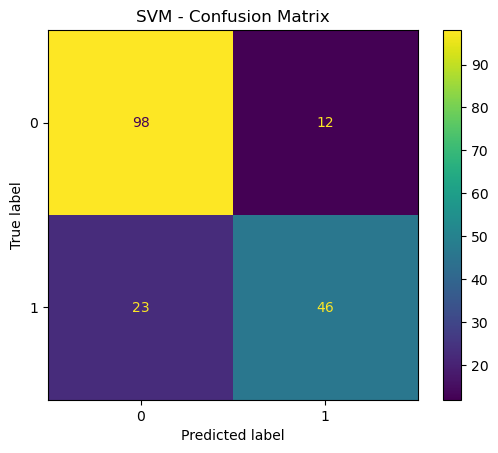

In [ ]:
#Baseline for SVM model - same steps as LR model


# 1. Create Fare_log
# The logarithmic transformation of Fare helps make the distribution more normal and linearizes relationships, which benefits SVM

X_train_full = X_train_full.copy()
X_valid_full = X_valid_full.copy()

X_train_full["Fare_log"] = np.log1p(X_train_full["Fare"])
X_valid_full["Fare_log"] = np.log1p(X_valid_full["Fare"])


# 2. Define features

selected_features = ["Title", "Pclass", "Age", "Fare_log", "FamilySize"]

X_train_sel = X_train_full[selected_features].copy()
X_val_sel = X_valid_full[selected_features].copy()

y_train_aligned = y_train.loc[X_train_sel.index]
y_val_aligned = y_valid.loc[X_val_sel.index]


# 3. Define column types

numeric_cols = ["FamilySize", "Fare_log", "Age"]

onehot_cols = ["Title", "Pclass"]


# 4. Pipelines by variable type

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 5. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 6. Final pipeline with SVM

model_svm = Pipeline([
    ("prep", preprocessor),
    ("model", SVC(
        kernel="rbf",
        C=1,
        gamma="scale",
        probability=True,
        random_state=0
    ))
])


# 7. Train model

model_svm.fit(X_train_sel, y_train_aligned)


# 8. Predictions

y_pred_svm = model_svm.predict(X_val_sel)
y_prob_svm = model_svm.predict_proba(X_val_sel)[:, 1]


# 9. Metrics

accuracy_svm = accuracy_score(y_val_aligned, y_pred_svm)
precision_svm = precision_score(y_val_aligned, y_pred_svm)
recall_svm = recall_score(y_val_aligned, y_pred_svm)
f1_svm = f1_score(y_val_aligned, y_pred_svm)
roc_auc_svm = roc_auc_score(y_val_aligned, y_prob_svm)

print("=== SVM - Validation Metrics ===")
print(f"Accuracy : {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall   : {recall_svm:.4f}")
print(f"F1-score : {f1_svm:.4f}")
print(f"ROC-AUC  : {roc_auc_svm:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_val_aligned, y_pred_svm))


# 10. Confusion Matrix

cm_svm = confusion_matrix(y_val_aligned, y_pred_svm)
print("\n=== Confusion Matrix ===")
print(cm_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp.plot()
plt.title("SVM - Confusion Matrix")
plt.show()

=== Decision Tree - Validation Metrics ===
Accuracy : 0.7877
Precision: 0.7183
Recall   : 0.7391
F1-score : 0.7286
ROC-AUC  : 0.7746

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.83      0.82      0.83       110
           1       0.72      0.74      0.73        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179


=== Confusion Matrix ===
[[90 20]
 [18 51]]


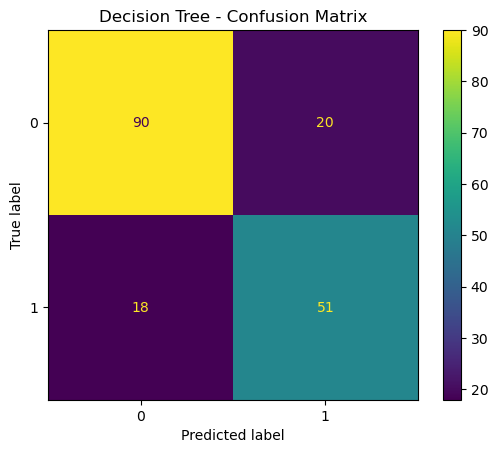

In [ ]:
#Baseline for Decision Tree model - it does not include normalization of numerical variables nor the creation of Fare_log

# 1. Define features

selected_features = ["Title", "Pclass", "Age", "Fare", "FamilySize"]

X_train_sel = X_train_full[selected_features].copy()
X_val_sel = X_valid_full[selected_features].copy()

y_train_aligned = y_train.loc[X_train_sel.index]
y_val_aligned = y_valid.loc[X_val_sel.index]

# 2. Define column types

numeric_cols = ["FamilySize", "Fare", "Age"]

onehot_cols = ["Title", "Pclass"]


# 3. Pipelines by variable type

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 4. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 5. Final pipeline with Decision Tree

model_dt = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=0
    ))
])


# 6. Train model

model_dt.fit(X_train_sel, y_train_aligned)


# 7. Predictions

y_pred_dt = model_dt.predict(X_val_sel)
y_prob_dt = model_dt.predict_proba(X_val_sel)[:, 1]


# 8. Metrics

accuracy_dt = accuracy_score(y_val_aligned, y_pred_dt)
precision_dt = precision_score(y_val_aligned, y_pred_dt)
recall_dt = recall_score(y_val_aligned, y_pred_dt)
f1_dt = f1_score(y_val_aligned, y_pred_dt)
roc_auc_dt = roc_auc_score(y_val_aligned, y_prob_dt)

print("=== Decision Tree - Validation Metrics ===")
print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1-score : {f1_dt:.4f}")
print(f"ROC-AUC  : {roc_auc_dt:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_val_aligned, y_pred_dt))


# 9. Confusion Matrix

cm_dt = confusion_matrix(y_val_aligned, y_pred_dt)
print("\n=== Confusion Matrix ===")
print(cm_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

=== Random Forest - Validation Metrics ===
Accuracy : 0.8156
Precision: 0.8000
Recall   : 0.6957
F1-score : 0.7442
ROC-AUC  : 0.8372

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179


=== Confusion Matrix ===
[[98 12]
 [21 48]]


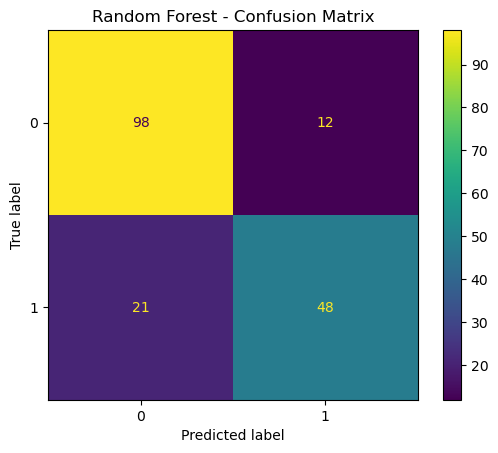

In [ ]:
#Baseline of Random Forest model - similar to Decision Tree


# 1. Define features

selected_features = ["Title", "Pclass", "Age", "Fare", "FamilySize"]

X_train_sel = X_train_full[selected_features].copy()
X_val_sel = X_valid_full[selected_features].copy()

y_train_aligned = y_train.loc[X_train_sel.index]
y_val_aligned = y_valid.loc[X_val_sel.index]


# 2. Define column types

numeric_cols = ["FamilySize", "Fare", "Age"]
onehot_cols = ["Title", "Pclass"]


# 3. Pipelines by variable type

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 4. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 5. Final Pipeline with Random Forest

model_rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        random_state=0
    ))
])


# 6. Train model

model_rf.fit(X_train_sel, y_train_aligned)


# 7. Predictions

y_pred_rf = model_rf.predict(X_val_sel)
y_prob_rf = model_rf.predict_proba(X_val_sel)[:, 1]


# 8. Metrics

accuracy_rf = accuracy_score(y_val_aligned, y_pred_rf)
precision_rf = precision_score(y_val_aligned, y_pred_rf)
recall_rf = recall_score(y_val_aligned, y_pred_rf)
f1_rf = f1_score(y_val_aligned, y_pred_rf)
roc_auc_rf = roc_auc_score(y_val_aligned, y_prob_rf)

print("=== Random Forest - Validation Metrics ===")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_val_aligned, y_pred_rf))


# 9. Confusion Matrix

cm_rf = confusion_matrix(y_val_aligned, y_pred_rf)
print("\n=== Confusion Matrix ===")
print(cm_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

>For the Decision Tree and Random Forest models, neither normalization nor the logarithmic transformation of the Fare variable was required, since these algorithms are not sensitive to feature scale or distance. They rely on hierarchical splits of the features, making such transformations unnecessary.

## 3. Model Iteration

                 Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
0  Logistic Regression    0.7933     0.7759  0.6522    0.7087   0.8512
1                  SVM    0.8045     0.7931  0.6667    0.7244   0.8375
2        Decision Tree    0.7877     0.7183  0.7391    0.7286   0.7746
3        Random Forest    0.8156     0.8000  0.6957    0.7442   0.8372


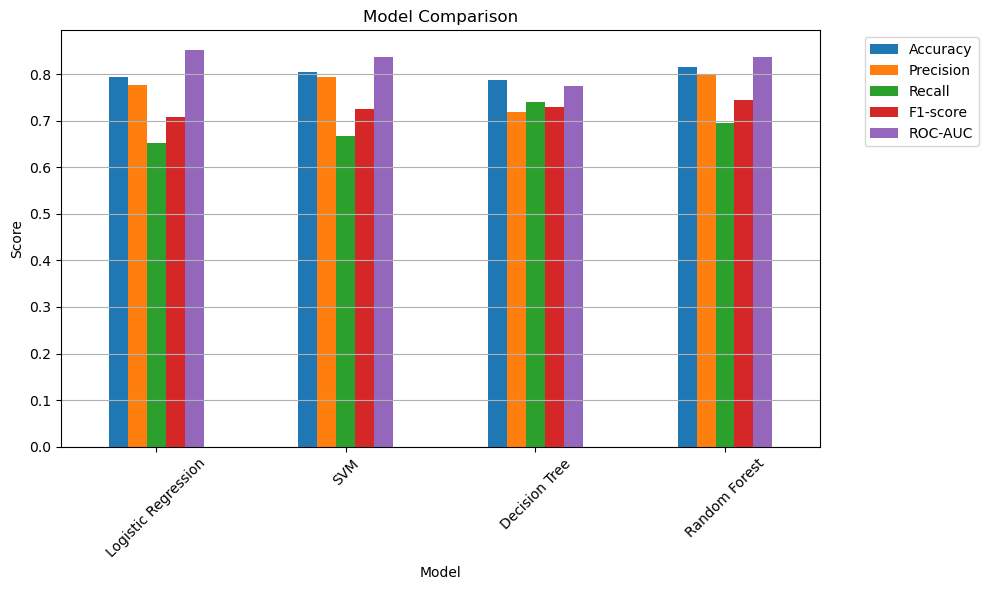

In [ ]:
#Comparison of 4 models

results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Decision Tree", "Random Forest"],
    "Accuracy": [0.7933, 0.8045,0.7877, 0.8156],
    "Precision": [0.7759,0.7931, 0.7183, 0.800],
    "Recall": [0.6522, 0.6667,0.7391, 0.6957],
    "F1-score": [0.7087, 0.7244,0.7286, 0.7442],
    "ROC-AUC": [0.8512, 0.8375,0.7746, 0.8372]
})


# View results
print(results)


# Plot
ax = results.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(axis="y")


# Legend placed outside the plot on the right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


# Adjust layout to avoid clipping
plt.tight_layout()

plt.show()

>After comparing the different models, SVM and Random Forest were selected for the next stage due to their stronger overall performance.
SVM was preferred over the Decision Tree because it achieved better results in most metrics—Accuracy, Precision, F1‑score, and ROC‑AUC. Although the Decision Tree had a slightly higher Recall, SVM delivered a more balanced and consistent performance, making it the more robust choice.
Random Forest was also selected as it achieved the best overall results, particularly in Accuracy and ROC‑AUC. As an ensemble of multiple trees, it reduces the overfitting risk associated with a single Decision Tree, providing more stable and reliable predictions.

## 4. Model Optimization

<p>
Before performing feature selection for the SVM model, an initial step of feature presentation selection was carried out. In this phase, different combinations of potentially redundant variables were tested, based on the analysis from Part B of the project—specifically the pairs Age/AgeGroup, Fare/FareCategory, Sex/Title, and IsAlone/FamilySize (or the combination IsAlone + FamilySize).
This approach was used because these variables contain overlapping information, making it important to keep only one from each group to avoid redundancy. Otherwise, the model could be affected by duplicated information, harming performance and generalization.

In [ ]:
#Code for eliminating redundant features - SVM (pre-feature selection)


# 1. Create Fare_log 

X_train_full = X_train_full.copy()
X_valid_full = X_valid_full.copy()

X_train_full["Fare_log"] = np.log1p(X_train_full["Fare"])
X_valid_full["Fare_log"] = np.log1p(X_valid_full["Fare"])


# 2. feature options - these are the alternatives the model should consider

base_fixed_cols = ["Embarked", "Pclass", "HasCabin"]   #these 3 variables are fixed

age_options = ["Age", "AgeGroup"]
fare_options = ["Fare_log", "FareCategory"]
sex_title_options = ["Sex", "Title"]

family_options = [
    ["IsAlone"],
    ["FamilySize"],
    ["IsAlone", "FamilySize"]
]


# 2. Variable types

numeric_features = ["Age", "Fare_log", "FamilySize"]
ordinal_features = ["FareCategory", "AgeGroup"]
onehot_features = ["Embarked", "Title", "Pclass", "Sex", "HasCabin", "IsAlone"]


# 3. Preprocessor

def build_preprocessor(selected_cols):
    num_cols = [c for c in selected_cols if c in numeric_features]
    ord_cols = [c for c in selected_cols if c in ordinal_features]
    oh_cols = [c for c in selected_cols if c in onehot_features]

    transformers = []

    if num_cols:
        transformers.append(("num", StandardScaler(), num_cols))

    if ord_cols:
        ordinal_encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
        transformers.append(("ord", ordinal_encoder, ord_cols))

    if oh_cols:
        transformers.append(("oh", OneHotEncoder(handle_unknown="ignore", drop="first"), oh_cols))

    return ColumnTransformer(transformers)


# 4. Loop with SVM

results = []

for age_col, fare_col, sex_col, family_cols in product(
    age_options, fare_options, sex_title_options, family_options
):
    selected_cols = [age_col, fare_col, sex_col] + family_cols + base_fixed_cols  #This generates all possible combinations of the specified options, testing different versions of potentially redundant or interchangeable variables.
                                                                            #Each combination also includes the fixed variables.
    if not all(col in X_train_full.columns for col in selected_cols):
        continue

    preprocessor = build_preprocessor(selected_cols)

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", SVC(probability=True, kernel="rbf", C=1.0, gamma="scale"))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  ## For each combination, a pipeline is built with the appropriate preprocessing
    # and evaluated using stratified 5‑fold cross‑validation with ROC‑AUC as the metric.

    score = cross_val_score(
        pipe,
        X_train_full[selected_cols],
        y_train,
        cv=cv,  
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    results.append({
        "Age": age_col,
        "Fare": fare_col,
        "Sex/Title": sex_col,
        "Family": " + ".join(family_cols),
        "Score": score
    })


# 5. Results


results_df = pd.DataFrame(results).sort_values(by="Score", ascending=False)
print(results_df.head(10))

         Age          Fare Sex/Title                Family     Score
0        Age      Fare_log       Sex               IsAlone  0.876760
8        Age  FareCategory       Sex  IsAlone + FamilySize  0.870103
7        Age  FareCategory       Sex            FamilySize  0.870102
2        Age      Fare_log       Sex  IsAlone + FamilySize  0.869563
3        Age      Fare_log     Title               IsAlone  0.869100
1        Age      Fare_log       Sex            FamilySize  0.869097
19  AgeGroup  FareCategory       Sex            FamilySize  0.865998
12  AgeGroup      Fare_log       Sex               IsAlone  0.865036
10       Age  FareCategory     Title            FamilySize  0.865018
6        Age  FareCategory       Sex               IsAlone  0.864707


>Ouput of the code above
>The best combination, based on the highest average ROC-AUC value, was Age, Fare_log, Sex and IsAlone.

<p>
After removing redundant variables, a feature selection process was performed using greedy forward selection to identify the most relevant features for training the SVM model. In this method, features are added iteratively based on the largest performance gain — measured here using ROC‑AUC through stratified cross‑validation. The process stops once adding new features no longer provides a meaningful improvement in model performance.
</p>

In [ ]:
#Code for Feature Selection (At this stage we remove redundant variables according to the output of the previous code)


# 1. Create Fare_log

X_train_full = X_train_full.copy()
X_valid_full = X_valid_full.copy()

X_train_full["Fare_log"] = np.log1p(X_train_full["Fare"])
X_valid_full["Fare_log"] = np.log1p(X_valid_full["Fare"])


# 2. Define features

candidate_features = ["Sex", "Pclass", "Age", "Fare_log", "IsAlone", "HasCabin", "Embarked"]

X_train_sel = X_train_full[candidate_features].copy()
X_val_sel = X_valid_full[candidate_features].copy()

y_train_aligned = y_train.loc[X_train_sel.index]
y_val_aligned = y_valid.loc[X_val_sel.index]


def build_preprocessor(selected_features):
    num_cols = [c for c in selected_features if c in ["Fare_log", "Age"]]
    onehot_cols = [c for c in selected_features if c in ["Embarked", "Pclass", "HasCabin", "IsAlone", "Sex"]]

    transformers = []

    if num_cols:
        transformers.append(("num", StandardScaler(), num_cols))

    if onehot_cols:
        transformers.append(
            ("oh", OneHotEncoder(handle_unknown="ignore", drop="first"), onehot_cols)
        )

    return ColumnTransformer(transformers)


# Cross validation with random_state

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)    #Stratified Cross-validation

selected_features = []                       #Greedy forward selection – the model starts empty and adds variables iteratively
remaining_features = candidate_features.copy()
results_forward = []
best_score_so_far = -1

while remaining_features:
    scores_this_round = []

    for feature in remaining_features:
        current_features = selected_features + [feature]

        preprocessor = build_preprocessor(current_features)

        pipe = Pipeline([
            ("prep", preprocessor),
            ("model", SVC(
                kernel="rbf",
                C=1,
                gamma="scale",
                random_state=0
            ))
        ])

        score = cross_val_score(
            pipe,
            X_train_sel[current_features],
            y_train.loc[X_train_sel.index],
            cv=cv,
            scoring="roc_auc",
            n_jobs=-1
        ).mean()

        scores_this_round.append((feature, score, current_features))

    best_feature, best_score, best_set = max(scores_this_round, key=lambda x: x[1])

    results_forward.append({
        "Step": len(selected_features) + 1,
        "Added_Feature": best_feature,
        "Selected_Features": best_set.copy(),
        "CV_ROC_AUC": best_score
    })

    if best_score > best_score_so_far:
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        best_score_so_far = best_score
    else:
        break

results_forward_df = pd.DataFrame(results_forward)

print(results_forward_df)
print("\nFeatures finais selecionadas:", selected_features)
print("Melhor ROC-AUC:", best_score_so_far)



   Step Added_Feature                                  Selected_Features  \
0     1           Sex                                              [Sex]   
1     2       IsAlone                                     [Sex, IsAlone]   
2     3           Age                                [Sex, IsAlone, Age]   
3     4      HasCabin                      [Sex, IsAlone, Age, HasCabin]   
4     5      Embarked            [Sex, IsAlone, Age, HasCabin, Embarked]   
5     6        Pclass    [Sex, IsAlone, Age, HasCabin, Embarked, Pclass]   
6     7      Fare_log  [Sex, IsAlone, Age, HasCabin, Embarked, Pclass...   

   CV_ROC_AUC  
0    0.768308  
1    0.797446  
2    0.800695  
3    0.832346  
4    0.849010  
5    0.858702  
6    0.870289  

Features finais selecionadas: ['Sex', 'IsAlone', 'Age', 'HasCabin', 'Embarked', 'Pclass', 'Fare_log']
Melhor ROC-AUC: 0.8702893881342157


=== Cross-Validation ===
ROC-AUC scores: [0.82596801 0.88068182 0.86574074 0.87226431 0.90679206]
Mean ROC-AUC  : 0.8703
Std ROC-AUC   : 0.0262

=== Métricas no Validation Set ===
Accuracy : 0.7933
Precision: 0.8200
Recall   : 0.5942
F1-score : 0.6891
ROC-AUC  : 0.8264

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.78      0.92      0.85       110
           1       0.82      0.59      0.69        69

    accuracy                           0.79       179
   macro avg       0.80      0.76      0.77       179
weighted avg       0.80      0.79      0.79       179


=== Confusion Matrix ===
[[101   9]
 [ 28  41]]


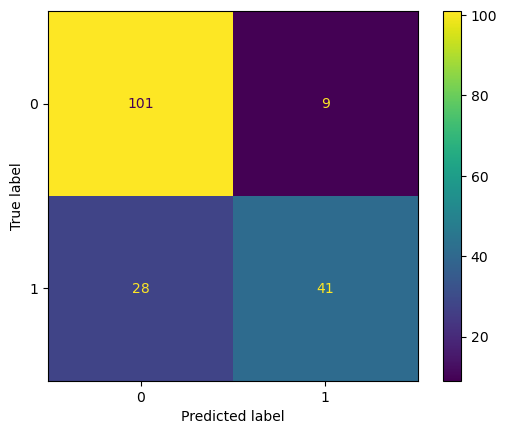

In [ ]:
# Training the SVM model with the selected features and performance evaluation


# 1. Create Fare_log 

X_train_full = X_train_full.copy()
X_valid_full = X_valid_full.copy()

X_train_full["Fare_log"] = np.log1p(X_train_full["Fare"])
X_valid_full["Fare_log"] = np.log1p(X_valid_full["Fare"])

# 2. Preprocessing function

def build_preprocessor(selected_features):
    if any(isinstance(x, list) for x in selected_features):
        raise ValueError(f"selected_features contém listas dentro: {selected_features}")

    num_cols = [c for c in selected_features if c in ["Fare_log", "Age"]]
    onehot_cols = [c for c in selected_features if c in ["Sex", "Pclass", "HasCabin", "IsAlone", "Embarked"]]


    # extra validation
    for name, cols in [
        ("num_cols", num_cols),
        ("onehot_cols", onehot_cols)
    ]:
        if any(isinstance(x, list) for x in cols):
            raise ValueError(f"{name} contém listas dentro: {cols}")

    transformers = []

    if num_cols:
        transformers.append(
            ("num", StandardScaler(), num_cols)
        )
          
    if onehot_cols:
        transformers.append(
            ("oh", OneHotEncoder(handle_unknown="ignore", drop="first"), onehot_cols)
        )

    if not transformers:
        raise ValueError(f"Nenhuma feature válida foi selecionada: {selected_features}")

    return ColumnTransformer(transformers)


# 3. Final features

selected_features = ["Sex", "Pclass", "Age", "IsAlone", "HasCabin", "Fare_log", "Embarked"]

X_train_sel = X_train_full[selected_features].copy()
X_valid_sel = X_valid_full[selected_features].copy()

y_train_aligned = y_train.loc[X_train_sel.index]
y_valid_aligned = y_valid.loc[X_valid_sel.index]


# 4. Final pipeline

preprocessor = build_preprocessor(selected_features)

final_model = Pipeline([
    ("prep", preprocessor),
    ("model", SVC(
        kernel="rbf",
        C=1,             #valores dos hiperparâmtros por default
        gamma="scale",
        probability=True,   #ativa o cálculo de probabildiades associadas às previsões (probabilidade de sobrevivência). Isto é essencial para a métrica ROC-AUC e para definição de thrsholds de decisão.
        random_state=0      # Com as probabilidades ativadas temos noção de confiança do modelo (o quão confiante é modelo na sua decisão final)
    ))
])


# 5. Cross-validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

cv_roc_auc = cross_val_score(
    final_model,
    X_train_sel,
    y_train_aligned,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("=== Cross-Validation ===")
print(f"ROC-AUC scores: {cv_roc_auc}")
print(f"Mean ROC-AUC  : {cv_roc_auc.mean():.4f}")
print(f"Std ROC-AUC   : {cv_roc_auc.std():.4f}")


# 6. Train on the full training set

final_model.fit(X_train_sel, y_train_aligned)


# 7. Predict on the validation set

y_pred = final_model.predict(X_valid_sel)
y_prob = final_model.predict_proba(X_valid_sel)[:, 1]


# 8. Metrics

accuracy = accuracy_score(y_valid_aligned, y_pred)
precision = precision_score(y_valid_aligned, y_pred)
recall = recall_score(y_valid_aligned, y_pred)
f1 = f1_score(y_valid_aligned, y_pred)
roc_auc = roc_auc_score(y_valid_aligned, y_prob)

print("\n=== Métricas no Validation Set ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_valid_aligned, y_pred))


# 9. Confusion Matrix

cm_svm = confusion_matrix(y_valid_aligned, y_pred)
print("\n=== Confusion Matrix ===")
print(cm_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp.plot()
plt.show()

>At this stage, the SVM model was compared using two different feature sets while keeping the same hyperparameters. Performance decreased when HasCabin and Embarked were included, as well as when replacing FamilySize with IsAlone and Title with Sex.
>The first approach, based on Random Forest feature importance, achieved better results than the second approach using greedy forward selection. This indicates that selecting features based on their overall importance was more effective in this context.

<p>
Next, hyperparameter tuning was performed and the model’s performance was evaluated, as shown in the code below. The features used in this stage correspond to those obtained from the feature selection process (greedy forward selection).
</p>

Fitting 5 folds for each of 16 candidates, totalling 80 fits
=== SVM - Best Params ===
{'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best CV ROC-AUC: 0.8703

=== SVM - Validation Metrics ===
Accuracy : 0.7933
Precision: 0.8200
Recall   : 0.5942
F1-score : 0.6891
ROC-AUC  : 0.8264

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.78      0.92      0.85       110
           1       0.82      0.59      0.69        69

    accuracy                           0.79       179
   macro avg       0.80      0.76      0.77       179
weighted avg       0.80      0.79      0.79       179


=== Confusion Matrix ===
[[101   9]
 [ 28  41]]


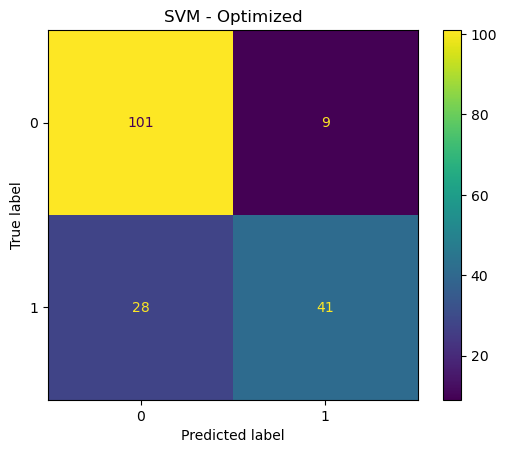

                                               params  mean_test_score  \
5   {'model__C': 1, 'model__gamma': 'scale', 'mode...         0.870289   
1   {'model__C': 0.1, 'model__gamma': 'scale', 'mo...         0.861602   
9   {'model__C': 10, 'model__gamma': 'scale', 'mod...         0.859513   
7   {'model__C': 1, 'model__gamma': 'auto', 'model...         0.859283   
11  {'model__C': 10, 'model__gamma': 'auto', 'mode...         0.858104   
15  {'model__C': 100, 'model__gamma': 'auto', 'mod...         0.850344   
3   {'model__C': 0.1, 'model__gamma': 'auto', 'mod...         0.849430   
12  {'model__C': 100, 'model__gamma': 'scale', 'mo...         0.839511   
14  {'model__C': 100, 'model__gamma': 'auto', 'mod...         0.839511   
13  {'model__C': 100, 'model__gamma': 'scale', 'mo...         0.835761   

    rank_test_score  
5                 1  
1                 2  
9                 3  
7                 4  
11                5  
15                6  
3                 7  
12       

In [ ]:
#Hyperparameter tuning and results - SVM model


# 1. Create Fare_log

X_train_full = X_train_full.copy()
X_valid_full = X_valid_full.copy()

X_train_full["Fare_log"] = np.log1p(X_train_full["Fare"])
X_valid_full["Fare_log"] = np.log1p(X_valid_full["Fare"])


# 2. Preprocessing - SVM

def build_preprocessor_svm(selected_features):
    num_cols = [c for c in selected_features if c in ["Age", "Fare_log"]]
    onehot_cols = [c for c in selected_features if c in ["Sex", "IsAlone", "Pclass", "HasCabin", "Embarked"]]

    transformers = []

    if num_cols:
        transformers.append(("num", StandardScaler(), num_cols))

    if onehot_cols:
        transformers.append((
            "oh",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            onehot_cols
        ))

    return ColumnTransformer(transformers)


# 3. Final SVM features

selected_features_svm = ["Age", "Fare_log", "Sex", "IsAlone", "HasCabin", "Embarked", "Pclass"]

X_train_svm_sel = X_train_full[selected_features_svm].copy()
X_valid_svm_sel = X_valid_full[selected_features_svm].copy()

y_train_svm = y_train.loc[X_train_svm_sel.index]
y_valid_svm = y_valid.loc[X_valid_svm_sel.index]

preprocessor_svm = build_preprocessor_svm(selected_features_svm)

baseline_svm = Pipeline([
    ("prep", preprocessor_svm),
    ("model", SVC(probability=True, random_state=0))
])


# 4. Cross-validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)


# 5. GridSearchCV

param_grid_svm = {
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"],
}

grid_svm = GridSearchCV(
    baseline_svm,
    param_grid_svm,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train_svm_sel, y_train_svm)

print("=== SVM - Best Params ===")
print(grid_svm.best_params_)
print(f"Best CV ROC-AUC: {grid_svm.best_score_:.4f}")

best_svm = grid_svm.best_estimator_


# 6. Evaluation on the validation set

y_pred_svm = best_svm.predict(X_valid_svm_sel)
y_prob_svm = best_svm.predict_proba(X_valid_svm_sel)[:, 1]

acc_svm = accuracy_score(y_valid_svm, y_pred_svm)
prec_svm = precision_score(y_valid_svm, y_pred_svm)
rec_svm = recall_score(y_valid_svm, y_pred_svm)
f1_svm = f1_score(y_valid_svm, y_pred_svm)
roc_svm = roc_auc_score(y_valid_svm, y_prob_svm)

print("\n=== SVM - Validation Metrics ===")
print(f"Accuracy : {acc_svm:.4f}")
print(f"Precision: {prec_svm:.4f}")
print(f"Recall   : {rec_svm:.4f}")
print(f"F1-score : {f1_svm:.4f}")
print(f"ROC-AUC  : {roc_svm:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_valid_svm, y_pred_svm))

cm_svm = confusion_matrix(y_valid_svm, y_pred_svm)
print("\n=== Confusion Matrix ===")
print(cm_svm)

ConfusionMatrixDisplay(confusion_matrix=cm_svm).plot()
plt.title("SVM - Optimized")
plt.show()


# 7. Table of tested results

svm_results = pd.DataFrame(grid_svm.cv_results_)
print(
    svm_results[["params", "mean_test_score", "rank_test_score"]]
    .sort_values("rank_test_score")
    .head(10)
)

>For the SVM model using the features ['Sex', 'IsAlone', 'Age', 'HasCabin', 'Embarked', 'Pclass', 'Fare_log'], the best hyperparameter combination was: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}.

<p>
Next, we computed the optimal threshold value, as shown in the code below
</p>

=== Top Thresholds SVM (por F1-score) ===
    threshold  accuracy  precision    recall        f1
6        0.22  0.793296   0.728571  0.739130  0.733813
7        0.24  0.793296   0.735294  0.724638  0.729927
8        0.26  0.787709   0.731343  0.710145  0.720588
16       0.42  0.804469   0.803571  0.652174  0.720000
14       0.38  0.798883   0.789474  0.652174  0.714286

Best Threshold SVM: 0.22
threshold    0.220000
accuracy     0.793296
precision    0.728571
recall       0.739130
f1           0.733813
Name: 6, dtype: float64


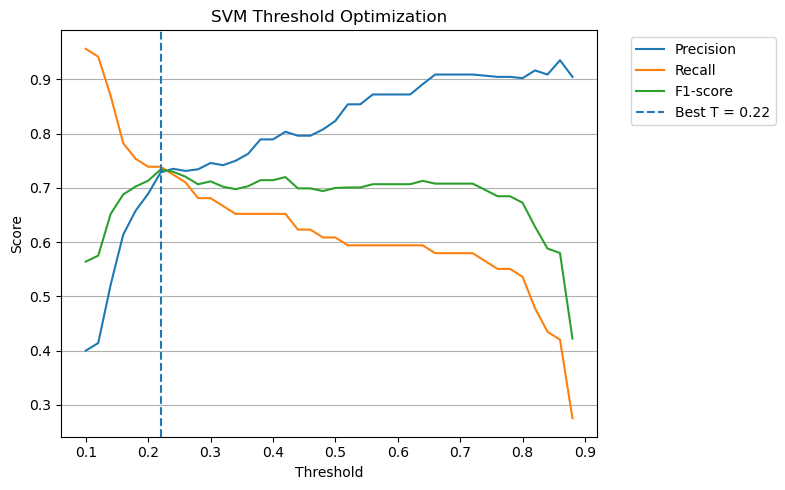

In [ ]:
#Code to obtain the optimal threshold value - SVM 


# 1. Get predicted probabilities
#For each observation in the validation set, the model returns the probability of belonging to the positive class (Survived = 1)

y_prob = final_model.predict_proba(X_valid_sel)[:, 1]  


# 2. Test different THRESHOLDS

thresholds = np.arange(0.1, 0.9, 0.02)  #tests thresholds from 0.10 to 0.9, in steps of 0.02
results_svm_threshold = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    # If the predicted probability is greater than or equal to threshold t,
    # the observation is classified as positive (1); otherwise, negative (0)
    
    acc_t = accuracy_score(y_valid_aligned, y_pred_t)
    prec_t = precision_score(y_valid_aligned, y_pred_t)
    rec_t = recall_score(y_valid_aligned, y_pred_t)
    f1_t = f1_score(y_valid_aligned, y_pred_t)

    results_svm_threshold.append((t, acc_t, prec_t, rec_t, f1_t))


# 3. Results

df_threshold_svm = pd.DataFrame(
    results_svm_threshold,
    columns=["threshold", "accuracy", "precision", "recall", "f1"]
)

print("=== Top Thresholds SVM (por F1-score) ===")
print(df_threshold_svm.sort_values(by="f1", ascending=False).head())


# Best threshold
best_row_svm = df_threshold_svm.sort_values(by="f1", ascending=False).iloc[0]  ## The optimal threshold is the one that maximizes the F1-score
# (balance between precision and recall) on the validation set
best_threshold_svm = best_row_svm["threshold"]

print(f"\nBest Threshold SVM: {best_threshold_svm:.2f}")
print(best_row_svm)


# 4. Plot

plt.figure(figsize=(8,5))

plt.plot(df_threshold_svm["threshold"], df_threshold_svm["precision"], label="Precision")
plt.plot(df_threshold_svm["threshold"], df_threshold_svm["recall"], label="Recall")
plt.plot(df_threshold_svm["threshold"], df_threshold_svm["f1"], label="F1-score")

plt.axvline(best_threshold_svm, linestyle="--", label=f"Best T = {best_threshold_svm:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("SVM Threshold Optimization")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y")
plt.tight_layout()

plt.show()

>In the code above, the predicted probabilities for the positive class (survived) are first obtained. Then, several threshold values between 0.1 and 0.9 are tested to convert these probabilities into binary predictions.
>For each threshold, performance metrics such as accuracy, precision, recall, and F1‑score are computed. The optimal threshold is selected based on the highest F1‑score, as it provides the best balance between precision and recall. In this case, the optimal threshold is 0.22.
>In practice, this corresponds to choosing the best point on the ROC curve — the threshold that offers the most effective trade‑off between correctly identifying positives and avoiding false positives.

<p>
Next, the final implementation of the SVM model was carried out, including hyperparameter tuning and the definition of the optimal threshold. At this stage, an additional feature set—obtained through an iterative selection process—was also tested. The variables shown in the code below were the ones that produced the best model performance:
["Fare_log", "Age", "FamilySize", "Title", "Pclass", "Sex"]

=== Cross-Validation ===
ROC-AUC scores: [0.8398569  0.88468013 0.80008418 0.87373737 0.89467085]
Mean ROC-AUC  : 0.8586
Std ROC-AUC   : 0.0346

=== SVM - Threshold Optimized ===
Threshold: 0.22
Accuracy : 0.7989
Precision: 0.7619
Recall   : 0.6957
F1-score : 0.7273
ROC-AUC  : 0.8363

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       110
           1       0.76      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179


=== Confusion Matrix ===
[[95 15]
 [21 48]]


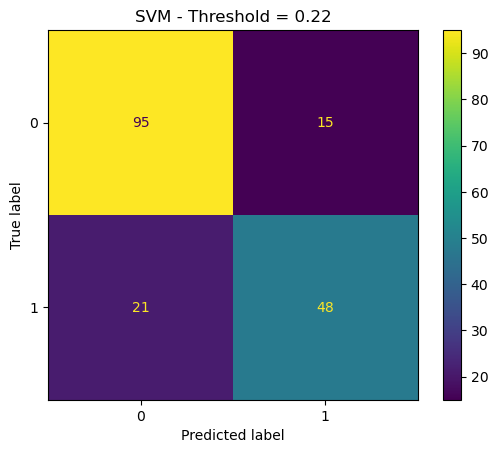

In [ ]:
#Final implementation of the SVM model after hyperparameter tuning, optimal threshold selection, and feature choice from the iterative process


# 1. Create Fare_log

X_train_full = X_train_full.copy()
X_valid_full = X_valid_full.copy()

X_train_full["Fare_log"] = np.log1p(X_train_full["Fare"])
X_valid_full["Fare_log"] = np.log1p(X_valid_full["Fare"])


# 2. Preprocessing function

def build_preprocessor(selected_features):
    # garantir lista plana
    if any(isinstance(x, list) for x in selected_features):
        raise ValueError(f"selected_features contém listas dentro: {selected_features}")

    num_cols = [c for c in selected_features if c in ["Fare_log", "Age", "FamilySize"]]
    onehot_cols = [c for c in selected_features if c in ["Title", "Pclass", "Sex"]]


    # extra validation
    for name, cols in [
        ("num_cols", num_cols),
        ("onehot_cols", onehot_cols)
    ]:
        if any(isinstance(x, list) for x in cols):
            raise ValueError(f"{name} contém listas dentro: {cols}")

    transformers = []

    if num_cols:
        transformers.append(
            ("num", StandardScaler(), num_cols)
        )

    if onehot_cols:
        transformers.append(
            ("oh", OneHotEncoder(handle_unknown="ignore", drop="first"), onehot_cols)
        )

    if not transformers:
        raise ValueError(f"Nenhuma feature válida foi selecionada: {selected_features}")

    return ColumnTransformer(transformers)


# 3. Final Features

selected_features = ["Title", "Pclass", "Age", "FamilySize", "Fare_log", "Sex"]

X_train_sel = X_train_full[selected_features].copy()
X_valid_sel = X_valid_full[selected_features].copy()

y_train_aligned = y_train.loc[X_train_sel.index]
y_valid_aligned = y_valid.loc[X_valid_sel.index]


# 4. Final Pipeline

preprocessor = build_preprocessor(selected_features)

final_model = Pipeline([
    ("prep", preprocessor),
    ("model", SVC(
        kernel="rbf",
        C=1,
        gamma="scale",
        probability=True,
        random_state=0
    ))
])


# 5. Cross-validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

cv_roc_auc = cross_val_score(
    final_model,
    X_train_sel,
    y_train_aligned,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("=== Cross-Validation ===")
print(f"ROC-AUC scores: {cv_roc_auc}")
print(f"Mean ROC-AUC  : {cv_roc_auc.mean():.4f}")
print(f"Std ROC-AUC   : {cv_roc_auc.std():.4f}")

# 6. Train on the full training set

final_model.fit(X_train_sel, y_train_aligned)


# 7. Predict on the validation set (with threshold)

best_threshold = 0.22

y_prob = final_model.predict_proba(X_valid_sel)[:, 1]
y_pred = (y_prob >= best_threshold).astype(int)


# 8. Metrics

accuracy = accuracy_score(y_valid_aligned, y_pred)
precision = precision_score(y_valid_aligned, y_pred)
recall = recall_score(y_valid_aligned, y_pred)
f1 = f1_score(y_valid_aligned, y_pred)
roc_auc = roc_auc_score(y_valid_aligned, y_prob) 

print("\n=== SVM - Threshold Optimized ===")
print(f"Threshold: {best_threshold}")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_valid_aligned, y_pred))


# 9. Confusion Matrix

cm_svm = confusion_matrix(y_valid_aligned, y_pred)
print("\n=== Confusion Matrix ===")
print(cm_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp.plot()
plt.title(f"SVM - Threshold = {best_threshold}")
plt.show()

>After the final optimization of the SVM model, its performance was compared on both the training set and the test set. This step was necessary because the previous cross‑validation procedures evaluated performance only on the validation folds.
>By comparing results on training and test data, it was possible to assess potential overfitting, checking whether the model performs significantly better on training data than on the test set (see code below).
</p>

In [ ]:

# 1. Create Fare_log

X_train_full = X_train_full.copy()
X_valid_full = X_valid_full.copy()

X_train_full["Fare_log"] = np.log1p(X_train_full["Fare"])
X_valid_full["Fare_log"] = np.log1p(X_valid_full["Fare"])


# 2. Preprocessing

def build_preprocessor(selected_features):

    num_cols = [c for c in selected_features if c in ["Fare_log", "Age", "FamilySize"]]
    onehot_cols = [c for c in selected_features if c in ["Title", "Pclass", "Sex"]]

    transformers = []

    if num_cols:
        transformers.append(("num", StandardScaler(), num_cols))

    if onehot_cols:
        transformers.append(
            ("oh", OneHotEncoder(handle_unknown="ignore", drop="first"), onehot_cols)
        )

    return ColumnTransformer(transformers=transformers)


# 3. Features

selected_features = ["Title", "Pclass", "Age", "FamilySize", "Fare_log", "Sex"]


# Combine training + validation sets
X_dev = pd.concat([
    X_train_full[selected_features],
    X_valid_full[selected_features]
], axis=0)

y_dev = pd.concat([
    y_train.loc[X_train_full.index],
    y_valid.loc[X_valid_full.index]
], axis=0)

X_dev = X_dev.loc[y_dev.index]
y_dev = y_dev.loc[X_dev.index]


# 4. SVM model

preprocessor = build_preprocessor(selected_features)

final_model_svm = Pipeline([
    ("prep", preprocessor),
    ("model", SVC(
        kernel="rbf",
        C=1,
        gamma="scale",
        probability=True,
        random_state=0
    ))
])

best_threshold = 0.22


# 5. Repeated Stratified K-Fold 
# Cross-validation using Stratified K-Fold repeated multiple times (10) for more robust results

rskf = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=0
)

results = []

for fold_idx, (train_idx, valid_idx) in enumerate(rskf.split(X_dev, y_dev), start=1):

    X_train_fold = X_dev.iloc[train_idx]
    X_valid_fold = X_dev.iloc[valid_idx]
    y_train_fold = y_dev.iloc[train_idx]
    y_valid_fold = y_dev.iloc[valid_idx]


    # train model
    final_model_svm.fit(X_train_fold, y_train_fold)

   
    # training metrics
    y_train_prob = final_model_svm.predict_proba(X_train_fold)[:, 1]
    y_train_pred = (y_train_prob >= best_threshold).astype(int)

    train_accuracy = accuracy_score(y_train_fold, y_train_pred)
    train_precision = precision_score(y_train_fold, y_train_pred, zero_division=0)
    train_recall = recall_score(y_train_fold, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_train_fold, y_train_pred, zero_division=0)
    train_roc_auc = roc_auc_score(y_train_fold, y_train_prob)

   
    # validation metrics
    y_valid_prob = final_model_svm.predict_proba(X_valid_fold)[:, 1]
    y_valid_pred = (y_valid_prob >= best_threshold).astype(int)

    valid_accuracy = accuracy_score(y_valid_fold, y_valid_pred)
    valid_precision = precision_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_recall = recall_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_f1 = f1_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_roc_auc = roc_auc_score(y_valid_fold, y_valid_prob)


    # store results
    results.append({
        "fold": fold_idx,

        "train_accuracy": train_accuracy,
        "train_precision": train_precision,
        "train_recall": train_recall,
        "train_f1": train_f1,
        "train_roc_auc": train_roc_auc,

        "valid_accuracy": valid_accuracy,
        "valid_precision": valid_precision,
        "valid_recall": valid_recall,
        "valid_f1": valid_f1,
        "valid_roc_auc": valid_roc_auc
    })

results_df = pd.DataFrame(results)


# 6. Results

print("=== Resultados por fold (amostra) ===")
print(results_df.head())

print("\n=== Média treino ===")
print(results_df[[
    "train_accuracy", "train_precision", "train_recall", "train_f1", "train_roc_auc"
]].mean().round(4))

print("\n=== Média validação ===")
print(results_df[[
    "valid_accuracy", "valid_precision", "valid_recall", "valid_f1", "valid_roc_auc"
]].mean().round(4))

print("\n=== Desvio padrão treino ===")
print(results_df[[
    "train_accuracy", "train_precision", "train_recall", "train_f1", "train_roc_auc"
]].std().round(4))

print("\n=== Desvio padrão validação ===")
print(results_df[[
    "valid_accuracy", "valid_precision", "valid_recall", "valid_f1", "valid_roc_auc"
]].std().round(4))


# 7. Train - Validation Gap

gap = pd.Series({
    "accuracy_gap": results_df["train_accuracy"].mean() - results_df["valid_accuracy"].mean(),
    "precision_gap": results_df["train_precision"].mean() - results_df["valid_precision"].mean(),
    "recall_gap": results_df["train_recall"].mean() - results_df["valid_recall"].mean(),
    "f1_gap": results_df["train_f1"].mean() - results_df["valid_f1"].mean(),
    "roc_auc_gap": results_df["train_roc_auc"].mean() - results_df["valid_roc_auc"].mean()
})

print("\n=== Diferença média treino - validação ===")
print(gap.round(4))


# 8. Simple automatic interpretation

print("\n=== Interpretação ===")
for metric_name, gap_value in gap.items():
    print(f"{metric_name}: {gap_value:.4f}")

    if gap_value > 0.07:
        print(" -> possível overfitting")
    elif gap_value > 0.03:
        print(" -> ligeiro sinal de overfitting")
    else:
        print(" -> sem sinal forte de overfitting")

=== Resultados por fold (amostra) ===
   fold  train_accuracy  train_precision  train_recall  train_f1  \
0     1        0.835443         0.794677      0.768382  0.781308   
1     2        0.829817         0.791506      0.753676  0.772128   
2     3        0.839662         0.796992      0.779412  0.788104   
3     4        0.821378         0.769517      0.761029  0.765250   
4     5        0.823034         0.772388      0.761029  0.766667   

   train_roc_auc  valid_accuracy  valid_precision  valid_recall  valid_f1  \
0       0.878107        0.814607         0.739726      0.794118  0.765957   
1       0.876771        0.808989         0.765625      0.720588  0.742424   
2       0.889229        0.792135         0.754098      0.676471  0.713178   
3       0.874100        0.853933         0.828125      0.779412  0.803030   
4       0.887997        0.779661         0.683544      0.794118  0.734694   

   valid_roc_auc  
0       0.857019  
1       0.835628  
2       0.806350  
3       0.9034

>The average validation results show that the SVM model performs well overall, with an accuracy of 0.8124. Precision (0.7594), recall (0.7512), and F1‑score (0.7537) are very similar, indicating a balanced ability to correctly identify survivors while limiting misclassifications. The ROC‑AUC of 0.8511 further confirms strong discriminative power.

>Regarding generalization, the train–validation gap shows no meaningful signs of overfitting, with only a slight increase in ROC‑AUC on the training set. The low standard deviations across validation metrics also indicate that the model is stable and consistent across cross‑validation iterations.

>Overall, the model demonstrates solid, well‑balanced performance with good generalization capability. The minor overfitting observed is acceptable and does not compromise the model’s effectiveness.


=== Confusion Matrix média ===
[[93.4 16.4]
 [16.9 51.1]]


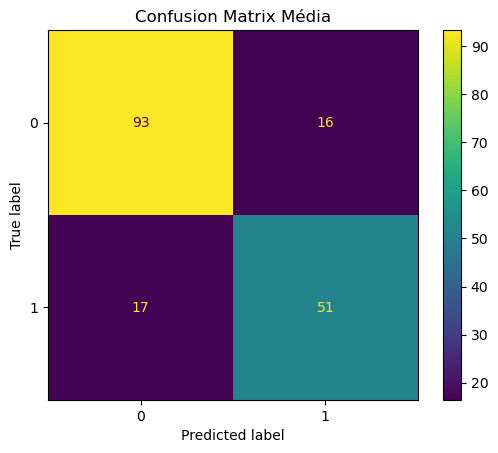

In [ ]:
#Code to obtain the confusion matrix of the optimized SVM model


cms_valid = []

for train_idx, valid_idx in rskf.split(X_dev, y_dev):

    X_train_fold = X_dev.iloc[train_idx]
    X_valid_fold = X_dev.iloc[valid_idx]
    y_train_fold = y_dev.iloc[train_idx]
    y_valid_fold = y_dev.iloc[valid_idx]

    # train
    final_model_svm.fit(X_train_fold, y_train_fold)

    # predict
    y_valid_prob = final_model_svm.predict_proba(X_valid_fold)[:, 1]
    y_valid_pred = (y_valid_prob >= best_threshold).astype(int)

    # store confusion matrix
    cms_valid.append(confusion_matrix(y_valid_fold, y_valid_pred))

# mean confusion matrix
mean_cm = np.mean(cms_valid, axis=0)

print("\n=== Confusion Matrix média ===")
print(np.round(mean_cm, 1))

disp = ConfusionMatrixDisplay(confusion_matrix=mean_cm)
disp.plot(values_format=".0f")
plt.title("Confusion Matrix Média")
plt.show()

<p>
The same procedure was then applied to the Random Forest model. Unlike the SVM, the baseline Random Forest did not include normalization of numerical variables or the log transformation of Fare, since tree‑based models are insensitive to feature scale and robust to outliers.

Additionally, no explicit removal of redundant variables was performed. However, Age and Fare were preferred over AgeGroup and FareCategory, as tree‑based models naturally perform splits on continuous variables and can capture non‑linear relationships without requiring prior discretization.

In [ ]:
#Feature selection for Random Forest model - using Greedy Forward Selection


# Define features

candidate_features = ["Sex", "Pclass", "Age", "Fare", "IsAlone", "HasCabin", "Embarked", "FamilySize", "Title"]

X_train_sel = X_train_full[candidate_features].copy()
X_val_sel = X_valid_full[candidate_features].copy()

y_train_aligned = y_train.loc[X_train_sel.index]
y_val_aligned = y_valid.loc[X_val_sel.index]


def build_preprocessor(selected_features):
    onehot_cols = [c for c in selected_features if c in ["Embarked", "Pclass", "Title", "HasCabin", "Sex", "IsAlone"]]
    numeric_cols = [c for c in selected_features if c in ["Age", "Fare", "FamilySize"]]

    transformers = []


    if onehot_cols:
        transformers.append(
            ("oh", OneHotEncoder(handle_unknown="ignore", drop="first"), onehot_cols)
        )

    if numeric_cols:
        transformers.append(
            ("num", "passthrough", numeric_cols)
        )

    if not transformers:
        raise ValueError(f"Nenhuma feature válida foi selecionada: {selected_features}")

    return ColumnTransformer(transformers)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

selected_features = []
remaining_features = candidate_features.copy()
results_forward = []
best_score_so_far = -1

while remaining_features:
    scores_this_round = []

    for feature in remaining_features:
        current_features = selected_features + [feature]

        preprocessor = build_preprocessor(current_features)

        pipe = Pipeline([
            ("prep", preprocessor),
            ("model", RandomForestClassifier(
                n_estimators=200,
                random_state=0,
                n_jobs=-1
            ))
        ])

        score = cross_val_score(
            pipe,
            X_train_sel[current_features],
            y_train.loc[X_train_sel.index],
            cv=cv,
            scoring="roc_auc",
            n_jobs=-1
        ).mean()

        scores_this_round.append((feature, score, current_features))

    best_feature, best_score, best_set = max(scores_this_round, key=lambda x: x[1])

    results_forward.append({
        "Step": len(selected_features) + 1,
        "Added_Feature": best_feature,
        "Selected_Features": best_set.copy(),
        "CV_ROC_AUC": best_score
    })

    if best_score > best_score_so_far:
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        best_score_so_far = best_score
    else:
        break

results_forward_df = pd.DataFrame(results_forward)

print(results_forward_df)
print("\nFeatures finais selecionadas:", selected_features)
print("Melhor ROC-AUC:", best_score_so_far)

   Step Added_Feature                                  Selected_Features  \
0     1         Title                                            [Title]   
1     2        Pclass                                    [Title, Pclass]   
2     3    FamilySize                        [Title, Pclass, FamilySize]   
3     4      HasCabin              [Title, Pclass, FamilySize, HasCabin]   
4     5           Sex         [Title, Pclass, FamilySize, HasCabin, Sex]   
5     6      Embarked  [Title, Pclass, FamilySize, HasCabin, Sex, Emb...   

   CV_ROC_AUC  
0    0.797982  
1    0.846826  
2    0.861894  
3    0.868740  
4    0.874226  
5    0.873788  

Features finais selecionadas: ['Title', 'Pclass', 'FamilySize', 'HasCabin', 'Sex']
Melhor ROC-AUC: 0.8742260246139557


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
=== Random Forest - Best Params ===
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best CV ROC-AUC: 0.8764

=== Random Forest - Validation Metrics ===
Accuracy : 0.7989
Precision: 0.7895
Recall   : 0.6522
F1-score : 0.7143
ROC-AUC  : 0.8492

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       110
           1       0.79      0.65      0.71        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179


=== Confusion Matrix ===
[[98 12]
 [24 45]]


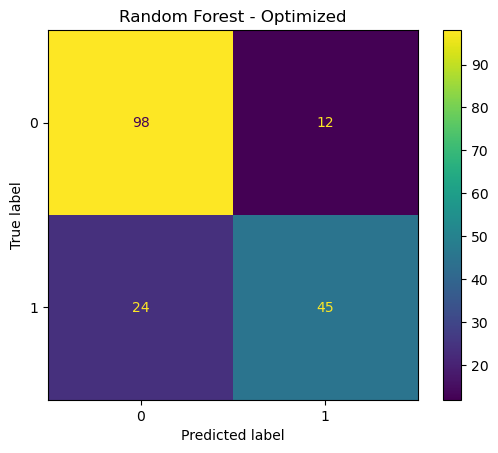

                                                params  mean_test_score  \
173  {'model__max_depth': 20, 'model__max_features'...         0.876430   
38   {'model__max_depth': None, 'model__max_feature...         0.876430   
200  {'model__max_depth': 20, 'model__max_features'...         0.876430   
11   {'model__max_depth': None, 'model__max_feature...         0.876430   
119  {'model__max_depth': 10, 'model__max_features'...         0.876346   
146  {'model__max_depth': 10, 'model__max_features'...         0.876346   
172  {'model__max_depth': 20, 'model__max_features'...         0.876052   
199  {'model__max_depth': 20, 'model__max_features'...         0.876052   
10   {'model__max_depth': None, 'model__max_feature...         0.876052   
37   {'model__max_depth': None, 'model__max_feature...         0.876052   

     rank_test_score  
173                1  
38                 1  
200                1  
11                 1  
119                5  
146                5  
172          

In [ ]:
#Hyperparameter optimization for the Random Forest model using the selected variables (from feature selection)


# 1. Preprocessing - Random Forest

def build_preprocessor_rf(selected_features):
    num_cols = [c for c in selected_features if c in ["FamilySize"]]
    onehot_cols = [c for c in selected_features if c in ["Sex", "Pclass", "HasCabin", "Title"]]

    transformers = []

    if num_cols:
        transformers.append(("num", "passthrough", num_cols))

    if onehot_cols:
        transformers.append((
            "oh",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            onehot_cols
        ))

    return ColumnTransformer(transformers)


# 2. Final Random Forest features

selected_features_rf = ["FamilySize", "Sex", "HasCabin", "Pclass", "Title"]

X_train_rf_sel = X_train_full[selected_features_rf].copy()
X_valid_rf_sel = X_valid_full[selected_features_rf].copy()

y_train_rf = y_train.loc[X_train_rf_sel.index]
y_valid_rf = y_valid.loc[X_valid_rf_sel.index]

preprocessor_rf = build_preprocessor_rf(selected_features_rf)

baseline_rf = Pipeline([
    ("prep", preprocessor_rf),
    ("model", RandomForestClassifier(random_state=0))
])


# 3. Cross-validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)


# 4. GridSearchCV

param_grid_rf = {
    "model__n_estimators": [100, 200, 300],  #nº de árvores na floresta
    "model__max_depth": [None, 5, 10, 20],  #profundidade máxima das árvores (controla complexidade)
    "model__min_samples_split": [2, 5, 10],  #nº mínimo de de amostras para dividir um nó
    "model__min_samples_leaf": [1, 2, 4],    #nº mínimo de amostras em cada folha
    "model__max_features": ["sqrt", "log2"]   #nº de variáveis consideradas em cada divisão
}

grid_rf = GridSearchCV(
    baseline_rf,
    param_grid_rf,
    cv=cv,
    scoring="roc_auc",  #o desempenho é medido com base na métrica RO-AUC
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_rf_sel, y_train_rf)

print("=== Random Forest - Best Params ===")
print(grid_rf.best_params_)
print(f"Best CV ROC-AUC: {grid_rf.best_score_:.4f}")

best_rf = grid_rf.best_estimator_

# 5. Evaluation on the validation set

y_pred_rf = best_rf.predict(X_valid_rf_sel)
y_prob_rf = best_rf.predict_proba(X_valid_rf_sel)[:, 1]

acc_rf = accuracy_score(y_valid_rf, y_pred_rf)
prec_rf = precision_score(y_valid_rf, y_pred_rf)
rec_rf = recall_score(y_valid_rf, y_pred_rf)
f1_rf = f1_score(y_valid_rf, y_pred_rf)
roc_rf = roc_auc_score(y_valid_rf, y_prob_rf)

print("\n=== Random Forest - Validation Metrics ===")
print(f"Accuracy : {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall   : {rec_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_rf:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_valid_rf, y_pred_rf))

cm_rf = confusion_matrix(y_valid_rf, y_pred_rf)
print("\n=== Confusion Matrix ===")
print(cm_rf)

ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot()
plt.title("Random Forest - Optimized")
plt.show()


# 6. Table of tested results

rf_results = pd.DataFrame(grid_rf.cv_results_)
print(
    rf_results[["params", "mean_test_score", "rank_test_score"]]
    .sort_values("rank_test_score")
    .head(10)
)

>The best hyperparameter combination for the Random Forest model, optimized for ROC‑AUC, was {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 300}.

>However, the recall metric was relatively low (0.6522), indicating that the model had limited ability to correctly identify the surviving passengers.

<p>
To address this issue, the decision threshold was optimized. The assumption was that the default threshold (0.5) might be too high, making the model more conservative when classifying survivors and contributing to the lower recall observed.
</p>

=== Top Thresholds Random Forest (por F1-score) ===
    threshold  accuracy  precision    recall        f1
13       0.36  0.776536   0.683544  0.782609  0.729730
12       0.34  0.776536   0.683544  0.782609  0.729730
2        0.14  0.759777   0.647727  0.826087  0.726115
3        0.16  0.759777   0.647727  0.826087  0.726115
4        0.18  0.759777   0.647727  0.826087  0.726115

Best Threshold Random Forest: 0.36
threshold    0.360000
accuracy     0.776536
precision    0.683544
recall       0.782609
f1           0.729730
Name: 13, dtype: float64


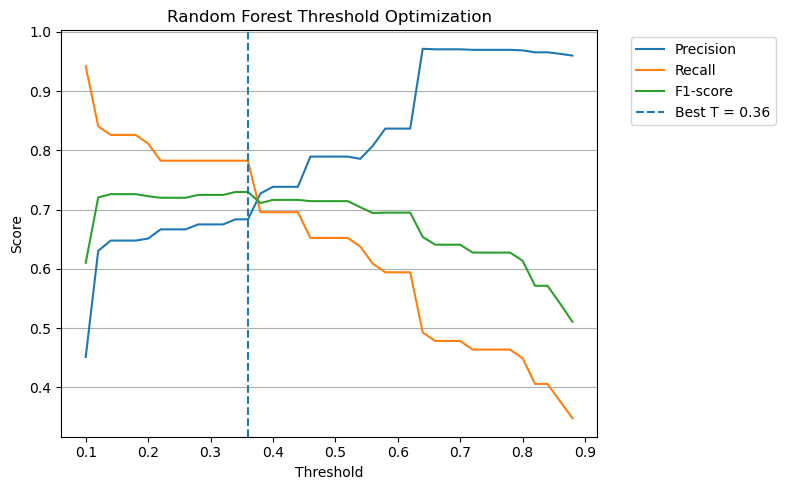

In [ ]:
#Code to determine the optimal Threshold value for Random Forest


# 1. Get predicted probabilities

y_prob_rf = best_rf.predict_proba(X_valid_rf_sel)[:, 1]


# 2. Test different thresholds

thresholds = np.arange(0.1, 0.9, 0.02)
results_rf_threshold = []

for t in thresholds:
    y_pred_t = (y_prob_rf >= t).astype(int)

    acc_t = accuracy_score(y_valid_rf, y_pred_t)
    prec_t = precision_score(y_valid_rf, y_pred_t)
    rec_t = recall_score(y_valid_rf, y_pred_t)
    f1_t = f1_score(y_valid_rf, y_pred_t)

    results_rf_threshold.append((t, acc_t, prec_t, rec_t, f1_t))



# 3. Results

df_threshold_rf = pd.DataFrame(
    results_rf_threshold,
    columns=["threshold", "accuracy", "precision", "recall", "f1"]
)

print("=== Top Thresholds Random Forest (por F1-score) ===")
print(df_threshold_rf.sort_values(by="f1", ascending=False).head())


# Best threshold
best_row_rf = df_threshold_rf.sort_values(by="f1", ascending=False).iloc[0]
best_threshold_rf = best_row_rf["threshold"]

print(f"\nBest Threshold Random Forest: {best_threshold_rf:.2f}")
print(best_row_rf)


# 4. Plot

plt.figure(figsize=(8,5))

plt.plot(df_threshold_rf["threshold"], df_threshold_rf["precision"], label="Precision")
plt.plot(df_threshold_rf["threshold"], df_threshold_rf["recall"], label="Recall")
plt.plot(df_threshold_rf["threshold"], df_threshold_rf["f1"], label="F1-score")

plt.axvline(best_threshold_rf, linestyle="--", label=f"Best T = {best_threshold_rf:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Random Forest Threshold Optimization")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y")
plt.tight_layout()

plt.show()

> By adjusting the threshold to 0.34, recall increased substantially (to around 0.78). However, this improvement came with a notable drop in precision, highlighting the trade‑off between the two metrics.

<p>
Given these results, a new approach was explored by testing different feature sets, since the choice of variables has a significant impact on machine‑learning model performance.

Therefore, the feature set based on the feature importance previously obtained from the Random Forest Classifier (used at the beginning of Part C) was selected for further evaluation.

=== Random Forest - Threshold Optimized ===
Threshold: 0.34
Accuracy : 0.8268
Precision: 0.7879
Recall   : 0.7536
F1-score : 0.7704
ROC-AUC  : 0.8506

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       110
           1       0.79      0.75      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179


=== Confusion Matrix ===
[[96 14]
 [17 52]]


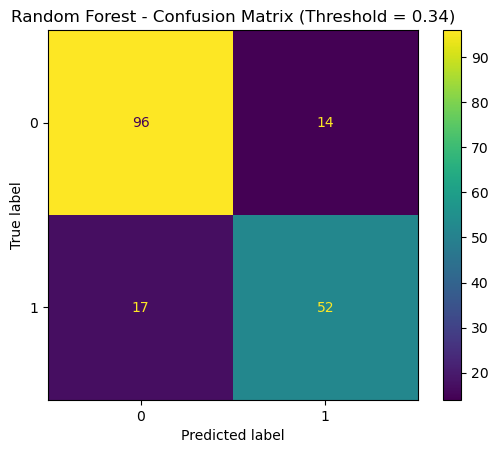

In [ ]:
# Implementation of the Random Forest model after hyperparameter tuning, optimal threshold selection, and feature modification (based on Feature Importance calculated using Random Forest Classifier)

# 1. Define features

selected_features = ["Age", "Fare", "Title", "Pclass", "Sex"]

X_train_sel = X_train_full[selected_features].copy()
X_val_sel = X_valid_full[selected_features].copy()

y_train_aligned = y_train.loc[X_train_sel.index]
y_val_aligned = y_valid.loc[X_val_sel.index]


# 2. Define column types

numeric_cols = ["Age", "Fare"]
onehot_cols = ["Title", "Pclass", "Sex"]


# 3. Pipelines by variable type

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 4. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])

# 5. Final pipeline with Random Forest
# Replaced here with the best parameters

best_threshold_rf = 0.34

model_rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,        # <- substituí pelo best param
        max_depth=None,          # <- substituí pelo best param
        min_samples_split=2,     # <- substituí pelo best param
        min_samples_leaf=2,      # <- substituí pelo best param
        max_features="sqrt",     # <- substituí pelo best param
        random_state=0
    ))
])


# 6. Train model

model_rf.fit(X_train_sel, y_train_aligned)


# 7. Prediction with threshold = 0.34

y_prob_rf = model_rf.predict_proba(X_val_sel)[:, 1]
y_pred_rf = (y_prob_rf >= best_threshold_rf).astype(int)


# 8. Metrics

accuracy_rf = accuracy_score(y_val_aligned, y_pred_rf)
precision_rf = precision_score(y_val_aligned, y_pred_rf)
recall_rf = recall_score(y_val_aligned, y_pred_rf)
f1_rf = f1_score(y_val_aligned, y_pred_rf)
roc_auc_rf = roc_auc_score(y_val_aligned, y_prob_rf)

print("=== Random Forest - Threshold Optimized ===")
print(f"Threshold: {best_threshold_rf:.2f}")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_val_aligned, y_pred_rf))


# 9. Confusion Matrix


cm_rf = confusion_matrix(y_val_aligned, y_pred_rf)
print("\n=== Confusion Matrix ===")
print(cm_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title(f"Random Forest - Confusion Matrix (Threshold = {best_threshold_rf:.2f})")
plt.show()

<p>
Next, as was done with the <b>SVM model</b>, the performance of the <b>Random Forest</b> model was compared on the <b>training and test</b> sets in order to assess the potential occurrence of <b>overfitting</b>.
</p>

In [ ]:
# 1. Preprocessing

def build_preprocessor(selected_features):

    num_cols = [c for c in selected_features if c in ["Fare", "Age"]]
    onehot_cols = [c for c in selected_features if c in ["Title", "Pclass", "Sex"]]

    transformers = []

    if num_cols:
        transformers.append(("num", "passthrough", num_cols))

    if onehot_cols:
        transformers.append(
            ("oh", OneHotEncoder(handle_unknown="ignore", drop="first"), onehot_cols)
        )

    return ColumnTransformer(transformers)


# 2. Data

selected_features = ["Title", "Pclass", "Age", "Sex", "Fare"]


# combine train + validation
X_dev = pd.concat([
    X_train_full[selected_features],
    X_valid_full[selected_features]
], axis=0)

y_dev = pd.concat([
    y_train.loc[X_train_full.index],
    y_valid.loc[X_valid_full.index]
], axis=0)

X_dev = X_dev.loc[y_dev.index]


# 3. Random Forest Model

preprocessor = build_preprocessor(selected_features)

final_model_rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth = None,
        min_samples_split=2,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=0
    ))
])

best_threshold = 0.34


# 4. Repeated Stratified K-Fold

rskf = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=0
)

results = []

for fold_idx, (train_idx, valid_idx) in enumerate(rskf.split(X_dev, y_dev), start=1):

    X_train_fold = X_dev.iloc[train_idx]
    X_valid_fold = X_dev.iloc[valid_idx]
    y_train_fold = y_dev.iloc[train_idx]
    y_valid_fold = y_dev.iloc[valid_idx]


    # model training
    final_model_rf.fit(X_train_fold, y_train_fold)

    
    # training metrics
    y_train_prob = final_model_rf.predict_proba(X_train_fold)[:, 1]
    y_train_pred = (y_train_prob >= best_threshold).astype(int)

    train_accuracy = accuracy_score(y_train_fold, y_train_pred)
    train_precision = precision_score(y_train_fold, y_train_pred, zero_division=0)
    train_recall = recall_score(y_train_fold, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_train_fold, y_train_pred, zero_division=0)
    train_roc_auc = roc_auc_score(y_train_fold, y_train_prob)

    
    # validation metrics
    y_valid_prob = final_model_rf.predict_proba(X_valid_fold)[:, 1]
    y_valid_pred = (y_valid_prob >= best_threshold).astype(int)

    valid_accuracy = accuracy_score(y_valid_fold, y_valid_pred)
    valid_precision = precision_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_recall = recall_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_f1 = f1_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_roc_auc = roc_auc_score(y_valid_fold, y_valid_prob)


    # store results
    results.append({
        "fold": fold_idx,

        "train_accuracy": train_accuracy,
        "train_precision": train_precision,
        "train_recall": train_recall,
        "train_f1": train_f1,
        "train_roc_auc": train_roc_auc,

        "valid_accuracy": valid_accuracy,
        "valid_precision": valid_precision,
        "valid_recall": valid_recall,
        "valid_f1": valid_f1,
        "valid_roc_auc": valid_roc_auc
    })

results_df = pd.DataFrame(results)


# 5. Results

print("=== Resultados por fold (amostra) ===")
print(results_df.head())

print("\n=== Média treino ===")
print(results_df[[ 
    "train_accuracy", "train_precision", "train_recall", "train_f1", "train_roc_auc"
]].mean().round(4))

print("\n=== Média validação ===")
print(results_df[[ 
    "valid_accuracy", "valid_precision", "valid_recall", "valid_f1", "valid_roc_auc"
]].mean().round(4))

print("\n=== Desvio padrão treino ===")
print(results_df[[ 
    "train_accuracy", "train_precision", "train_recall", "train_f1", "train_roc_auc"
]].std().round(4))

print("\n=== Desvio padrão validação ===")
print(results_df[[ 
    "valid_accuracy", "valid_precision", "valid_recall", "valid_f1", "valid_roc_auc"
]].std().round(4))


# 6. Training - Validation gap

gap = pd.Series({
    "accuracy_gap": results_df["train_accuracy"].mean() - results_df["valid_accuracy"].mean(),
    "precision_gap": results_df["train_precision"].mean() - results_df["valid_precision"].mean(),
    "recall_gap": results_df["train_recall"].mean() - results_df["valid_recall"].mean(),
    "f1_gap": results_df["train_f1"].mean() - results_df["valid_f1"].mean(),
    "roc_auc_gap": results_df["train_roc_auc"].mean() - results_df["valid_roc_auc"].mean()
})

print("\n=== Diferença média treino - validação ===")
print(gap.round(4))


# 7. Simple automatic interpretation

print("\n=== Interpretação ===")
for metric_name, gap_value in gap.items():
    print(f"{metric_name}: {gap_value:.4f}")

    if gap_value > 0.07:
        print(" -> possível overfitting")
    elif gap_value > 0.03:
        print(" -> ligeiro sinal de overfitting")
    else:
        print(" -> sem sinal forte de overfitting")

=== Resultados por fold (amostra) ===
   fold  train_accuracy  train_precision  train_recall  train_f1  \
0     1        0.924051         0.873288      0.937500  0.904255   
1     2        0.918425         0.861486      0.937500  0.897887   
2     3        0.921238         0.862416      0.944853  0.901754   
3     4        0.915612         0.855705      0.937500  0.894737   
4     5        0.919944         0.864407      0.937500  0.899471   

   train_roc_auc  valid_accuracy  valid_precision  valid_recall  valid_f1  \
0       0.984813        0.808989         0.723684      0.808824  0.763889   
1       0.979846        0.842697         0.785714      0.808824  0.797101   
2       0.982924        0.831461         0.787879      0.764706  0.776119   
3       0.981165        0.859551         0.802817      0.838235  0.820144   
4       0.980987        0.768362         0.648352      0.867647  0.742138   

   valid_roc_auc  
0       0.839773  
1       0.898596  
2       0.828944  
3       0.9039

>Based on the output of the code, it can be concluded that the <b>Random Forest</b> model exhibits signs of <b>overfitting</b>, since the gap values across the metrics are greater than 0.1, reaching a <b>gap of approximately 0.13</b> (in the precision_gap, recall_gap, and f1_gap metrics). This indicates that the model is <b>memorizing the training data</b> rather than generalizing to new data. <br><br>
This behavior was expected, given that no constraints were imposed on the model’s complexity, particularly regarding tree depth (<b>max_depth = None</b>). <br><br>

>In order to mitigate this issue, an iterative process of <b>manual hyperparameter tuning</b> was carried out. At this stage, the features Sex, Title, Age, Fare, and Pclass</b> were used, along with the <b>threshold of 0.34</b>, previously defined as the optimal value. <br><br> The results of the Random Forest model training and the comparison between performance on the training and validation sets are presented below, with the aim of assessing whether the <b>overfitting</b> problem has been reduced. </p>

In [ ]:
# 1. Preprocessing

def build_preprocessor(selected_features):

    num_cols = [c for c in selected_features if c in ["Fare", "Age"]]
    onehot_cols = [c for c in selected_features if c in ["Title", "Pclass", "Sex"]]

    transformers = []

    if num_cols:
        transformers.append(("num", "passthrough", num_cols))

    if onehot_cols:
        transformers.append(
            ("oh", OneHotEncoder(handle_unknown="ignore", drop="first"), onehot_cols)
        )

    return ColumnTransformer(transformers)



# 2. Data

selected_features = ["Title", "Pclass", "Age", "Sex", "Fare"]


# combine train + validation
X_dev = pd.concat([
    X_train_full[selected_features],
    X_valid_full[selected_features]
], axis=0)

y_dev = pd.concat([
    y_train.loc[X_train_full.index],
    y_valid.loc[X_valid_full.index]
], axis=0)

X_dev = X_dev.loc[y_dev.index]


# 3. Random Forest Model

preprocessor = build_preprocessor(selected_features)

final_model_rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth = 6,
        min_samples_split=5,
        min_samples_leaf=3,
        max_features=0.5,
        random_state=0
    ))
])

best_threshold = 0.34


# 4. Repeated Stratified K-Fold

rskf = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=0
)

results = []

for fold_idx, (train_idx, valid_idx) in enumerate(rskf.split(X_dev, y_dev), start=1):

    X_train_fold = X_dev.iloc[train_idx]
    X_valid_fold = X_dev.iloc[valid_idx]
    y_train_fold = y_dev.iloc[train_idx]
    y_valid_fold = y_dev.iloc[valid_idx]


    # model training
    final_model_rf.fit(X_train_fold, y_train_fold)


    # training metrics
    y_train_prob = final_model_rf.predict_proba(X_train_fold)[:, 1]
    y_train_pred = (y_train_prob >= best_threshold).astype(int)

    train_accuracy = accuracy_score(y_train_fold, y_train_pred)
    train_precision = precision_score(y_train_fold, y_train_pred, zero_division=0)
    train_recall = recall_score(y_train_fold, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_train_fold, y_train_pred, zero_division=0)
    train_roc_auc = roc_auc_score(y_train_fold, y_train_prob)

    
    # validation metrics
    y_valid_prob = final_model_rf.predict_proba(X_valid_fold)[:, 1]
    y_valid_pred = (y_valid_prob >= best_threshold).astype(int)

    valid_accuracy = accuracy_score(y_valid_fold, y_valid_pred)
    valid_precision = precision_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_recall = recall_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_f1 = f1_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_roc_auc = roc_auc_score(y_valid_fold, y_valid_prob)

 
    # store results
    results.append({
        "fold": fold_idx,

        "train_accuracy": train_accuracy,
        "train_precision": train_precision,
        "train_recall": train_recall,
        "train_f1": train_f1,
        "train_roc_auc": train_roc_auc,

        "valid_accuracy": valid_accuracy,
        "valid_precision": valid_precision,
        "valid_recall": valid_recall,
        "valid_f1": valid_f1,
        "valid_roc_auc": valid_roc_auc
    })

results_df = pd.DataFrame(results)


# 5. Results

print("=== Resultados por fold (amostra) ===")
print(results_df.head())

print("\n=== Média treino ===")
print(results_df[[ 
    "train_accuracy", "train_precision", "train_recall", "train_f1", "train_roc_auc"
]].mean().round(4))

print("\n=== Média validação ===")
print(results_df[[ 
    "valid_accuracy", "valid_precision", "valid_recall", "valid_f1", "valid_roc_auc"
]].mean().round(4))

print("\n=== Desvio padrão treino ===")
print(results_df[[ 
    "train_accuracy", "train_precision", "train_recall", "train_f1", "train_roc_auc"
]].std().round(4))

print("\n=== Desvio padrão validação ===")
print(results_df[[ 
    "valid_accuracy", "valid_precision", "valid_recall", "valid_f1", "valid_roc_auc"
]].std().round(4))


# 6. Train - validation gap

gap = pd.Series({
    "accuracy_gap": results_df["train_accuracy"].mean() - results_df["valid_accuracy"].mean(),
    "precision_gap": results_df["train_precision"].mean() - results_df["valid_precision"].mean(),
    "recall_gap": results_df["train_recall"].mean() - results_df["valid_recall"].mean(),
    "f1_gap": results_df["train_f1"].mean() - results_df["valid_f1"].mean(),
    "roc_auc_gap": results_df["train_roc_auc"].mean() - results_df["valid_roc_auc"].mean()
})

print("\n=== Diferença média treino - validação ===")
print(gap.round(4))


# 7. Simples automatic interpretation

print("\n=== Interpretação ===")
for metric_name, gap_value in gap.items():
    print(f"{metric_name}: {gap_value:.4f}")

    if gap_value > 0.07:
        print(" -> possível overfitting")
    elif gap_value > 0.03:
        print(" -> ligeiro sinal de overfitting")
    else:
        print(" -> sem sinal forte de overfitting")

=== Resultados por fold (amostra) ===
   fold  train_accuracy  train_precision  train_recall  train_f1  \
0     1        0.852321         0.770227      0.875000  0.819277   
1     2        0.859353         0.804965      0.834559  0.819495   
2     3        0.860759         0.789298      0.867647  0.826620   
3     4        0.843882         0.760518      0.863971  0.808950   
4     5        0.834270         0.737654      0.878676  0.802013   

   train_roc_auc  valid_accuracy  valid_precision  valid_recall  valid_f1  \
0       0.940234        0.786517         0.687500      0.808824  0.743243   
1       0.932040        0.837079         0.774648      0.808824  0.791367   
2       0.941348        0.792135         0.738462      0.705882  0.721805   
3       0.930733        0.842697         0.763158      0.852941  0.805556   
4       0.934592        0.796610         0.686047      0.867647  0.766234   

   valid_roc_auc  
0       0.848061  
1       0.922794  
2       0.820521  
3       0.9006

>By analyzing the output of the previous code, it can be observed that <b>overfitting has been significantly reduced</b>, no longer representing a relevant issue in the model. <br><br>
However, when examining the average metrics on the validation set, it is noted that, despite a good overall performance, the <b>F1-score (0.7683)</b> still shows <b>room for improvement</b>. <br><br>

>It was considered that the model optimization process was not yet complete. To address this, it was decided to <b>recalculate the optimal threshold value</b> in order to assess whether the value currently being used was positively or negatively influencing the model’s performance.

=== Top Thresholds Random Forest (por F1-score) ===
    threshold  accuracy  precision    recall        f1
18       0.46  0.870056   0.868852  0.779412  0.821705
19       0.48  0.864407   0.879310  0.750000  0.809524
22       0.54  0.864407   0.907407  0.720588  0.803279
20       0.50  0.858757   0.890909  0.720588  0.796748
21       0.52  0.858757   0.890909  0.720588  0.796748

Best Threshold Random Forest: 0.46
threshold    0.460000
accuracy     0.870056
precision    0.868852
recall       0.779412
f1           0.821705
Name: 18, dtype: float64


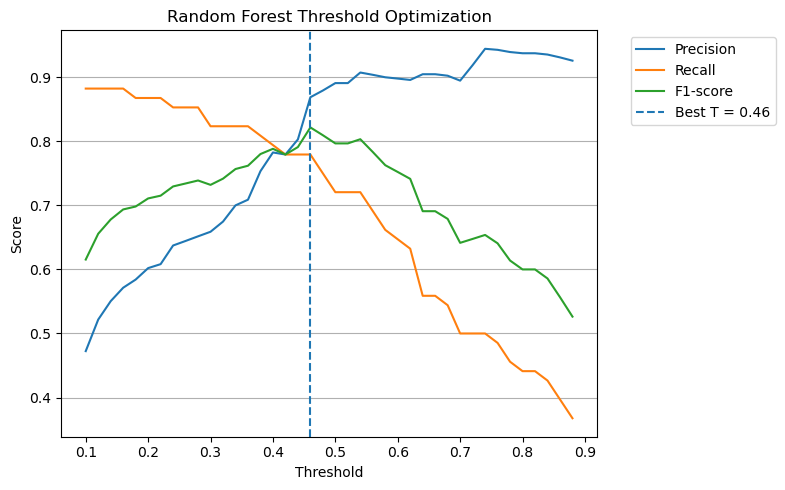

In [ ]:
# Recalculation of the optimal threshold value based on the last trained Random Forest model


# 1. Model training

final_model_rf.fit(X_train_fold, y_train_fold)


# 2. GET VALIDATION PROBABILITIES

y_valid_prob = final_model_rf.predict_proba(X_valid_fold)[:, 1]


# 3. TEST MULTIPLE THRESHOLDS

thresholds = np.arange(0.10, 0.90, 0.02)
results_rf_threshold = []

for t in thresholds:
    y_valid_pred_t = (y_valid_prob >= t).astype(int)

    acc_t = accuracy_score(y_valid_fold, y_valid_pred_t)
    prec_t = precision_score(y_valid_fold, y_valid_pred_t, zero_division=0)
    rec_t = recall_score(y_valid_fold, y_valid_pred_t, zero_division=0)
    f1_t = f1_score(y_valid_fold, y_valid_pred_t, zero_division=0)

    results_rf_threshold.append({
        "threshold": t,
        "accuracy": acc_t,
        "precision": prec_t,
        "recall": rec_t,
        "f1": f1_t
    })


# 4. RESULTS

df_threshold_rf = pd.DataFrame(results_rf_threshold)

print("=== Top Thresholds Random Forest (por F1-score) ===")
print(df_threshold_rf.sort_values(by="f1", ascending=False).head())

best_row_rf = df_threshold_rf.sort_values(by="f1", ascending=False).iloc[0]
best_threshold_rf = best_row_rf["threshold"]

print(f"\nBest Threshold Random Forest: {best_threshold_rf:.2f}")
print(best_row_rf)


# 5. Plot

plt.figure(figsize=(8, 5))
plt.plot(df_threshold_rf["threshold"], df_threshold_rf["precision"], label="Precision")
plt.plot(df_threshold_rf["threshold"], df_threshold_rf["recall"], label="Recall")
plt.plot(df_threshold_rf["threshold"], df_threshold_rf["f1"], label="F1-score")

plt.axvline(best_threshold_rf, linestyle="--", label=f"Best T = {best_threshold_rf:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Random Forest Threshold Optimization")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

Based on the output of the previous code, the <b>threshold value was set to 0.46</b>. Subsequently, the variable <b>FamilySize</b> was added with the aim of improving the <b>F1-score</b> of the <b>Random Forest</b> model, without significantly increasing <b>overfitting</b>. <br><br>
This decision was based on the fact that the inclusion or removal of <b>features</b> can have a significant impact on the performance of <b>machine learning</b> models. <br><br>
After this modification, the model’s performance was evaluated again on both the <b>training and validation</b> sets.
</p>

In [ ]:
# 1. Preprocessing

def build_preprocessor(selected_features):

    num_cols = [c for c in selected_features if c in ["Fare", "Age", "FammilySize"]]
    onehot_cols = [c for c in selected_features if c in ["Title", "Pclass", "Sex"]]

    transformers = []

    if num_cols:
        transformers.append(("num", "passthrough", num_cols))

    if onehot_cols:
        transformers.append(
            ("oh", OneHotEncoder(handle_unknown="ignore", drop="first"), onehot_cols)
        )

    return ColumnTransformer(transformers)


# 2. Data

selected_features = ["Title", "Pclass", "Age", "Sex", "Fare", "FamilySize"]


# combine train + validation
X_dev = pd.concat([
    X_train_full[selected_features],
    X_valid_full[selected_features]
], axis=0)

y_dev = pd.concat([
    y_train.loc[X_train_full.index],
    y_valid.loc[X_valid_full.index]
], axis=0)

X_dev = X_dev.loc[y_dev.index]


# 3. Random Forest Model

preprocessor = build_preprocessor(selected_features)

final_model_rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_split=5,
        min_samples_leaf=3,
        max_features=0.5,
        random_state=0
    ))
])

best_threshold = 0.46


# 4. Repeated Stratified K-Fold

rskf = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=0
)

results = []

for fold_idx, (train_idx, valid_idx) in enumerate(rskf.split(X_dev, y_dev), start=1):

    X_train_fold = X_dev.iloc[train_idx]
    X_valid_fold = X_dev.iloc[valid_idx]
    y_train_fold = y_dev.iloc[train_idx]
    y_valid_fold = y_dev.iloc[valid_idx]


    # model training
    final_model_rf.fit(X_train_fold, y_train_fold)

   
    # training metrics
    y_train_prob = final_model_rf.predict_proba(X_train_fold)[:, 1]
    y_train_pred = (y_train_prob >= best_threshold).astype(int)

    train_accuracy = accuracy_score(y_train_fold, y_train_pred)
    train_precision = precision_score(y_train_fold, y_train_pred, zero_division=0)
    train_recall = recall_score(y_train_fold, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_train_fold, y_train_pred, zero_division=0)
    train_roc_auc = roc_auc_score(y_train_fold, y_train_prob)


    # validation metrics
    y_valid_prob = final_model_rf.predict_proba(X_valid_fold)[:, 1]
    y_valid_pred = (y_valid_prob >= best_threshold).astype(int)

    valid_accuracy = accuracy_score(y_valid_fold, y_valid_pred)
    valid_precision = precision_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_recall = recall_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_f1 = f1_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_roc_auc = roc_auc_score(y_valid_fold, y_valid_prob)


    # store results
    results.append({
        "fold": fold_idx,

        "train_accuracy": train_accuracy,
        "train_precision": train_precision,
        "train_recall": train_recall,
        "train_f1": train_f1,
        "train_roc_auc": train_roc_auc,

        "valid_accuracy": valid_accuracy,
        "valid_precision": valid_precision,
        "valid_recall": valid_recall,
        "valid_f1": valid_f1,
        "valid_roc_auc": valid_roc_auc
    })

results_df = pd.DataFrame(results)


# 5. Results

print("=== Resultados por fold (amostra) ===")
print(results_df.head())

print("\n=== Média treino ===")
print(results_df[[ 
    "train_accuracy", "train_precision", "train_recall", "train_f1", "train_roc_auc"
]].mean().round(4))

print("\n=== Média validação ===")
print(results_df[[ 
    "valid_accuracy", "valid_precision", "valid_recall", "valid_f1", "valid_roc_auc"
]].mean().round(4))

print("\n=== Desvio padrão treino ===")
print(results_df[[ 
    "train_accuracy", "train_precision", "train_recall", "train_f1", "train_roc_auc"
]].std().round(4))

print("\n=== Desvio padrão validação ===")
print(results_df[[ 
    "valid_accuracy", "valid_precision", "valid_recall", "valid_f1", "valid_roc_auc"
]].std().round(4))


# 6. Train - validation gap

gap = pd.Series({
    "accuracy_gap": results_df["train_accuracy"].mean() - results_df["valid_accuracy"].mean(),
    "precision_gap": results_df["train_precision"].mean() - results_df["valid_precision"].mean(),
    "recall_gap": results_df["train_recall"].mean() - results_df["valid_recall"].mean(),
    "f1_gap": results_df["train_f1"].mean() - results_df["valid_f1"].mean(),
    "roc_auc_gap": results_df["train_roc_auc"].mean() - results_df["valid_roc_auc"].mean()
})

print("\n=== Diferença média treino - validação ===")
print(gap.round(4))


# 7. Simple automatic interpretation

print("\n=== Interpretação ===")
for metric_name, gap_value in gap.items():
    print(f"{metric_name}: {gap_value:.4f}")

    if gap_value > 0.07:
        print(" -> possível overfitting")
    elif gap_value > 0.03:
        print(" -> ligeiro sinal de overfitting")
    else:
        print(" -> sem sinal forte de overfitting")

=== Resultados por fold (amostra) ===
   fold  train_accuracy  train_precision  train_recall  train_f1  \
0     1        0.869198         0.874477      0.768382  0.818004   
1     2        0.862166         0.862500      0.761029  0.808594   
2     3        0.864979         0.841085      0.797794  0.818868   
3     4        0.872011         0.860558      0.794118  0.826004   
4     5        0.875000         0.856031      0.808824  0.831758   

   train_roc_auc  valid_accuracy  valid_precision  valid_recall  valid_f1  \
0       0.940234        0.831461         0.796875      0.750000  0.772727   
1       0.932040        0.842697         0.857143      0.705882  0.774194   
2       0.941348        0.814607         0.830189      0.647059  0.727273   
3       0.930733        0.853933         0.862069      0.735294  0.793651   
4       0.934592        0.847458         0.788732      0.823529  0.805755   

   valid_roc_auc  
0       0.848061  
1       0.922794  
2       0.820521  
3       0.9006

>Taking into account the obtained results, it can be concluded that overfitting during training is negligible and does not represent a concern. A slight improvement in the F1-score is also observed (from 0.7683 to 0.7755). However, a significant reduction in recall is noted (from approximately 0.81 to 0.74), indicating a lower ability of the model to correctly identify survivors. <br><br>

Given this trade-off, and with the objective of improving recall, the threshold was adjusted to 0.40, making the model less conservative in classifying survivors.
</p>

In [ ]:
# 1. Preprocessing

def build_preprocessor(selected_features):

    num_cols = [c for c in selected_features if c in ["Fare", "Age", "FammilySize"]]
    onehot_cols = [c for c in selected_features if c in ["Title", "Pclass", "Sex"]]

    transformers = []

    if num_cols:
        transformers.append(("num", "passthrough", num_cols))

    if onehot_cols:
        transformers.append(
            ("oh", OneHotEncoder(handle_unknown="ignore", drop="first"), onehot_cols)
        )

    return ColumnTransformer(transformers)


# 2. Data

selected_features = ["Title", "Pclass", "Age", "Sex", "Fare", "FamilySize"]


# combine train + validation
X_dev = pd.concat([
    X_train_full[selected_features],
    X_valid_full[selected_features]
], axis=0)

y_dev = pd.concat([
    y_train.loc[X_train_full.index],
    y_valid.loc[X_valid_full.index]
], axis=0)

X_dev = X_dev.loc[y_dev.index]


# 3. Random Forest Model

preprocessor = build_preprocessor(selected_features)

final_model_rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_split=5,
        min_samples_leaf=3,
        max_features=0.5,
        random_state=0
    ))
])

best_threshold = 0.4


# 4. Repeated Stratified K-Fold

rskf = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=0
)

results = []

for fold_idx, (train_idx, valid_idx) in enumerate(rskf.split(X_dev, y_dev), start=1):

    X_train_fold = X_dev.iloc[train_idx]
    X_valid_fold = X_dev.iloc[valid_idx]
    y_train_fold = y_dev.iloc[train_idx]
    y_valid_fold = y_dev.iloc[valid_idx]

    # model training
    final_model_rf.fit(X_train_fold, y_train_fold)

   
    # training metrics
    y_train_prob = final_model_rf.predict_proba(X_train_fold)[:, 1]
    y_train_pred = (y_train_prob >= best_threshold).astype(int)

    train_accuracy = accuracy_score(y_train_fold, y_train_pred)
    train_precision = precision_score(y_train_fold, y_train_pred, zero_division=0)
    train_recall = recall_score(y_train_fold, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_train_fold, y_train_pred, zero_division=0)
    train_roc_auc = roc_auc_score(y_train_fold, y_train_prob)


    # validation metrics
    y_valid_prob = final_model_rf.predict_proba(X_valid_fold)[:, 1]
    y_valid_pred = (y_valid_prob >= best_threshold).astype(int)

    valid_accuracy = accuracy_score(y_valid_fold, y_valid_pred)
    valid_precision = precision_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_recall = recall_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_f1 = f1_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_roc_auc = roc_auc_score(y_valid_fold, y_valid_prob)


    # store results
    results.append({
        "fold": fold_idx,

        "train_accuracy": train_accuracy,
        "train_precision": train_precision,
        "train_recall": train_recall,
        "train_f1": train_f1,
        "train_roc_auc": train_roc_auc,

        "valid_accuracy": valid_accuracy,
        "valid_precision": valid_precision,
        "valid_recall": valid_recall,
        "valid_f1": valid_f1,
        "valid_roc_auc": valid_roc_auc
    })

results_df = pd.DataFrame(results)


# 5. Results

print("=== Resultados por fold (amostra) ===")
print(results_df.head())

print("\n=== Média treino ===")
print(results_df[[ 
    "train_accuracy", "train_precision", "train_recall", "train_f1", "train_roc_auc"
]].mean().round(4))

print("\n=== Média validação ===")
print(results_df[[ 
    "valid_accuracy", "valid_precision", "valid_recall", "valid_f1", "valid_roc_auc"
]].mean().round(4))

print("\n=== Desvio padrão treino ===")
print(results_df[[ 
    "train_accuracy", "train_precision", "train_recall", "train_f1", "train_roc_auc"
]].std().round(4))

print("\n=== Desvio padrão validação ===")
print(results_df[[ 
    "valid_accuracy", "valid_precision", "valid_recall", "valid_f1", "valid_roc_auc"
]].std().round(4))


# 6. Train - Validation Gap

gap = pd.Series({
    "accuracy_gap": results_df["train_accuracy"].mean() - results_df["valid_accuracy"].mean(),
    "precision_gap": results_df["train_precision"].mean() - results_df["valid_precision"].mean(),
    "recall_gap": results_df["train_recall"].mean() - results_df["valid_recall"].mean(),
    "f1_gap": results_df["train_f1"].mean() - results_df["valid_f1"].mean(),
    "roc_auc_gap": results_df["train_roc_auc"].mean() - results_df["valid_roc_auc"].mean()
})

print("\n=== Diferença média treino - validação ===")
print(gap.round(4))


# 7. Simple automatic interpretation

print("\n=== Interpretação ===")
for metric_name, gap_value in gap.items():
    print(f"{metric_name}: {gap_value:.4f}")

    if gap_value > 0.07:
        print(" -> possível overfitting")
    elif gap_value > 0.03:
        print(" -> ligeiro sinal de overfitting")
    else:
        print(" -> sem sinal forte de overfitting")

=== Resultados por fold (amostra) ===
   fold  train_accuracy  train_precision  train_recall  train_f1  \
0     1        0.876231         0.835766      0.841912  0.838828   
1     2        0.862166         0.832061      0.801471  0.816479   
2     3        0.863572         0.822878      0.819853  0.821363   
3     4        0.869198         0.825455      0.834559  0.829982   
4     5        0.869382         0.820789      0.841912  0.831216   

   train_roc_auc  valid_accuracy  valid_precision  valid_recall  valid_f1  \
0       0.940234        0.837079         0.774648      0.808824  0.791367   
1       0.932040        0.837079         0.800000      0.764706  0.781955   
2       0.941348        0.820225         0.810345      0.691176  0.746032   
3       0.930733        0.870787         0.835821      0.823529  0.829630   
4       0.934592        0.841808         0.756410      0.867647  0.808219   

   valid_roc_auc  
0       0.848061  
1       0.922794  
2       0.820521  
3       0.9006

>According to the obtained results, a slight improvement in the F1-score is observed (from approximately 0.74 to 0.77). However, this improvement was accompanied by a decrease in precision (from around 0.80 to 0.77), once again highlighting a trade-off between performance metrics. <br><br>Thus, it is concluded that it is necessary to continue the model tuning process in order to achieve a better overall balance between the different performance metrics.</p>

>As a next <b>optimization</b> step, we performed <b>GridSearch</b> again — <b>hyperparameter tuning</b> — but this time using the <b>F1-score</b> as the primary metric to optimize. The output is presented in the code below.
</p>

Fitting 5 folds for each of 384 candidates, totalling 1920 fits
=== Random Forest - Best Params ===
{'model__max_depth': 10, 'model__max_features': 0.7, 'model__min_samples_leaf': 2, 'model__min_samples_split': 8, 'model__n_estimators': 500}
Best CV F1-score: 0.7787

=== Random Forest - Validation Metrics ===
Accuracy : 0.8436
Precision: 0.8475
Recall   : 0.7246
F1-score : 0.7812
ROC-AUC  : 0.8429

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       110
           1       0.85      0.72      0.78        69

    accuracy                           0.84       179
   macro avg       0.84      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179


=== Confusion Matrix ===
[[101   9]
 [ 19  50]]


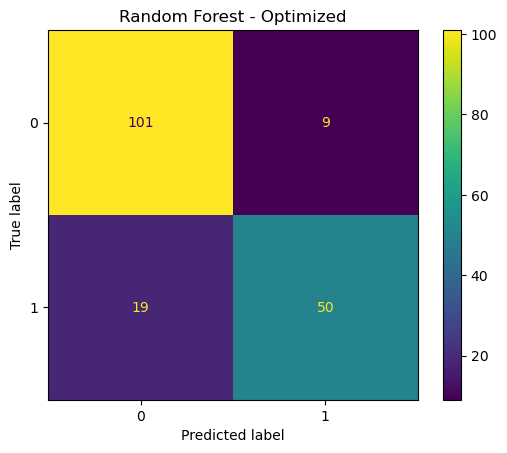

                                                params  mean_test_score  \
344  {'model__max_depth': 10, 'model__max_features'...         0.778719   
290  {'model__max_depth': 10, 'model__max_features'...         0.778409   
339  {'model__max_depth': 10, 'model__max_features'...         0.777969   
289  {'model__max_depth': 10, 'model__max_features'...         0.776930   
343  {'model__max_depth': 10, 'model__max_features'...         0.776358   
292  {'model__max_depth': 10, 'model__max_features'...         0.775652   
293  {'model__max_depth': 10, 'model__max_features'...         0.775507   
295  {'model__max_depth': 10, 'model__max_features'...         0.775383   
354  {'model__max_depth': 10, 'model__max_features'...         0.775138   
294  {'model__max_depth': 10, 'model__max_features'...         0.774853   

     rank_test_score  
344                1  
290                2  
339                3  
289                4  
343                5  
292                6  
293          

In [ ]:
#Recalculation of hyperparameters considering threshold = 0.4 and the 6 features previously defined


# 1. Preprocessing - Random Forest

def build_preprocessor_rf(selected_features):
    num_cols = [c for c in selected_features if c in ["FamilySize", "Age", "Fare"]]
    onehot_cols = [c for c in selected_features if c in ["Sex", "Pclass", "Title"]]

    transformers = []

    if num_cols:
        transformers.append(("num", "passthrough", num_cols))

    if onehot_cols:
        transformers.append((
            "oh",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            onehot_cols
        ))

    return ColumnTransformer(transformers)


# 2. Final Random Forest Features

selected_features_rf = ["FamilySize", "Sex", "Fare", "Pclass", "Title", "Age"]

X_train_rf_sel = X_train_full[selected_features_rf].copy()
X_valid_rf_sel = X_valid_full[selected_features_rf].copy()

y_train_rf = y_train.loc[X_train_rf_sel.index]
y_valid_rf = y_valid.loc[X_valid_rf_sel.index]

preprocessor_rf = build_preprocessor_rf(selected_features_rf)

baseline_rf = Pipeline([
    ("prep", preprocessor_rf),
    ("model", RandomForestClassifier(random_state=0))
])


# 3. Cross-validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)


# 4. GridSearchCV

param_grid_rf = {
    "model__n_estimators": [200, 300, 500],  #number of trees in the forest
    "model__max_depth": [5, 6, 8, 10],  #maximum depth of the trees (controls complexity) - this time we do not test None, as it leads to overfitting
    "model__min_samples_split": [2, 5, 8, 10],  # minimum number of samples required to split a node
    "model__min_samples_leaf": [2,3,4,5],    #  minimum number of samples required at each leaf
    "model__max_features": [0.5, 0.7]   # number of features considered at each split
}

grid_rf = GridSearchCV(
    baseline_rf,
    param_grid_rf,
    cv=cv,
    scoring="f1",  #  # performance is evaluated based on the F1-score metric
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_rf_sel, y_train_rf)

print("=== Random Forest - Best Params ===")
print(grid_rf.best_params_)
print(f"Best CV F1-score: {grid_rf.best_score_:.4f}")

best_rf = grid_rf.best_estimator_


# 5. Evaluation on the validation set

y_pred_rf = best_rf.predict(X_valid_rf_sel)
y_prob_rf = best_rf.predict_proba(X_valid_rf_sel)[:, 1]

acc_rf = accuracy_score(y_valid_rf, y_pred_rf)
prec_rf = precision_score(y_valid_rf, y_pred_rf)
rec_rf = recall_score(y_valid_rf, y_pred_rf)
f1_rf = f1_score(y_valid_rf, y_pred_rf)
roc_rf = roc_auc_score(y_valid_rf, y_prob_rf)

print("\n=== Random Forest - Validation Metrics ===")
print(f"Accuracy : {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall   : {rec_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_rf:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_valid_rf, y_pred_rf))

cm_rf = confusion_matrix(y_valid_rf, y_pred_rf)
print("\n=== Confusion Matrix ===")
print(cm_rf)

ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot()
plt.title("Random Forest - Optimized")
plt.show()


# 6. Table of tested results

rf_results = pd.DataFrame(grid_rf.cv_results_)
print(
    rf_results[["params", "mean_test_score", "rank_test_score"]]
    .sort_values("rank_test_score")
    .head(10)
)

>The best hyperparameters obtained were: ['model__max_depth': 10, 'model__max_features': 0.7, 'model__min_samples_leaf': 2, 'model__min_samples_split': 8, 'model__n_estimators': 500], achieving an F1-score of 0.778 in cross-validation.
</p>

>Subsequently, based on this <b>optimized configuration</b>, the <b>model performance was re-evaluated</b> on the <b>training and test</b> sets, with the aim of assessing the presence of <b>severe overfitting</b> (see the code output below).
</p>

In [ ]:
#Model performance evaluation on training and test sets


# 1. Preprocessing

def build_preprocessor(selected_features):

    num_cols = [c for c in selected_features if c in ["Fare", "Age", "FamilySize"]]
    onehot_cols = [c for c in selected_features if c in ["Title", "Pclass", "Sex"]]

    transformers = []

    if num_cols:
        transformers.append(("num", "passthrough", num_cols))

    if onehot_cols:
        transformers.append(
            ("oh", OneHotEncoder(handle_unknown="ignore", drop="first"), onehot_cols)
        )

    return ColumnTransformer(transformers)


# 2. Data

selected_features = ["Title", "Pclass", "Age", "Sex", "Fare", "FamilySize"]


# combine train + validation
X_dev = pd.concat([
    X_train_full[selected_features],
    X_valid_full[selected_features]
], axis=0)

y_dev = pd.concat([
    y_train.loc[X_train_full.index],
    y_valid.loc[X_valid_full.index]
], axis=0)

X_dev = X_dev.loc[y_dev.index]


# 3. Random Forest model

preprocessor = build_preprocessor(selected_features)

final_model_rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_split=8,
        min_samples_leaf=2,
        max_features=0.7,
        random_state=0
    ))
]) 

best_threshold = 0.4


# 4. Repeated Stratified K-Fold

rskf = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=0
)

results = []

for fold_idx, (train_idx, valid_idx) in enumerate(rskf.split(X_dev, y_dev), start=1):

    X_train_fold = X_dev.iloc[train_idx]
    X_valid_fold = X_dev.iloc[valid_idx]
    y_train_fold = y_dev.iloc[train_idx]
    y_valid_fold = y_dev.iloc[valid_idx]

    # model training
    final_model_rf.fit(X_train_fold, y_train_fold)


    # training metrics
    y_train_prob = final_model_rf.predict_proba(X_train_fold)[:, 1]
    y_train_pred = (y_train_prob >= best_threshold).astype(int)

    train_accuracy = accuracy_score(y_train_fold, y_train_pred)
    train_precision = precision_score(y_train_fold, y_train_pred, zero_division=0)
    train_recall = recall_score(y_train_fold, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_train_fold, y_train_pred, zero_division=0)
    train_roc_auc = roc_auc_score(y_train_fold, y_train_prob)

    
    # validation metrics
    y_valid_prob = final_model_rf.predict_proba(X_valid_fold)[:, 1]
    y_valid_pred = (y_valid_prob >= best_threshold).astype(int)

    valid_accuracy = accuracy_score(y_valid_fold, y_valid_pred)
    valid_precision = precision_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_recall = recall_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_f1 = f1_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_roc_auc = roc_auc_score(y_valid_fold, y_valid_prob)


    # store results
    results.append({
        "fold": fold_idx,

        "train_accuracy": train_accuracy,
        "train_precision": train_precision,
        "train_recall": train_recall,
        "train_f1": train_f1,
        "train_roc_auc": train_roc_auc,

        "valid_accuracy": valid_accuracy,
        "valid_precision": valid_precision,
        "valid_recall": valid_recall,
        "valid_f1": valid_f1,
        "valid_roc_auc": valid_roc_auc
    })

results_df = pd.DataFrame(results)


# 5. Results

print("=== Resultados por fold (amostra) ===")
print(results_df.head())

print("\n=== Média treino ===")
print(results_df[[ 
    "train_accuracy", "train_precision", "train_recall", "train_f1", "train_roc_auc"
]].mean().round(4))

print("\n=== Média validação ===")
print(results_df[[ 
    "valid_accuracy", "valid_precision", "valid_recall", "valid_f1", "valid_roc_auc"
]].mean().round(4))

print("\n=== Desvio padrão treino ===")
print(results_df[[ 
    "train_accuracy", "train_precision", "train_recall", "train_f1", "train_roc_auc"
]].std().round(4))

print("\n=== Desvio padrão validação ===")
print(results_df[[ 
    "valid_accuracy", "valid_precision", "valid_recall", "valid_f1", "valid_roc_auc"
]].std().round(4))


# 6. Train - validation gap

gap = pd.Series({
    "accuracy_gap": results_df["train_accuracy"].mean() - results_df["valid_accuracy"].mean(),
    "precision_gap": results_df["train_precision"].mean() - results_df["valid_precision"].mean(),
    "recall_gap": results_df["train_recall"].mean() - results_df["valid_recall"].mean(),
    "f1_gap": results_df["train_f1"].mean() - results_df["valid_f1"].mean(),
    "roc_auc_gap": results_df["train_roc_auc"].mean() - results_df["valid_roc_auc"].mean()
})

print("\n=== Diferença média treino - validação ===")
print(gap.round(4))


# 7. Simple automatic interpretation

print("\n=== Interpretação ===")
for metric_name, gap_value in gap.items():
    print(f"{metric_name}: {gap_value:.4f}")

    if gap_value > 0.07:
        print(" -> possível overfitting")
    elif gap_value > 0.03:
        print(" -> ligeiro sinal de overfitting")
    else:
        print(" -> sem sinal forte de overfitting")

=== Resultados por fold (amostra) ===
   fold  train_accuracy  train_precision  train_recall  train_f1  \
0     1        0.905767         0.889734      0.860294  0.874766   
1     2        0.893108         0.876923      0.838235  0.857143   
2     3        0.904360         0.866906      0.886029  0.876364   
3     4        0.900141         0.873606      0.863971  0.868762   
4     5        0.898876         0.864964      0.871324  0.868132   

   train_roc_auc  valid_accuracy  valid_precision  valid_recall  valid_f1  \
0       0.975169        0.814607         0.746479      0.779412  0.762590   
1       0.970324        0.865169         0.854839      0.779412  0.815385   
2       0.974344        0.831461         0.806452      0.735294  0.769231   
3       0.970232        0.859551         0.830769      0.794118  0.812030   
4       0.968704        0.824859         0.734177      0.852941  0.789116   

   valid_roc_auc  
0       0.846390  
1       0.890307  
2       0.824933  
3       0.9097

>The metrics obtained on the validation set indicate a well-balanced model, as the values of precision, recall, and F1-score are similar and relatively high. Additionally, the accuracy and ROC-AUC metrics also present high values, highlighting a strong overall performance of the model. <br><br>

>However, when comparing performance between the training and validation sets, the presence of overfitting is observed. Although the accuracy metric shows only a slight deviation, the remaining metrics (precision, recall, F1-score, and ROC-AUC) exhibit differences greater than 0.08, suggesting a more significant level of overfitting.
</p>

>With the aim of <b>mitigating this issue</b>, <b>additional tests</b> were conducted on the model by manually adjusting different combinations of hyperparameters.
</p>

In [ ]:
# Training the most optimized Random Forest model

# 1. Preprocessing

def build_preprocessor(selected_features):

    num_cols = [c for c in selected_features if c in ["Fare", "Age", "FamilySize"]]
    onehot_cols = [c for c in selected_features if c in ["Title", "Pclass", "Sex"]]

    transformers = []

    if num_cols:
        transformers.append(("num", "passthrough", num_cols))

    if onehot_cols:
        transformers.append(
            ("oh", OneHotEncoder(handle_unknown="ignore", drop="first"), onehot_cols)
        )

    return ColumnTransformer(transformers)


# 2. Data

selected_features = ["Title", "Pclass", "Age", "Sex", "Fare", "FamilySize"]


# combine train + validation
X_dev = pd.concat([
    X_train_full[selected_features],
    X_valid_full[selected_features]
], axis=0)

y_dev = pd.concat([
    y_train.loc[X_train_full.index],
    y_valid.loc[X_valid_full.index]
], axis=0)

X_dev = X_dev.loc[y_dev.index]


# 3. Random Forest Model

preprocessor = build_preprocessor(selected_features)

final_model_rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        min_samples_split=8,
        min_samples_leaf=3,
        max_features=0.7,
        random_state=0
    ))
]) 

best_threshold = 0.4


# 4. Repeated Stratified K-Fold

rskf = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=0
)

results = []

for fold_idx, (train_idx, valid_idx) in enumerate(rskf.split(X_dev, y_dev), start=1):

    X_train_fold = X_dev.iloc[train_idx]
    X_valid_fold = X_dev.iloc[valid_idx]
    y_train_fold = y_dev.iloc[train_idx]
    y_valid_fold = y_dev.iloc[valid_idx]


    # training model
    final_model_rf.fit(X_train_fold, y_train_fold)

  
    # training metrics
    y_train_prob = final_model_rf.predict_proba(X_train_fold)[:, 1]
    y_train_pred = (y_train_prob >= best_threshold).astype(int)

    train_accuracy = accuracy_score(y_train_fold, y_train_pred)
    train_precision = precision_score(y_train_fold, y_train_pred, zero_division=0)
    train_recall = recall_score(y_train_fold, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_train_fold, y_train_pred, zero_division=0)
    train_roc_auc = roc_auc_score(y_train_fold, y_train_prob)

    
    # validation metrics
    y_valid_prob = final_model_rf.predict_proba(X_valid_fold)[:, 1]
    y_valid_pred = (y_valid_prob >= best_threshold).astype(int)

    valid_accuracy = accuracy_score(y_valid_fold, y_valid_pred)
    valid_precision = precision_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_recall = recall_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_f1 = f1_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_roc_auc = roc_auc_score(y_valid_fold, y_valid_prob)


    # store results
    results.append({
        "fold": fold_idx,

        "train_accuracy": train_accuracy,
        "train_precision": train_precision,
        "train_recall": train_recall,
        "train_f1": train_f1,
        "train_roc_auc": train_roc_auc,

        "valid_accuracy": valid_accuracy,
        "valid_precision": valid_precision,
        "valid_recall": valid_recall,
        "valid_f1": valid_f1,
        "valid_roc_auc": valid_roc_auc
    })

results_df = pd.DataFrame(results)


# 5. Results

print("=== Resultados por fold (amostra) ===")
print(results_df.head())

print("\n=== Média treino ===")
print(results_df[[ 
    "train_accuracy", "train_precision", "train_recall", "train_f1", "train_roc_auc"
]].mean().round(4))

print("\n=== Média validação ===")
print(results_df[[ 
    "valid_accuracy", "valid_precision", "valid_recall", "valid_f1", "valid_roc_auc"
]].mean().round(4))

print("\n=== Desvio padrão treino ===")
print(results_df[[ 
    "train_accuracy", "train_precision", "train_recall", "train_f1", "train_roc_auc"
]].std().round(4))

print("\n=== Desvio padrão validação ===")
print(results_df[[ 
    "valid_accuracy", "valid_precision", "valid_recall", "valid_f1", "valid_roc_auc"
]].std().round(4))


# 6. Train - validation gap

gap = pd.Series({
    "accuracy_gap": results_df["train_accuracy"].mean() - results_df["valid_accuracy"].mean(),
    "precision_gap": results_df["train_precision"].mean() - results_df["valid_precision"].mean(),
    "recall_gap": results_df["train_recall"].mean() - results_df["valid_recall"].mean(),
    "f1_gap": results_df["train_f1"].mean() - results_df["valid_f1"].mean(),
    "roc_auc_gap": results_df["train_roc_auc"].mean() - results_df["valid_roc_auc"].mean()
})

print("\n=== Diferença média treino - validação ===")
print(gap.round(4))


# 7. Simple automatic interpretation

print("\n=== Interpretação ===")
for metric_name, gap_value in gap.items():
    print(f"{metric_name}: {gap_value:.4f}")

    if gap_value > 0.07:
        print(" -> possível overfitting")
    elif gap_value > 0.03:
        print(" -> ligeiro sinal de overfitting")
    else:
        print(" -> sem sinal forte de overfitting")

=== Resultados por fold (amostra) ===
   fold  train_accuracy  train_precision  train_recall  train_f1  \
0     1        0.901547         0.882576      0.856618  0.869403   
1     2        0.884669         0.868217      0.823529  0.845283   
2     3        0.893108         0.852518      0.871324  0.861818   
3     4        0.890295         0.859259      0.852941  0.856089   
4     5        0.884831         0.841727      0.860294  0.850909   

   train_roc_auc  valid_accuracy  valid_precision  valid_recall  valid_f1  \
0       0.962733        0.814607         0.746479      0.779412  0.762590   
1       0.957637        0.853933         0.838710      0.764706  0.800000   
2       0.964165        0.842697         0.822581      0.750000  0.784615   
3       0.955903        0.853933         0.828125      0.779412  0.803030   
4       0.956413        0.830508         0.743590      0.852941  0.794521   

   valid_roc_auc  
0       0.846123  
1       0.894452  
2       0.825602  
3       0.9155

Although moderate signs of overfitting are still observed, <b>this configuration was selected as it represents the best trade-off between performance and generalization ability.</b> After several tests with different combinations of <b>hyperparameters</b>, it was found that further attempts to reduce overfitting resulted in a more significant degradation of the validation metrics. <br><br>

Thus, this level of overfitting was accepted, as it was considered controlled and not detrimental to the <b>overall performance of the model</b>, which demonstrates balanced and consistent results on the validation set. <br><br>

As an additional step, it was decided to test the most optimized Random Forest model by including the <b>logarithmic transformation</b> of the Fare variable and the <b>normalization</b> of numerical variables, in order to assess whether these preprocessing techniques would impact the model’s performance. This experiment is presented in the Appendix of Part C. <br><br>

The final optimized <b>Random Forest model</b> for classifying Titanic passenger survival is based on the use of the features Title, Pclass, Age, Sex, Fare, and FamilySize, combined with the following <b>hyperparameter configuration</b>: n_estimators = 500, max_depth = 8, min_samples_split = 8, min_samples_leaf = 3, and max_features = 0.7.
</p>



=== Confusion Matrix média ===
[[94.7 15.1]
 [14.7 53.3]]


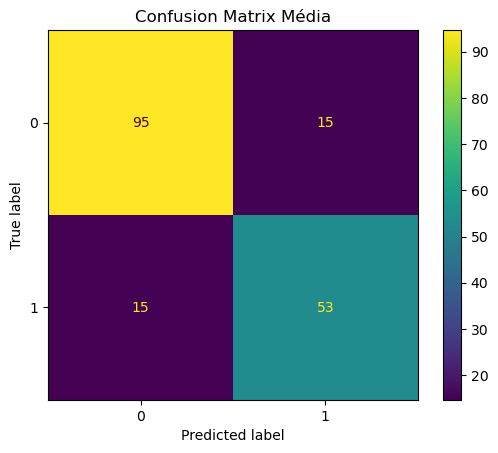

In [ ]:
# Code to obtain the confusion matrix of the optimized Random Forest model


cms_valid = []

for train_idx, valid_idx in rskf.split(X_dev, y_dev):

    X_train_fold = X_dev.iloc[train_idx]
    X_valid_fold = X_dev.iloc[valid_idx]
    y_train_fold = y_dev.iloc[train_idx]
    y_valid_fold = y_dev.iloc[valid_idx]


    # train
    final_model_rf.fit(X_train_fold, y_train_fold)


    # prediction
    y_valid_prob = final_model_rf.predict_proba(X_valid_fold)[:, 1]
    y_valid_pred = (y_valid_prob >= best_threshold).astype(int)


    # store confusion matrix
    cms_valid.append(confusion_matrix(y_valid_fold, y_valid_pred))


# average
mean_cm = np.mean(cms_valid, axis=0)

print("\n=== Confusion Matrix média ===")
print(np.round(mean_cm, 1))

disp = ConfusionMatrixDisplay(confusion_matrix=mean_cm)
disp.plot(values_format=".0f")
plt.title("Confusion Matrix Média")
plt.show()

### Comparison of Models BEFORE vs AFTER Optimization

                    Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
0              SVM Before    0.8045     0.7931  0.6667    0.7244   0.8375
1  SVM after optimization    0.8124     0.7594  0.7512    0.7537   0.8527


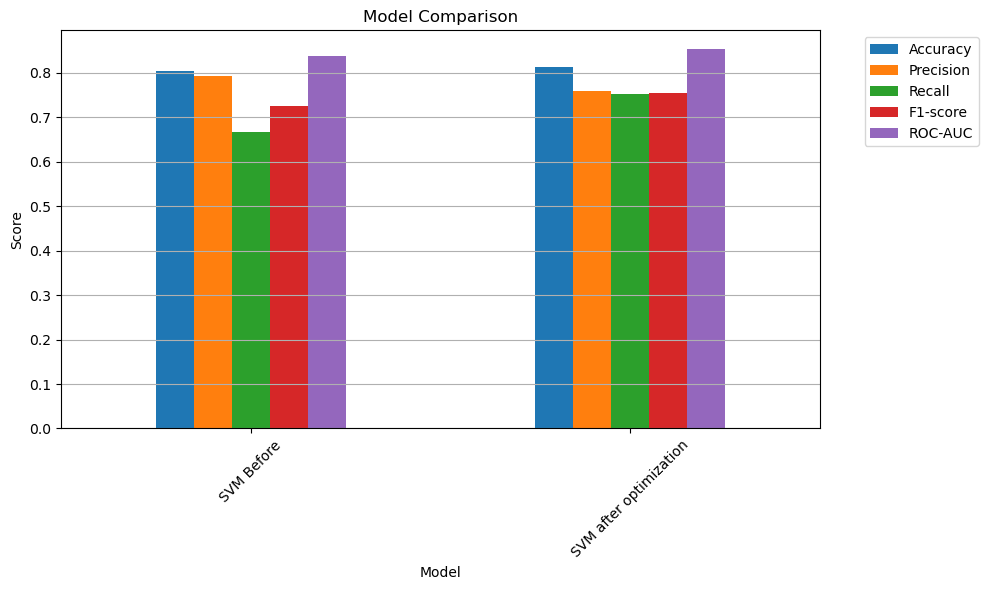

In [ ]:
#Before and after - SVM Model


results = pd.DataFrame({
    "Model": ["SVM Before", "SVM after optimization"],
    "Accuracy": [0.8045, 0.8124],
    "Precision": [0.7931, 0.7594],
    "Recall": [0.6667, 0.7512],
    "F1-score": [0.7244, 0.7537],
    "ROC-AUC": [0.8375, 0.8527]
})


# display table
print(results)


# plot
ax = results.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(axis="y")


# Legend outside the table on the right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


#  Adjust layout to avoid clipping
plt.tight_layout()

plt.show()

>The comparison between the SVM model before and after optimization shows an overall improvement in performance, particularly in terms of recall, F1-score, and ROC-AUC, indicating a better ability to correctly identify survivors and a more balanced model, despite a slight decrease in precision.

                              Model  Accuracy  Precision  Recall  F1-score  \
0              Random Forest Before    0.8156     0.8000  0.6957    0.7442   
1  Random Forest after optimization    0.8322     0.7814  0.7838    0.7811   

   ROC-AUC  
0   0.8372  
1   0.8720  


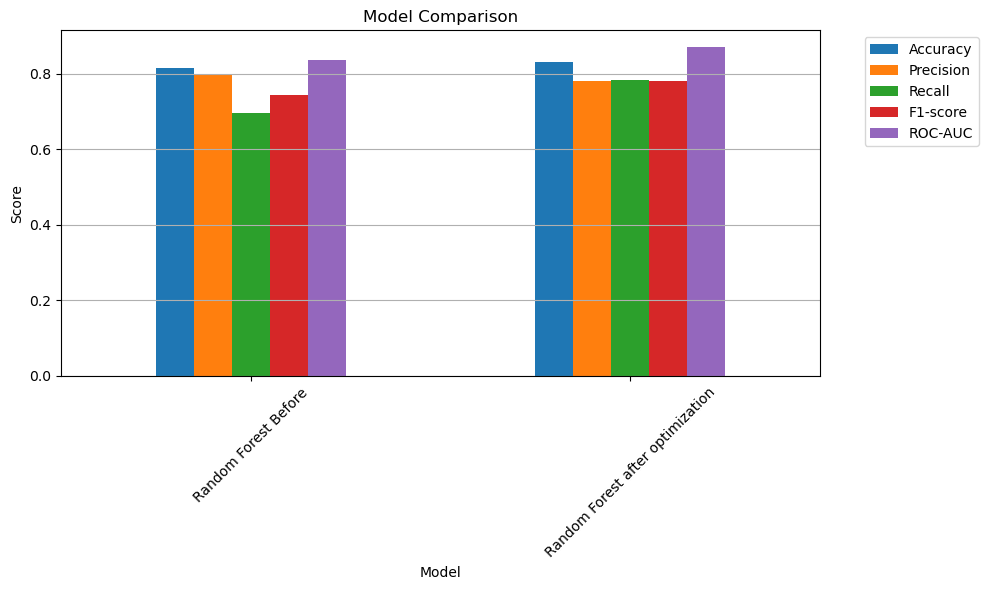

In [ ]:
#Before and after - Random Forest model

results = pd.DataFrame({
    "Model": ["Random Forest Before", "Random Forest after optimization"],
    "Accuracy": [0.8156, 0.8322],
    "Precision": [0.8000, 0.7814],
    "Recall": [0.6957, 0.7838],
    "F1-score": [0.7442, 0.7811],
    "ROC-AUC": [0.8372, 0.8720]
})


# display table
print(results)


# plot
ax = results.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(axis="y")


# Legend outside the table on the right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


# Adjust layout to prevent clipping
plt.tight_layout()

plt.show()

>The comparison of the Random Forest model before and after optimization shows an overall improvement in performance, particularly in the increase of recall, F1-score, and ROC-AUC, indicating a better ability to identify survivors. Despite a slight reduction in precision, the model becomes more balanced and demonstrates improved overall performance after optimization.

<Figure size 500x400 with 0 Axes>

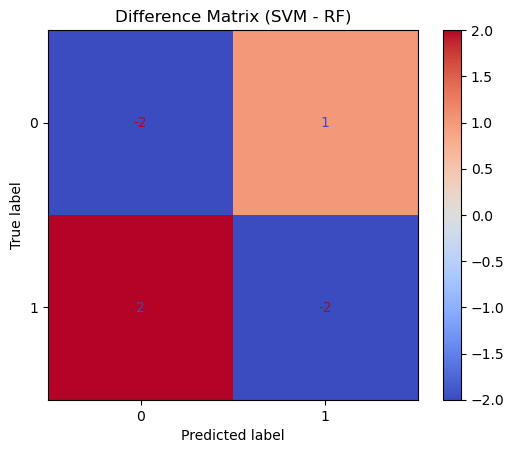

In [ ]:
# # Direct comparison between the most optimized models (SVM vs Random Forest)


# 1. Manually define the matrices

cm_svm = np.array([[93, 16],
                  [17, 51]])

cm_rf = np.array([[95, 15],
                   [15, 53]]) 


# 2. Difference

cm_diff = cm_svm - cm_rf


# 3. Plot

plt.figure(figsize=(5,4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_diff)
disp.plot(cmap="coolwarm")

plt.title("Difference Matrix (SVM - RF)")
plt.show()

>The difference matrix indicates that the SVM correctly identified 2 fewer positive cases and 2 fewer negative cases compared to the Random Forest, while showing a higher number of misclassifications (false positives and false negatives). This suggests that the Random Forest model has a better predictive capability in classifying Titanic survivors and non-survivors.

           Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
0  Random Forest    0.8322     0.7814  0.7838    0.7811   0.8720
1            SVM    0.8124     0.7594  0.7512    0.7537   0.8527


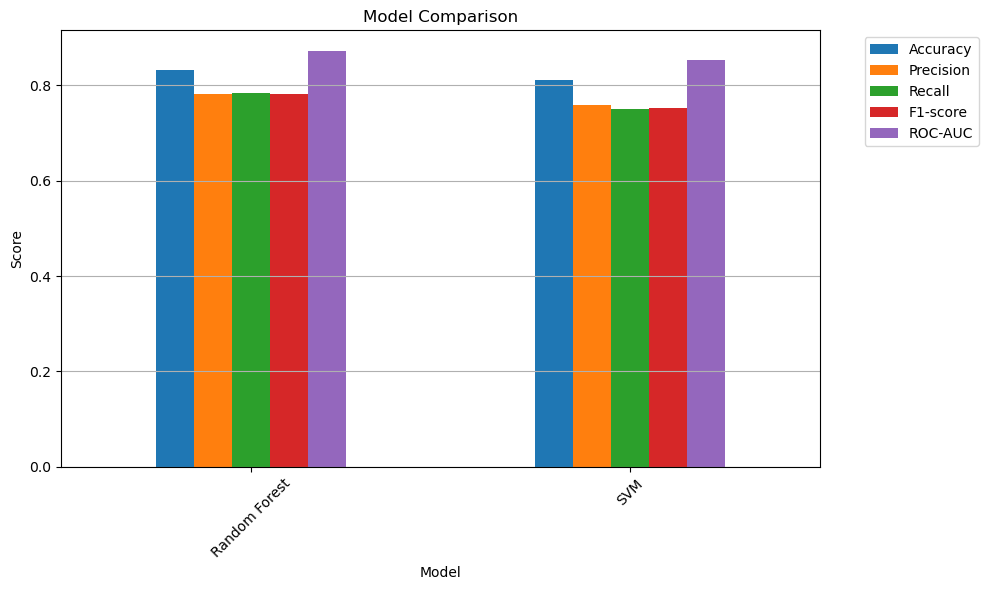

In [ ]:
# Comparison between the two most optimized models


results = pd.DataFrame({
    "Model": ["Random Forest", "SVM"],
    "Accuracy": [0.8322, 0.8124],
    "Precision": [0.7814, 0.7594],
    "Recall": [0.7838, 0.7512],
    "F1-score": [0.7811, 0.7537],
    "ROC-AUC": [0.8720, 0.8527]
}) 


# Display table
print(results)


# Plot
ax = results.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(axis="y")


# Legend outside the table on the right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


# Adjust layout to avoid clipping
plt.tight_layout()

plt.show()

>This visualization reinforces the conclusion reached earlier. The comparison between the models shows that the Random Forest achieves better overall performance compared to the SVM, standing out across all metrics, namely accuracy, precision, recall, F1-score, and ROC-AUC, demonstrating a greater predictive capability in classifying passengers.

X_processed_df shape: (889, 10)
SHAP shape: (889, 10, 2)


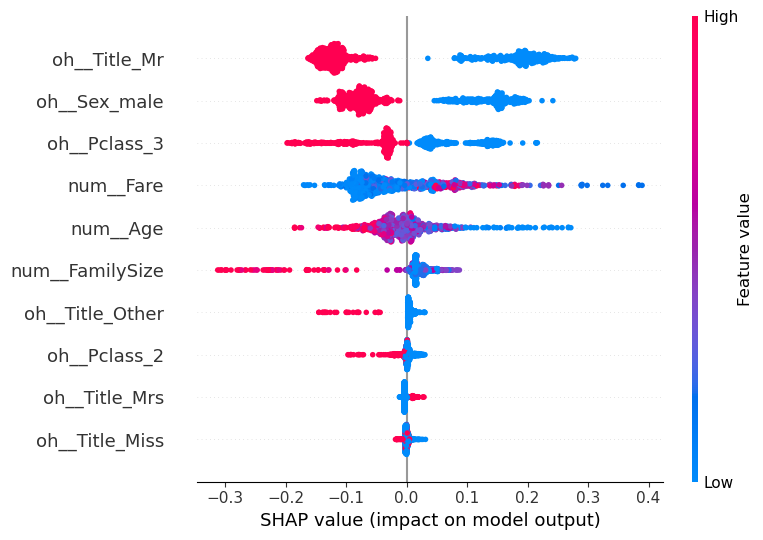

In [ ]:
#Code to analyze feature importance in the model and understand how the model makes decisions



# 1. Train the final model on the full dev set

final_model_rf.fit(X_dev, y_dev)


# 2. Apply the pipeline preprocessing to the data

X_processed = final_model_rf.named_steps["prep"].transform(X_dev)


# 3. If in sparse format, convert to array

if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()


# 4. Get feature names after preprocessing

feature_names = final_model_rf.named_steps["prep"].get_feature_names_out()


# 5. Create DataFrame with transformed features

X_processed_df = pd.DataFrame(X_processed, columns=feature_names, index=X_dev.index)


# 6. Extract only the final Random Forest model

rf_model = final_model_rf.named_steps["model"]


# 7. Create SHAP explainer

explainer = shap.TreeExplainer(rf_model)


# 8. Compute SHAP values

shap_values = explainer.shap_values(X_processed_df)


# 9. Check shapes to understand the format

sv = np.array(shap_values)

print("X_processed_df shape:", X_processed_df.shape)
print("SHAP shape:", sv.shape)


# 10. Plot depending on the format returned by SHAP

if sv.ndim == 3:
    # Case: (n_samples, n_features, n_classes)
    if sv.shape[0] == X_processed_df.shape[0] and sv.shape[1] == X_processed_df.shape[1]:
        shap.summary_plot(sv[:, :, 1], X_processed_df)

    # Case: (n_classes, n_samples, n_features)
    elif sv.shape[1] == X_processed_df.shape[0] and sv.shape[2] == X_processed_df.shape[1]:
        shap.summary_plot(sv[1], X_processed_df)

    else:
        print("Formato 3D não reconhecido:", sv.shape)

elif sv.ndim == 2:
    # Case: (n_samples, n_features)
    if sv.shape[0] == X_processed_df.shape[0] and sv.shape[1] == X_processed_df.shape[1]:
        shap.summary_plot(sv, X_processed_df)
    else:
        print("Formato 2D não compatível:", sv.shape)

else:
    print("Formato inesperado:", sv.shape)

>The SHAP value analysis of the optimized Random Forest model shows that the most influential variables are Title_Mr, Sex_male, and Pclass_3, which are associated with a decrease in the probability of survival. On the other hand, Fare has a positive impact, indicating that passengers who purchased more expensive tickets had a higher likelihood of survival. The Age variable exhibits a moderate effect, with higher ages contributing negatively. In addition, FamilySize suggests that larger families tend to have lower survival rates. Variables such as Title_Mrs and Title_Miss have a positive impact, reflecting the higher survival probability of women. Overall, the model captures relevant patterns that are consistent with the Titanic context.

# PART D - Regression Task - Age Prediction 

## 1. Data Preparation

>Data preparation for <b>age prediction</b>, including <b>feature selection</b> and the <b>training and validation split</b>.
</p>

In [ ]:
# Split dataset into passengers with known and unknown age + Train and Test

mlflow.autolog(disable=True)


# 1. Separate data with and without Age

df_age = train_df[train_df["Age"].notnull()].copy()
missing_age = train_df[train_df["Age"].isnull()].copy()


# 2. Define X and y (only with known Age)

X = df_age.drop("Age", axis=1)
y = df_age["Age"]


# 3. Split into training and validatio

X_train_full, X_valid_full, y_train, y_valid = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=0
)


# 4. REMOVE NULLS IN EMBARKED

# train
X_train_full = X_train_full.dropna(subset=["Embarked"])
y_train = y_train.loc[X_train_full.index]
 
# validation
X_valid_full = X_valid_full.dropna(subset=["Embarked"])
y_valid = y_valid.loc[X_valid_full.index]
 

Fare            0.339476
Title           0.256336
Pclass          0.148404
FamilySize      0.129756
Embarked        0.042672
IsAlone         0.026647
HasCabin        0.023618
Sex             0.020663
FareCategory    0.012427
dtype: float64


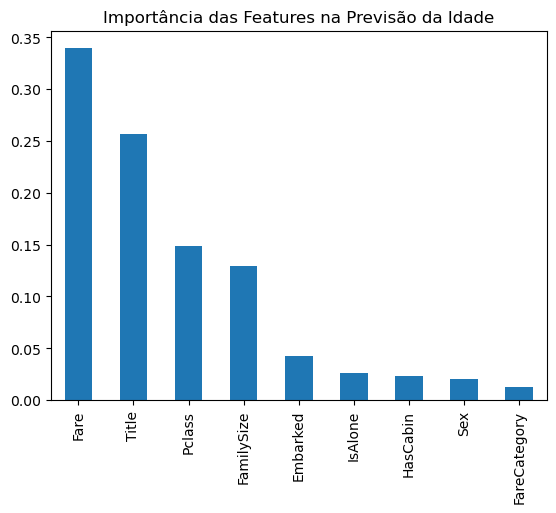

In [ ]:
# Modeling and Feature Importance Analysis for Age Prediction


# 1. Initial feature selection

features = ["Pclass", "Sex", "Title", "Fare", "FareCategory", "FamilySize", "IsAlone", "HasCabin", "Embarked"]

df_age_model = train_df[features + ["Age"]].copy() # Select relevant features and the target (Age) to build the model dataset


# 2. Define column groups
numeric_cols = ["Fare", "FamilySize"]
ordinal_cols = ["FareCategory"]
onehot_cols = ["Title", "Sex", "Pclass", "HasCabin", "Embarked", "IsAlone"]


# 3. Pipelines

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=[
            ["Free", "Low", "Medium", "High", "Very High", "Very Extremely High"]
        ],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("ord", ordinal_pipeline, ordinal_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 4. Separate X and y

X = df_age_model.drop(columns=["Age"])
y = df_age_model["Age"]


# 5. Remove rows without Age

mask = y.notna()
X = X[mask]
y = y[mask]


# 6. Final Pipeline

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])


# 7. Train

model_pipeline.fit(X, y)


# 8. Detailed feature importances

feature_names = model_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = model_pipeline.named_steps["model"].feature_importances_

importance_series = pd.Series(importances, index=feature_names)


# 9. Map each transformed column to the original variable

aggregated_importances = {}

for feature, importance in importance_series.items():
    if feature.startswith("num__"):
        original_name = feature.replace("num__", "")
    elif feature.startswith("ord__"):
        original_name = feature.replace("ord__", "")
    elif feature.startswith("oh__"):
        transformed_name = feature.replace("oh__", "")
        
        if transformed_name.startswith("Title_"):
            original_name = "Title"
        elif transformed_name.startswith("Sex_"):
            original_name = "Sex"
        elif transformed_name.startswith("Pclass_"):
            original_name = "Pclass"
        elif transformed_name.startswith("HasCabin_"):
            original_name = "HasCabin"
        elif transformed_name.startswith("Embarked_"):
            original_name = "Embarked"
        elif transformed_name.startswith("IsAlone_"):
            original_name = "IsAlone"
        else:
            original_name = transformed_name
    else:
        original_name = feature

    aggregated_importances[original_name] = aggregated_importances.get(original_name, 0) + importance


# 10. Final Results

aggregated_importance_series = pd.Series(aggregated_importances).sort_values(ascending=False)

print(aggregated_importance_series)

aggregated_importance_series.plot(kind="bar", title="Importância das Features na Previsão da Idade")
plt.show()

> The variable Fare is the most relevant in predicting age, followed by Title, Pclass, and FamilySize, suggesting that passengers’ socioeconomic status is a strong predictor of their age. On the other hand, variables such as Sex, HasCabin, and FareCategory show a reduced impact, indicating lower explanatory power.

## 2. Baseline Model & 3. Model Iteration

>In this section, different <b>machine learning</b> models are presented for the <b>prediction of passengers’ age</b>. <b>Linear Regression</b> was used as a <b>baseline</b> model, serving as an initial point of reference. Subsequently, additional models were implemented, namely <b>Ridge Regression</b>, <b>Decision Tree</b>, and <b>Random Forest</b>, enabling a comparison between different approaches. All models were evaluated based on <b>consistent metrics</b>, ensuring a structured and comparable analysis of their predictive performance.
</p>


=== Detailed Linear Regression Summary ===
Mean Absolute Error (MAE): 8.8529
Mean Squared Error (MSE): 126.1335
Root Mean Squared Error (RMSE): 11.2309
R² Score: 0.3940


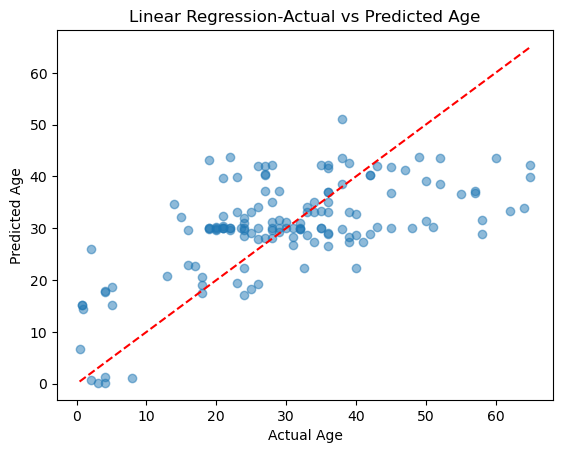

In [ ]:
#Linear Regression


# 1. Create Fare_log
           
X_train_full = X_train_full.copy()
X_valid_full = X_valid_full.copy()

X_train_full["Fare_log"] = np.log1p(X_train_full["Fare"])
X_valid_full["Fare_log"] = np.log1p(X_valid_full["Fare"])


# 2. Define features

selected_features = ["Title", "Fare_log", "FamilySize", "Pclass"]

X_train_sel = X_train_full[selected_features].copy()
X_val_sel = X_valid_full[selected_features].copy()

y_train_aligned = y_train.loc[X_train_sel.index]
y_val_aligned = y_valid.loc[X_val_sel.index]


# 3. Define column types

numeric_cols = ["Fare_log", "FamilySize"]
onehot_cols = ["Title", "Pclass"]


# 4. Pipelines by variable type

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 5. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 6. Final Pipeline with Linear Regression

model_lr = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])


# 7. Train model

model_lr.fit(X_train_sel, y_train_aligned)


# 8. Predictions

y_pred_lr = model_lr.predict(X_val_sel)


# 9. Metrics

mae = mean_absolute_error(y_val_aligned, y_pred_lr)
mse = mean_squared_error(y_val_aligned, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_val_aligned, y_pred_lr)

print("\n=== Detailed Linear Regression Summary ===")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


# 10. Predicted vs actual values

plt.scatter(y_val_aligned, y_pred_lr, alpha=0.5)
plt.plot(
    [y_val_aligned.min(), y_val_aligned.max()],
    [y_val_aligned.min(), y_val_aligned.max()],
    'r--'
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Linear Regression-Actual vs Predicted Age")
plt.show()

>The <i>random_state</i> parameter was not defined in the LinearRegression model, as it is a deterministic algorithm that always produces the same results for the same data and parameters. Therefore, its use would not have any impact on the reproducibility of the results.


=== Ridge Regression Summary ===
MAE  : 8.8064
MSE  : 126.5011
RMSE : 11.2473
R²   : 0.3922


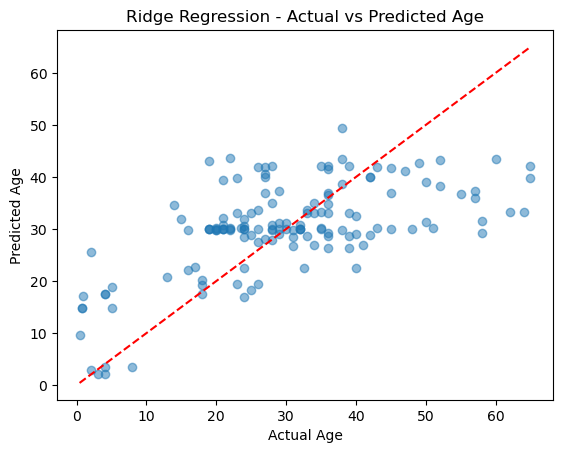

In [ ]:
# Ridge Regression


# 1. Create Fare_log
               
X_train_full = X_train_full.copy()
X_valid_full = X_valid_full.copy()

X_train_full["Fare_log"] = np.log1p(X_train_full["Fare"])
X_valid_full["Fare_log"] = np.log1p(X_valid_full["Fare"])


# 2. Define features

selected_features = ["Title", "Fare_log", "FamilySize", "Pclass"]

X_train_sel = X_train_full[selected_features].copy()
X_val_sel = X_valid_full[selected_features].copy()

y_train_aligned = y_train.loc[X_train_sel.index]
y_val_aligned = y_valid.loc[X_val_sel.index]


# 3. Define column types

numeric_cols = ["Fare_log", "FamilySize"]
onehot_cols = ["Title", "Pclass"]


# 4. Pipelines by variable type

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 5. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 6. Final Pipeline with Ridge Regression

model_ridge = Pipeline([
    ("prep", preprocessor),
    ("model", Ridge(
        alpha=1.0,          # initial regularization value to control overfitting
    ))
])


# 7. Train modelo

model_ridge.fit(X_train_sel, y_train_aligned)


# 8. Predictions

y_pred_ridge = model_ridge.predict(X_val_sel)


# 9. Metrics

mae = mean_absolute_error(y_val_aligned, y_pred_ridge)
mse = mean_squared_error(y_val_aligned, y_pred_ridge)
rmse = np.sqrt(mse)
r2 = r2_score(y_val_aligned, y_pred_ridge)

print("\n=== Ridge Regression Summary ===")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


# 10. Predicted vs actual values

plt.scatter(y_val_aligned, y_pred_ridge, alpha=0.5)
plt.plot(
    [y_val_aligned.min(), y_val_aligned.max()],
    [y_val_aligned.min(), y_val_aligned.max()],
    'r--'
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Ridge Regression - Actual vs Predicted Age")
plt.show()

>The model uses regularization with alpha=1.0 to control overfitting and improve the stability of the predictions. The random_state parameter was not used, as Ridge Regression is a deterministic model and does not depend on randomness.


=== Decision Tree Regression Summary ===
MAE  : 10.9549
MSE  : 207.2175
RMSE : 14.3951
R²   : 0.0044


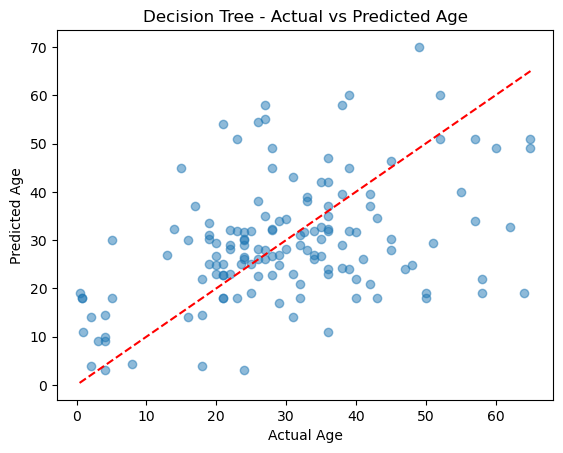

In [ ]:
#Decision Tree


# 1. Define features

selected_features = ["Title", "Fare", "FamilySize", "Pclass"]

X_train_sel = X_train_full[selected_features].copy()
X_val_sel = X_valid_full[selected_features].copy()

y_train_aligned = y_train.loc[X_train_sel.index]
y_val_aligned = y_valid.loc[X_val_sel.index]


# 2. Define columns types

numeric_cols = ["Fare", "FamilySize"]
onehot_cols = ["Title", "Pclass"]


# 3. Pipelines by variable type

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 4. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 5. Final Pipeline with Decision Tree Regressor

model_dt = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeRegressor(
        random_state=0,
    ))
])


# 6. Train model

model_dt.fit(X_train_sel, y_train_aligned)


# 7. Predictions

y_pred_dt = model_dt.predict(X_val_sel)


# 8. Metrics

mae = mean_absolute_error(y_val_aligned, y_pred_dt)
mse = mean_squared_error(y_val_aligned, y_pred_dt)
rmse = np.sqrt(mse)
r2 = r2_score(y_val_aligned, y_pred_dt)

print("\n=== Decision Tree Regression Summary ===")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


# 9. Predicted vs actual values

plt.scatter(y_val_aligned, y_pred_dt, alpha=0.5)
plt.plot(
    [y_val_aligned.min(), y_val_aligned.max()],
    [y_val_aligned.min(), y_val_aligned.max()],
    'r--'
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Decision Tree - Actual vs Predicted Age")
plt.show()


=== Random Forest Regression Summary ===
MAE  : 9.3646
MSE  : 153.6222
RMSE : 12.3944
R²   : 0.2619


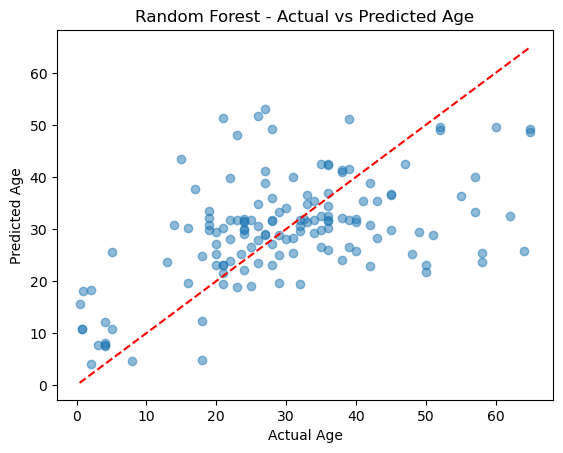

In [ ]:
#Random Forest Regressor


# 1. Define features

selected_features = ["Title", "Fare", "FamilySize", "Pclass"]

X_train_sel = X_train_full[selected_features].copy()
X_val_sel = X_valid_full[selected_features].copy()

y_train_aligned = y_train.loc[X_train_sel.index]
y_val_aligned = y_valid.loc[X_val_sel.index]


# 2. Define column types

numeric_cols = ["Fare", "FamilySize"]
onehot_cols = ["Title", "Pclass"]


# 3. Pipelines by variable type

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 4. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 5. Final Pipeline with Random Forest Regressor

model_rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=0    
    ))
])


# 6. Train model

model_rf.fit(X_train_sel, y_train_aligned)


# 7. Predictions

y_pred_rf = model_rf.predict(X_val_sel)


# 8. Metrics

mae = mean_absolute_error(y_val_aligned, y_pred_rf)
mse = mean_squared_error(y_val_aligned, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_val_aligned, y_pred_rf)

print("\n=== Random Forest Regression Summary ===")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


# 9. Predicted vs actual values

plt.scatter(y_val_aligned, y_pred_rf, alpha=0.5)
plt.plot(
    [y_val_aligned.min(), y_val_aligned.max()],
    [y_val_aligned.min(), y_val_aligned.max()],
    'r--'
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Random Forest - Actual vs Predicted Age")
plt.show()

In [ ]:
# Comparative table of model metrics


# Create table with results
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Decision Tree", "Random Forest"],
    "MAE": [8.8529, 8.8064, 10.9549, 9.3646],
    "MSE": [126.1335, 126.5011, 207.2175, 153.6222],
    "RMSE": [11.2309, 11.2473, 14.3951, 12.3944],
    "R2": [0.3940, 0.3922, 0.0044, 0.2619]
})

# Set model as Index
results.set_index("Model", inplace=True)

# Display table
print("\n=== Model Performance Table ===")
print(results)


=== Model Performance Table ===
                   MAE       MSE     RMSE      R2
Model                                            
Linear          8.8529  126.1335  11.2309  0.3940
Ridge           8.8064  126.5011  11.2473  0.3922
Decision Tree  10.9549  207.2175  14.3951  0.0044
Random Forest   9.3646  153.6222  12.3944  0.2619



=== Final Model Ranking ===
Model
Ridge            0.996416
Linear           0.994589
Random Forest    0.673601
Decision Tree    0.000000
Name: Final Score, dtype: float64


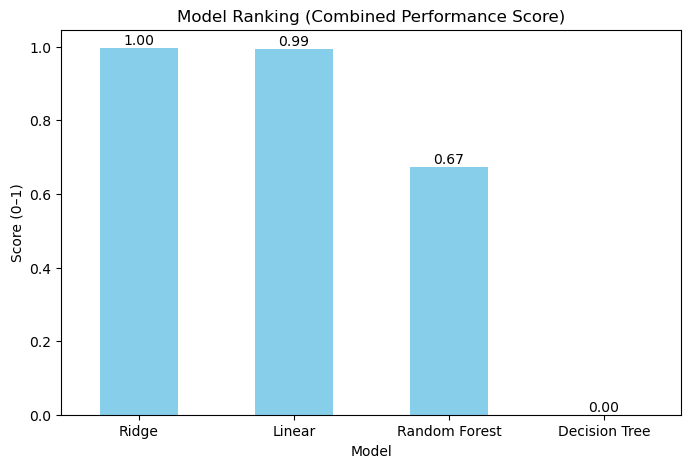

In [ ]:
# Overall model ranking


# Original table
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Decision Tree", "Random Forest"],
    "MAE": [8.8529, 8.8064, 10.9549, 9.3646],
    "MSE": [126.1335, 126.5011, 207.2175, 153.6222],
    "RMSE": [11.2309, 11.2473, 14.3951, 12.3944],
    "R2": [0.3940, 0.3922, 0.0044, 0.2619]
})

results.set_index("Model", inplace=True)


# 1.  Normalize metrics

norm = results.copy()


# Errors (lower is better)
for col in ["MAE", "MSE", "RMSE"]:
    norm[col] = (results[col].max() - results[col]) / (results[col].max() - results[col].min())


# R² (higher is better)
norm["R2"] = (results["R2"] - results["R2"].min()) / (results["R2"].max() - results["R2"].min())


# 2. Final score (average)

norm["Final Score"] = norm.mean(axis=1)


# Sort
norm = norm.sort_values(by="Final Score", ascending=False)

print("\n=== Final Model Ranking ===")
print(norm["Final Score"])


# 3. Final plot

plt.figure(figsize=(8,5))

norm["Final Score"].plot(kind="bar", color="skyblue")

plt.title("Model Ranking (Combined Performance Score)")
plt.ylabel("Score (0–1)")
plt.xticks(rotation=0)


#  Display values on bars
for i, v in enumerate(norm["Final Score"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

>The final ranking indicates that Ridge Regression was the best-performing model, closely followed by Linear Regression, suggesting a predominantly linear relationship between the variables. Tree-based models showed inferior results, particularly the Decision Tree, which demonstrated lower predictive capability.
</p>

## 4. Model Optimization

In [76]:
svm_cols = ["Fare_log","Title", 'IsAlone', "Embarked", "FamilySize" ,"Pclass", "HasCabin"]

X_train_full["Fare_log"] = np.log1p(X_train_full["Fare"]) 
X_valid_full["Fare_log"] = np.log1p(X_valid_full["Fare"])
 
X_train_rr = X_train_full[svm_cols].copy()
X_val_rr = X_valid_full[svm_cols].copy()

In [ ]:
#Feature selection - Ridge Regression


# 1. Candidate Features

candidate_features = ["Fare_log","Title", 'IsAlone', "Embarked", "FamilySize" ,"Pclass", "HasCabin"]

candidate_features = [c for c in candidate_features if c in X_train_rr]


# 2. Preprocessor

def build_preprocessor(selected_features):
    num_cols = [c for c in selected_features if c in ["Fare_log", "FamilySize"]]
    onehot_cols = [c for c in selected_features if c in ["Title", 'IsAlone', "Embarked","Pclass", "HasCabin"]]

    transformers = []

    if num_cols:
        transformers.append(
            ("num", StandardScaler(), num_cols)
        )

    if onehot_cols:
        transformers.append(
            ("oh", OneHotEncoder(handle_unknown="ignore", drop="first"), onehot_cols)
        )

    return ColumnTransformer(transformers)


# 3. Cross-validation

cv = KFold(n_splits=5, shuffle=True, random_state=0)

selected_features = []
remaining_features = candidate_features.copy()
results_forward = []

best_rmse_so_far = np.inf


# 4. Forward Selection with Ridge

while remaining_features:
    scores_this_round = []

    for feature in remaining_features:
        current_features = selected_features + [feature]

        preprocessor = build_preprocessor(current_features)

        pipe = Pipeline([
            ("prep", preprocessor),
            ("model", Ridge(alpha=1.0))  # podes ajustar depois
        ])

        rmse_cv = -cross_val_score(
            pipe,
            X_train_rr[current_features],
            y_train,
            cv=cv,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1
        ).mean()

        scores_this_round.append((feature, rmse_cv, current_features))

    best_feature, best_rmse, best_set = min(scores_this_round, key=lambda x: x[1])

    results_forward.append({
        "Step": len(selected_features) + 1,
        "Added_Feature": best_feature,
        "Selected_Features": best_set.copy(),
        "CV_RMSE": best_rmse
    })

    if best_rmse < best_rmse_so_far:
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        best_rmse_so_far = best_rmse
    else:
        break


# 5. Results

results_forward_df = pd.DataFrame(results_forward)

print(results_forward_df)
print("\nFeatures finais selecionadas:", selected_features)
print("Melhor CV RMSE:", round(best_rmse_so_far, 4))

   Step Added_Feature                                  Selected_Features  \
0     1         Title                                            [Title]   
1     2        Pclass                                    [Title, Pclass]   
2     3       IsAlone                           [Title, Pclass, IsAlone]   
3     4      Embarked                 [Title, Pclass, IsAlone, Embarked]   
4     5      HasCabin       [Title, Pclass, IsAlone, Embarked, HasCabin]   
5     6      Fare_log  [Title, Pclass, IsAlone, Embarked, HasCabin, F...   

     CV_RMSE  
0  12.423137  
1  11.570050  
2  11.345022  
3  11.335777  
4  11.327713  
5  11.341552  

Features finais selecionadas: ['Title', 'Pclass', 'IsAlone', 'Embarked', 'HasCabin']
Melhor CV RMSE: 11.3277


Fitting 5 folds for each of 7 candidates, totalling 35 fits
=== Ridge - Best Params ===
{'model__alpha': 0.01}
Best CV RMSE: 11.3001

=== Ridge - Validation Metrics ===
MAE  : 8.6300
MSE  : 121.3958
RMSE : 11.0180
R²   : 0.4168


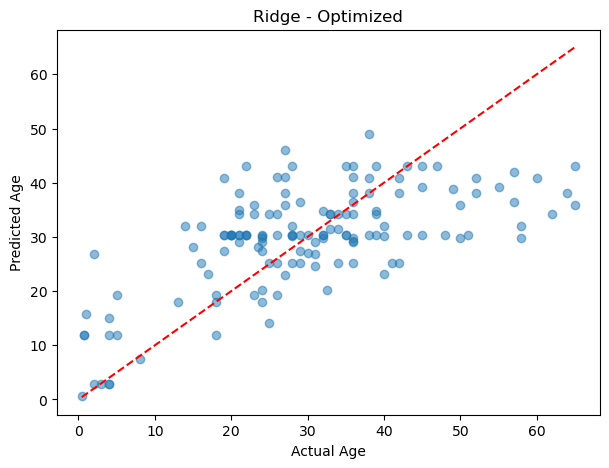


=== Top parameter combinations ===
                    params    RMSE_CV  rank_test_score
1   {'model__alpha': 0.01}  11.300149                1
0  {'model__alpha': 0.001}  11.300160                2
2    {'model__alpha': 0.1}  11.300397                3
3      {'model__alpha': 1}  11.327713                4
4     {'model__alpha': 10}  11.770067                5
5    {'model__alpha': 100}  12.813909                6
6   {'model__alpha': 1000}  14.103717                7


In [ ]:
# Optimization / Evaluation of Ridge Regression - selected_features = ["Title","IsAlone","Pclass","Embarked","HasCabin"]


# 1. Preprocessing - Ridge

selected_features = ["Title","IsAlone","Pclass","Embarked","HasCabin"]

def build_preprocessor_ridge(selected_features):
    onehot_cols = [c for c in selected_features if c in ["Title", "IsAlone","Pclass","Embarked","HasCabin"]]

    transformers = []

    if onehot_cols:
        transformers.append((
            "oh",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            onehot_cols
        ))

    return ColumnTransformer(transformers)


# 2. Final Ridge Features

selected_features_ridge = ["Title", "IsAlone","Pclass","Embarked","HasCabin"]

# ensure that only existing columns are used
selected_features_ridge = [c for c in selected_features_ridge if c in X_train_rr.columns]

X_train_ridge_sel = X_train_rr[selected_features_ridge].copy()
X_valid_ridge_sel = X_val_rr[selected_features_ridge].copy()

y_train_ridge = y_train.loc[X_train_ridge_sel.index]
y_valid_ridge = y_valid.loc[X_valid_ridge_sel.index]

preprocessor_ridge = build_preprocessor_ridge(selected_features_ridge)

baseline_ridge = Pipeline([
    ("prep", preprocessor_ridge),
    ("model", Ridge())
])


# 3. Cross-validation

cv = KFold(n_splits=5, shuffle=True, random_state=0)


# 4. GridSearchCV

param_grid_ridge = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

grid_ridge = GridSearchCV(
    estimator=baseline_ridge,
    param_grid=param_grid_ridge,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_ridge.fit(X_train_ridge_sel, y_train_ridge)

print("=== Ridge - Best Params ===")
print(grid_ridge.best_params_)
print(f"Best CV RMSE: {-grid_ridge.best_score_:.4f}")

best_ridge = grid_ridge.best_estimator_


# 5. Evaluation on the validation set

y_pred_ridge = best_ridge.predict(X_valid_ridge_sel)

mae_ridge = mean_absolute_error(y_valid_ridge, y_pred_ridge)
mse_ridge = mean_squared_error(y_valid_ridge, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_valid_ridge, y_pred_ridge)

print("\n=== Ridge - Validation Metrics ===")
print(f"MAE  : {mae_ridge:.4f}")
print(f"MSE  : {mse_ridge:.4f}")
print(f"RMSE : {rmse_ridge:.4f}")
print(f"R²   : {r2_ridge:.4f}")


# 6. Predicted vs Actual

plt.figure(figsize=(7, 5))
plt.scatter(y_valid_ridge, y_pred_ridge, alpha=0.5)
plt.plot(
    [y_valid_ridge.min(), y_valid_ridge.max()],
    [y_valid_ridge.min(), y_valid_ridge.max()],
    "r--"
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Ridge - Optimized")
plt.show()


# 7. Table of tested results

ridge_results = pd.DataFrame(grid_ridge.cv_results_).copy()
ridge_results["RMSE_CV"] = -ridge_results["mean_test_score"]

print("\n=== Top parameter combinations ===")
print(
    ridge_results[["params", "RMSE_CV", "rank_test_score"]]
    .sort_values("rank_test_score")
    .head(10)
)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
=== Ridge - Best Params ===
{'model__alpha': 0.001}
Best CV RMSE: 11.3577

=== Ridge - Validation Metrics ===
MAE  : 8.6451
MSE  : 121.5831
RMSE : 11.0265
R²   : 0.4159


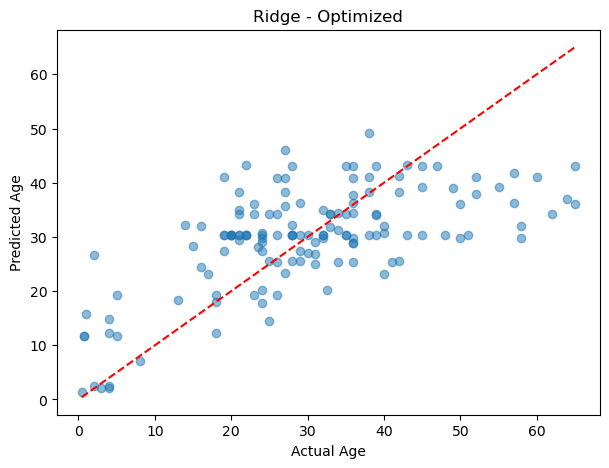


=== Top parameter combinations ===
                    params    RMSE_CV  rank_test_score
0  {'model__alpha': 0.001}  11.357726                1
1   {'model__alpha': 0.01}  11.357763                2
2    {'model__alpha': 0.1}  11.358494                3
3      {'model__alpha': 1}  11.389594                4
4     {'model__alpha': 10}  11.817231                5
5    {'model__alpha': 100}  12.651959                6
6   {'model__alpha': 1000}  13.832848                7


In [ ]:
# Optimization / Evaluation of Ridge Regression - selected_features = ["Title","IsAlone","Pclass","Embarked","HasCabin","FamilySize"]


# 1. Preprocessing - Ridge

selected_features = ["Title","IsAlone","Pclass","Embarked","HasCabin","FamilySize"]

def build_preprocessor_ridge(selected_features):
    num_cols = [c for c in selected_features if c in ["FamilySize"]]
    onehot_cols = [c for c in selected_features if c in ["Title", "IsAlone","Pclass","Embarked","HasCabin"]]

    transformers = []

    if num_cols:
         transformers.append(("num", StandardScaler(), num_cols))

    if onehot_cols:
        transformers.append((
            "oh",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            onehot_cols
        ))

    return ColumnTransformer(transformers)


# 2. Final Ridge Features

selected_features_ridge = ["Title", "IsAlone","Pclass","Embarked","HasCabin","FamilySize"]


# ensure that only existing columns are used
selected_features_ridge = [c for c in selected_features_ridge if c in X_train_rr.columns]

X_train_ridge_sel = X_train_rr[selected_features_ridge].copy()
X_valid_ridge_sel = X_val_rr[selected_features_ridge].copy()

y_train_ridge = y_train.loc[X_train_ridge_sel.index]
y_valid_ridge = y_valid.loc[X_valid_ridge_sel.index]

preprocessor_ridge = build_preprocessor_ridge(selected_features_ridge)

baseline_ridge = Pipeline([
    ("prep", preprocessor_ridge),
    ("model", Ridge())
])


# 3. Cross-validation

cv = KFold(n_splits=5, shuffle=True, random_state=0)


# 4. GridSearchCV

param_grid_ridge = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

grid_ridge = GridSearchCV(
    estimator=baseline_ridge,
    param_grid=param_grid_ridge,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_ridge.fit(X_train_ridge_sel, y_train_ridge)

print("=== Ridge - Best Params ===")
print(grid_ridge.best_params_)
print(f"Best CV RMSE: {-grid_ridge.best_score_:.4f}")

best_ridge = grid_ridge.best_estimator_


# 5.  Evaluation on the validation set

y_pred_ridge = best_ridge.predict(X_valid_ridge_sel)

mae_ridge = mean_absolute_error(y_valid_ridge, y_pred_ridge)
mse_ridge = mean_squared_error(y_valid_ridge, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_valid_ridge, y_pred_ridge)

print("\n=== Ridge - Validation Metrics ===")
print(f"MAE  : {mae_ridge:.4f}")
print(f"MSE  : {mse_ridge:.4f}")
print(f"RMSE : {rmse_ridge:.4f}")
print(f"R²   : {r2_ridge:.4f}")


# 6. Predicted vs Actual

plt.figure(figsize=(7, 5))
plt.scatter(y_valid_ridge, y_pred_ridge, alpha=0.5)
plt.plot(
    [y_valid_ridge.min(), y_valid_ridge.max()],
    [y_valid_ridge.min(), y_valid_ridge.max()],
    "r--"
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Ridge - Optimized")
plt.show()


# 7. Table of tested results

ridge_results = pd.DataFrame(grid_ridge.cv_results_).copy()
ridge_results["RMSE_CV"] = -ridge_results["mean_test_score"]

print("\n=== Top parameter combinations ===")
print(
    ridge_results[["params", "RMSE_CV", "rank_test_score"]]
    .sort_values("rank_test_score")
    .head(10)
)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
=== Ridge - Best Params ===
{'model__alpha': 0.001}
Best CV RMSE: 11.3624

=== Ridge - Validation Metrics ===
MAE  : 8.6757
MSE  : 121.9448
RMSE : 11.0429
R²   : 0.4141


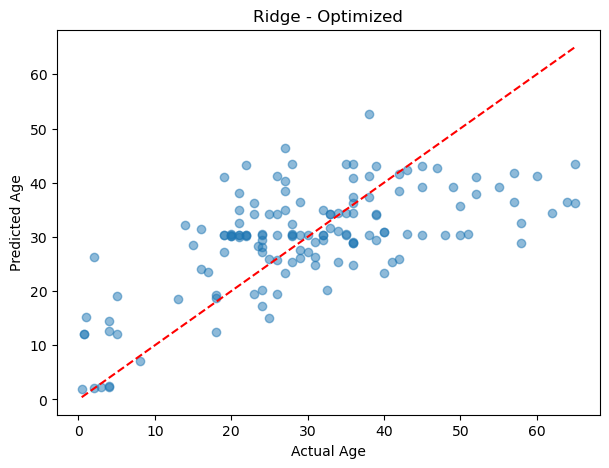


=== Top parameter combinations ===
                    params    RMSE_CV  rank_test_score
0  {'model__alpha': 0.001}  11.362406                1
1   {'model__alpha': 0.01}  11.362434                2
2    {'model__alpha': 0.1}  11.363086                3
3      {'model__alpha': 1}  11.394635                4
4     {'model__alpha': 10}  11.837546                5
5    {'model__alpha': 100}  12.607761                6
6   {'model__alpha': 1000}  13.771048                7


In [ ]:
# Optimization / Evaluation of Ridge Regression - selected_features = ["Title","IsAlone","Pclass","Embarked","HasCabin","FamilySize","Fare_log"]


# 1. Preprocessing - Ridge

selected_features = ["Title","IsAlone","Pclass","Embarked","HasCabin","FamilySize","Fare_log"]

def build_preprocessor_ridge(selected_features):
    num_cols = [c for c in selected_features if c in ["FamilySize","Fare_log"]]
    onehot_cols = [c for c in selected_features if c in ["Title", "IsAlone","Pclass","Embarked","HasCabin"]]

    transformers = []

    if num_cols:
         transformers.append(("num", StandardScaler(), num_cols))

    if onehot_cols:
        transformers.append((
            "oh",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            onehot_cols
        ))

    return ColumnTransformer(transformers)


# 2. Final Ridge Features

selected_features_ridge = ["Title", "IsAlone","Pclass","Embarked","HasCabin","FamilySize","Fare_log"]


# ensure that only existing columns are used
selected_features_ridge = [c for c in selected_features_ridge if c in X_train_rr.columns]

X_train_ridge_sel = X_train_rr[selected_features_ridge].copy()
X_valid_ridge_sel = X_val_rr[selected_features_ridge].copy()

y_train_ridge = y_train.loc[X_train_ridge_sel.index]
y_valid_ridge = y_valid.loc[X_valid_ridge_sel.index]

preprocessor_ridge = build_preprocessor_ridge(selected_features_ridge)

baseline_ridge = Pipeline([
    ("prep", preprocessor_ridge),
    ("model", Ridge())
])


# 3. Cross-validation

cv = KFold(n_splits=5, shuffle=True, random_state=0)


# 4. GridSearchCV

param_grid_ridge = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

grid_ridge = GridSearchCV(
    estimator=baseline_ridge,
    param_grid=param_grid_ridge,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_ridge.fit(X_train_ridge_sel, y_train_ridge)

print("=== Ridge - Best Params ===")
print(grid_ridge.best_params_)
print(f"Best CV RMSE: {-grid_ridge.best_score_:.4f}")

best_ridge = grid_ridge.best_estimator_


# 5. Evaluation on the validation set

y_pred_ridge = best_ridge.predict(X_valid_ridge_sel)

mae_ridge = mean_absolute_error(y_valid_ridge, y_pred_ridge)
mse_ridge = mean_squared_error(y_valid_ridge, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_valid_ridge, y_pred_ridge)

print("\n=== Ridge - Validation Metrics ===")
print(f"MAE  : {mae_ridge:.4f}")
print(f"MSE  : {mse_ridge:.4f}")
print(f"RMSE : {rmse_ridge:.4f}")
print(f"R²   : {r2_ridge:.4f}")


# 6. Predicted vs Actual

plt.figure(figsize=(7, 5))
plt.scatter(y_valid_ridge, y_pred_ridge, alpha=0.5)
plt.plot(
    [y_valid_ridge.min(), y_valid_ridge.max()],
    [y_valid_ridge.min(), y_valid_ridge.max()],
    "r--"
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Ridge - Optimized")
plt.show()


# 7. Table of tested results

ridge_results = pd.DataFrame(grid_ridge.cv_results_).copy()
ridge_results["RMSE_CV"] = -ridge_results["mean_test_score"]

print("\n=== Top parameter combinations ===")
print(
    ridge_results[["params", "RMSE_CV", "rank_test_score"]]
    .sort_values("rank_test_score")
    .head(10)
)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
=== Ridge - Best Params ===
{'model__alpha': 0.01}
Best CV RMSE: 11.3091

=== Ridge - Validation Metrics ===
MAE  : 8.6175
MSE  : 120.2348
RMSE : 10.9652
R²   : 0.4223


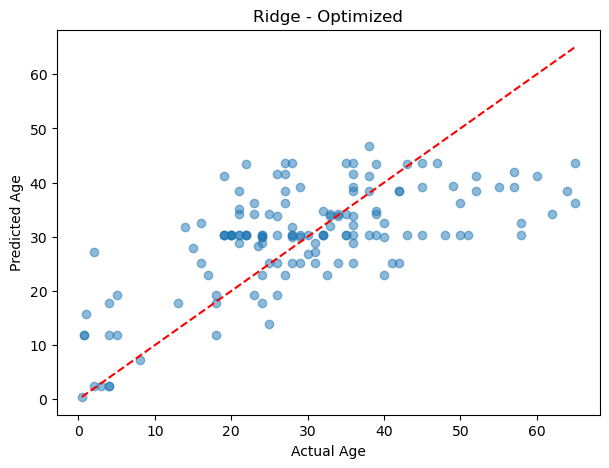


=== Top parameter combinations ===
                    params    RMSE_CV  rank_test_score
1   {'model__alpha': 0.01}  11.309115                1
0  {'model__alpha': 0.001}  11.309122                2
2    {'model__alpha': 0.1}  11.309399                3
3      {'model__alpha': 1}  11.335777                4
4     {'model__alpha': 10}  11.733553                5
5    {'model__alpha': 100}  12.886593                6
6   {'model__alpha': 1000}  14.149684                7


In [ ]:
# Optimization / Evaluation of Ridge Regression - selected_features = ["Title","IsAlone","Pclass","Embarked"]


# 1. Preprocessing - Ridge

selected_features = ["Title","IsAlone","Pclass","Embarked"]

def build_preprocessor_ridge(selected_features):
    onehot_cols = [c for c in selected_features if c in ["Title", "IsAlone","Pclass","Embarked"]]

    transformers = []

    if onehot_cols:
        transformers.append((
            "oh",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            onehot_cols
        ))

    return ColumnTransformer(transformers)


# 2. Final Ridge Features

selected_features_ridge = ["Title", "IsAlone","Pclass","Embarked"]

# ensure that only existing columns are used
selected_features_ridge = [c for c in selected_features_ridge if c in X_train_rr.columns]

X_train_ridge_sel = X_train_rr[selected_features_ridge].copy()
X_valid_ridge_sel = X_val_rr[selected_features_ridge].copy()

y_train_ridge = y_train.loc[X_train_ridge_sel.index]
y_valid_ridge = y_valid.loc[X_valid_ridge_sel.index]

preprocessor_ridge = build_preprocessor_ridge(selected_features_ridge)

baseline_ridge = Pipeline([
    ("prep", preprocessor_ridge),
    ("model", Ridge())
])


# 3. Cross-validation

cv = KFold(n_splits=5, shuffle=True, random_state=0)


# 4. GridSearchCV

param_grid_ridge = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

grid_ridge = GridSearchCV(
    estimator=baseline_ridge,
    param_grid=param_grid_ridge,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_ridge.fit(X_train_ridge_sel, y_train_ridge)

print("=== Ridge - Best Params ===")
print(grid_ridge.best_params_)
print(f"Best CV RMSE: {-grid_ridge.best_score_:.4f}")

best_ridge = grid_ridge.best_estimator_


# 5. Evaluation on the validation set

y_pred_ridge = best_ridge.predict(X_valid_ridge_sel)

mae_ridge = mean_absolute_error(y_valid_ridge, y_pred_ridge)
mse_ridge = mean_squared_error(y_valid_ridge, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_valid_ridge, y_pred_ridge)

print("\n=== Ridge - Validation Metrics ===")
print(f"MAE  : {mae_ridge:.4f}")
print(f"MSE  : {mse_ridge:.4f}")
print(f"RMSE : {rmse_ridge:.4f}")
print(f"R²   : {r2_ridge:.4f}")


# 6. Predicted vs Actual

plt.figure(figsize=(7, 5))
plt.scatter(y_valid_ridge, y_pred_ridge, alpha=0.5)
plt.plot(
    [y_valid_ridge.min(), y_valid_ridge.max()],
    [y_valid_ridge.min(), y_valid_ridge.max()],
    "r--"
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Ridge - Optimized")
plt.show()


# 7. Table of tested results

ridge_results = pd.DataFrame(grid_ridge.cv_results_).copy()
ridge_results["RMSE_CV"] = -ridge_results["mean_test_score"]

print("\n=== Top parameter combinations ===")
print(
    ridge_results[["params", "RMSE_CV", "rank_test_score"]]
    .sort_values("rank_test_score")
    .head(10)
)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
=== Ridge - Best Params ===
{'model__alpha': 0.001}
Best CV RMSE: 11.3641

=== Ridge - Validation Metrics ===
MAE  : 8.6266
MSE  : 120.3089
RMSE : 10.9685
R²   : 0.4220


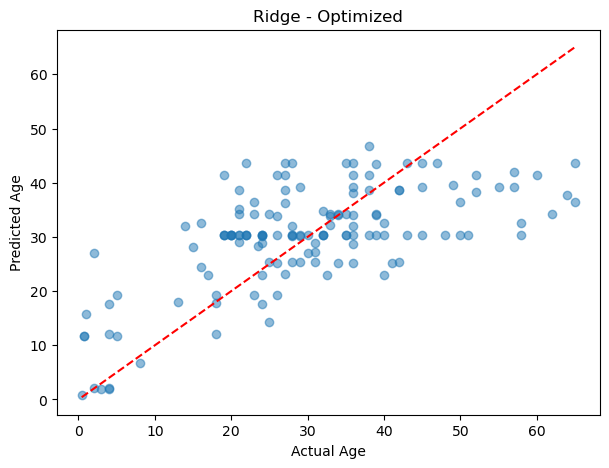


=== Top parameter combinations ===
                    params    RMSE_CV  rank_test_score
0  {'model__alpha': 0.001}  11.364139                1
1   {'model__alpha': 0.01}  11.364188                2
2    {'model__alpha': 0.1}  11.365034                3
3      {'model__alpha': 1}  11.396212                4
4     {'model__alpha': 10}  11.782288                5
5    {'model__alpha': 100}  12.711785                6
6   {'model__alpha': 1000}  13.879530                7


In [ ]:
# Optimization / Evaluation of Ridge Regression - selected_features = ["Title","IsAlone","Pclass","Embarked","FamilySize"]


# 1. Preprocessing - Ridge

selected_features = ["Title","IsAlone","Pclass","Embarked","FamilySize"]

def build_preprocessor_ridge(selected_features):
    num_cols = [c for c in selected_features if c in ["FamilySize"]]
    onehot_cols = [c for c in selected_features if c in ["Title", "IsAlone","Pclass","Embarked"]]

    transformers = []

    if num_cols:
         transformers.append(("num", StandardScaler(), num_cols))

    if onehot_cols:
        transformers.append((
            "oh",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            onehot_cols
        ))

    return ColumnTransformer(transformers)


# 2. Final Ridge Features

selected_features_ridge = ["Title", "IsAlone","Pclass","Embarked","FamilySize"]


# ensure that only existing columns are used
selected_features_ridge = [c for c in selected_features_ridge if c in X_train_rr.columns]

X_train_ridge_sel = X_train_rr[selected_features_ridge].copy()
X_valid_ridge_sel = X_val_rr[selected_features_ridge].copy()

y_train_ridge = y_train.loc[X_train_ridge_sel.index]
y_valid_ridge = y_valid.loc[X_valid_ridge_sel.index]

preprocessor_ridge = build_preprocessor_ridge(selected_features_ridge)

baseline_ridge = Pipeline([
    ("prep", preprocessor_ridge),
    ("model", Ridge())
])


# 3. Cross-validation

cv = KFold(n_splits=5, shuffle=True, random_state=0)


# 4. GridSearchCV

param_grid_ridge = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

grid_ridge = GridSearchCV(
    estimator=baseline_ridge,
    param_grid=param_grid_ridge,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_ridge.fit(X_train_ridge_sel, y_train_ridge)

print("=== Ridge - Best Params ===")
print(grid_ridge.best_params_)
print(f"Best CV RMSE: {-grid_ridge.best_score_:.4f}")

best_ridge = grid_ridge.best_estimator_


# 5. Evaluation on the validation set

y_pred_ridge = best_ridge.predict(X_valid_ridge_sel)

mae_ridge = mean_absolute_error(y_valid_ridge, y_pred_ridge)
mse_ridge = mean_squared_error(y_valid_ridge, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_valid_ridge, y_pred_ridge)

print("\n=== Ridge - Validation Metrics ===")
print(f"MAE  : {mae_ridge:.4f}")
print(f"MSE  : {mse_ridge:.4f}")
print(f"RMSE : {rmse_ridge:.4f}")
print(f"R²   : {r2_ridge:.4f}")


# 6. Predicted vs Actual

plt.figure(figsize=(7, 5))
plt.scatter(y_valid_ridge, y_pred_ridge, alpha=0.5)
plt.plot(
    [y_valid_ridge.min(), y_valid_ridge.max()],
    [y_valid_ridge.min(), y_valid_ridge.max()],
    "r--"
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Ridge - Optimized")
plt.show()


# 7. Table of tested results

ridge_results = pd.DataFrame(grid_ridge.cv_results_).copy()
ridge_results["RMSE_CV"] = -ridge_results["mean_test_score"]

print("\n=== Top parameter combinations ===")
print(
    ridge_results[["params", "RMSE_CV", "rank_test_score"]]
    .sort_values("rank_test_score")
    .head(10)
)

>
Different combinations of features were tested in the Ridge Regression model, with small variations in performance being observed. <br><br>

The best result was obtained with the model that achieved the lowest RMSE (10.9652) and the highest R² (0.4223), indicating a slight improvement in predictive capability. <br><br>

The model that produced the best results used the following selected features: ["Title","IsAlone","Pclass","Embarked"]. The results are consistent across different configurations, suggesting model stability.
</p> 


In [ ]:
#Feature Selection - Linear Regression


# 1. Candidate Features

candidate_features = ["Fare_log", "Title", "IsAlone", "Embarked", "FamilySize", "Pclass", "HasCabin"]

candidate_features = [c for c in candidate_features if c in X_train_rr.columns]


# 2. Preprocessor

def build_preprocessor(selected_features):
    num_cols = [c for c in selected_features if c in ["Fare_log", "FamilySize"]]
    onehot_cols = [c for c in selected_features if c in ["Title", "IsAlone", "Embarked", "Pclass", "HasCabin"]]

    transformers = []

    if num_cols:
        transformers.append(("num", StandardScaler(), num_cols))

    if onehot_cols:
        transformers.append(
            ("oh", OneHotEncoder(handle_unknown="ignore", drop="first"), onehot_cols)
        )

    return ColumnTransformer(transformers)


# 3. Cross-validation

cv = KFold(n_splits=5, shuffle=True, random_state=0)

selected_features = []
remaining_features = candidate_features.copy()
results_forward = []

best_rmse_so_far = np.inf


# 4. Forward Selection with Linear Regression

while remaining_features:
    scores_this_round = []

    for feature in remaining_features:
        current_features = selected_features + [feature]

        preprocessor = build_preprocessor(current_features)

        pipe = Pipeline([
            ("prep", preprocessor),
            ("model", LinearRegression())
        ])

        rmse_cv = -cross_val_score(
            pipe,
            X_train_rr[current_features],
            y_train,
            cv=cv,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1
        ).mean()

        scores_this_round.append((feature, rmse_cv, current_features))

    best_feature, best_rmse, best_set = min(scores_this_round, key=lambda x: x[1])

    results_forward.append({
        "Step": len(selected_features) + 1,
        "Added_Feature": best_feature,
        "Selected_Features": best_set.copy(),
        "CV_RMSE": best_rmse
    })

    if best_rmse < best_rmse_so_far:
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        best_rmse_so_far = best_rmse
    else:
        break


# 5. Results

results_forward_df = pd.DataFrame(results_forward)

print(results_forward_df)
print("\nFeatures finais selecionadas:", selected_features)
print("Melhor CV RMSE:", round(best_rmse_so_far, 4))

   Step Added_Feature                                  Selected_Features  \
0     1         Title                                            [Title]   
1     2        Pclass                                    [Title, Pclass]   
2     3       IsAlone                           [Title, Pclass, IsAlone]   
3     4      Embarked                 [Title, Pclass, IsAlone, Embarked]   
4     5      HasCabin       [Title, Pclass, IsAlone, Embarked, HasCabin]   
5     6      Fare_log  [Title, Pclass, IsAlone, Embarked, HasCabin, F...   

     CV_RMSE  
0  12.382618  
1  11.533609  
2  11.315787  
3  11.309124  
4  11.300162  
5  11.314217  

Features finais selecionadas: ['Title', 'Pclass', 'IsAlone', 'Embarked', 'HasCabin']
Melhor CV RMSE: 11.3002


=== Linear Regression - Cross-Validation ===
RMSE por fold: [11.891  10.0903 11.3928 10.8176 12.3091]
Mean CV RMSE: 11.3002
Std CV RMSE : 0.7839

=== Linear Regression - Validation Metrics ===
MAE  : 8.6302
MSE  : 121.3931
RMSE : 11.0179
R²   : 0.4168


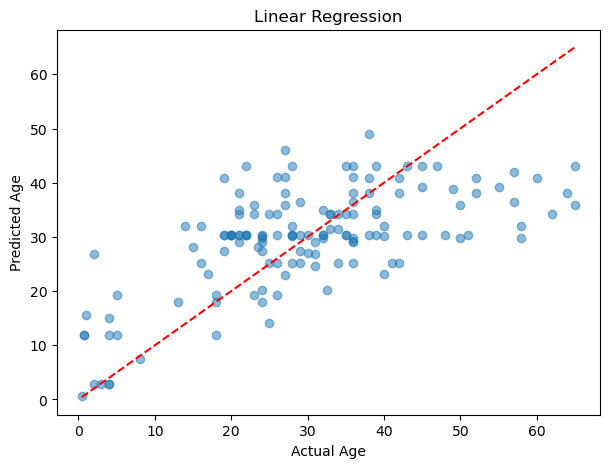

In [ ]:
# Optimization / Evaluation - Linear Regression - selected_features = ["Title","IsAlone","Pclass","Embarked","HasCabin"]


# 1. Preprocessing - Linear Regression

selected_features = ["Title","IsAlone","Pclass","Embarked","HasCabin"]

def build_preprocessor_lr(selected_features):
    onehot_cols = [c for c in selected_features if c in ["Title","IsAlone","Pclass","Embarked","HasCabin"]]

    transformers = []

    if onehot_cols:
        transformers.append((
            "oh",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            onehot_cols
        ))

    return ColumnTransformer(transformers)


# 2. Final Linear Regression Features

selected_features_lr = ["Title","IsAlone","Pclass","Embarked","HasCabin"]


# ensure that only existing columns are used
selected_features_lr = [c for c in selected_features_lr if c in X_train_rr.columns]

X_train_lr_sel = X_train_rr[selected_features_lr].copy()
X_valid_lr_sel = X_val_rr[selected_features_lr].copy()

y_train_lr = y_train.loc[X_train_lr_sel.index]
y_valid_lr = y_valid.loc[X_valid_lr_sel.index]

preprocessor_lr = build_preprocessor_lr(selected_features_lr)

baseline_lr = Pipeline([
    ("prep", preprocessor_lr),
    ("model", LinearRegression())
])


# 3. Cross-validation

cv = KFold(n_splits=5, shuffle=True, random_state=0)

cv_scores = cross_val_score(
    baseline_lr,
    X_train_lr_sel,
    y_train_lr,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rmse_scores = -cv_scores

print("=== Linear Regression - Cross-Validation ===")
print("RMSE por fold:", np.round(rmse_scores, 4))
print(f"Mean CV RMSE: {rmse_scores.mean():.4f}")
print(f"Std CV RMSE : {rmse_scores.std():.4f}")


# 4. Train final model

baseline_lr.fit(X_train_lr_sel, y_train_lr)


# 5. Evaluation on the validation set

y_pred_lr = baseline_lr.predict(X_valid_lr_sel)

mae_lr = mean_absolute_error(y_valid_lr, y_pred_lr)
mse_lr = mean_squared_error(y_valid_lr, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_valid_lr, y_pred_lr)

print("\n=== Linear Regression - Validation Metrics ===")
print(f"MAE  : {mae_lr:.4f}")
print(f"MSE  : {mse_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")


# 6. Predicted vs Actual

plt.figure(figsize=(7, 5))
plt.scatter(y_valid_lr, y_pred_lr, alpha=0.5)
plt.plot(
    [y_valid_lr.min(), y_valid_lr.max()],
    [y_valid_lr.min(), y_valid_lr.max()],
    "r--"
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Linear Regression")
plt.show()

=== Linear Regression - Cross-Validation ===
RMSE por fold: [12.2086 10.168  11.426  10.8232 12.2292]
Mean CV RMSE: 11.3710
Std CV RMSE : 0.7985

=== Linear Regression - Validation Metrics ===
MAE  : 8.6471
MSE  : 120.4246
RMSE : 10.9738
R²   : 0.4214


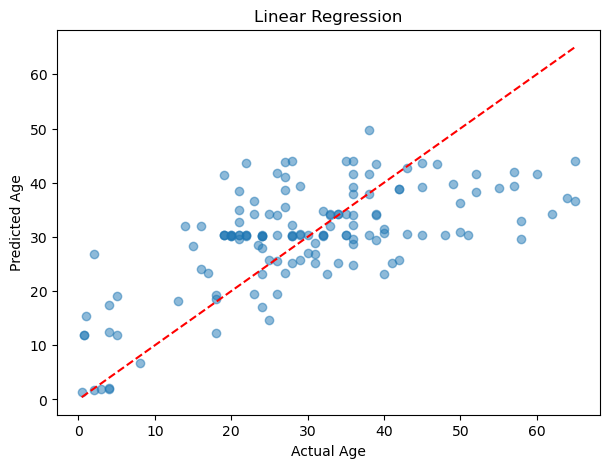

In [ ]:
# Optimization / Evaluation - Linear Regression - selected_features = ["Fare_log","Title","FamilySize","IsAlone","Pclass","Embarked"]


# 1. Preprocessing - Linear Regression

selected_features = ["Fare_log","Title","FamilySize", "IsAlone","Pclass","Embarked"]

def build_preprocessor_lr(selected_features):
    num_cols = [c for c in selected_features if c in ["Fare_log","FamilySize"]]
    onehot_cols = [c for c in selected_features if c in ["Title","IsAlone","Pclass","Embarked"]]

    transformers = []

    if num_cols:
        transformers.append(("num", StandardScaler(), num_cols))

    if onehot_cols:
        transformers.append((
            "oh",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            onehot_cols
        ))

    return ColumnTransformer(transformers)


# 2. Final Linear Regression Features

selected_features_lr = ["Fare_log","FamilySize","Title","IsAlone","Pclass","Embarked"]


# ensure that only existing columns are used
selected_features_lr = [c for c in selected_features_lr if c in X_train_rr.columns]

X_train_lr_sel = X_train_rr[selected_features_lr].copy()
X_valid_lr_sel = X_val_rr[selected_features_lr].copy()

y_train_lr = y_train.loc[X_train_lr_sel.index]
y_valid_lr = y_valid.loc[X_valid_lr_sel.index]

preprocessor_lr = build_preprocessor_lr(selected_features_lr)

baseline_lr = Pipeline([
    ("prep", preprocessor_lr),
    ("model", LinearRegression())
])


# 3. Cross-validation

cv = KFold(n_splits=5, shuffle=True, random_state=0)

cv_scores = cross_val_score(
    baseline_lr,
    X_train_lr_sel,
    y_train_lr,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rmse_scores = -cv_scores

print("=== Linear Regression - Cross-Validation ===")
print("RMSE por fold:", np.round(rmse_scores, 4))
print(f"Mean CV RMSE: {rmse_scores.mean():.4f}")
print(f"Std CV RMSE : {rmse_scores.std():.4f}")


# 4. Train final model

baseline_lr.fit(X_train_lr_sel, y_train_lr)


# 5. Evaluation on the validation set

y_pred_lr = baseline_lr.predict(X_valid_lr_sel)

mae_lr = mean_absolute_error(y_valid_lr, y_pred_lr)
mse_lr = mean_squared_error(y_valid_lr, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_valid_lr, y_pred_lr)

print("\n=== Linear Regression - Validation Metrics ===")
print(f"MAE  : {mae_lr:.4f}")
print(f"MSE  : {mse_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")


# 6. Predicted vs Actual

plt.figure(figsize=(7, 5))
plt.scatter(y_valid_lr, y_pred_lr, alpha=0.5)
plt.plot(
    [y_valid_lr.min(), y_valid_lr.max()],
    [y_valid_lr.min(), y_valid_lr.max()],
    "r--"
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Linear Regression")
plt.show()

=== Linear Regression - Cross-Validation ===
RMSE por fold: [11.8635 10.2399 11.5093 10.7196 12.2466]
Mean CV RMSE: 11.3158
Std CV RMSE : 0.7371

=== Linear Regression - Validation Metrics ===
MAE  : 8.7610
MSE  : 122.3455
RMSE : 11.0610
R²   : 0.4122


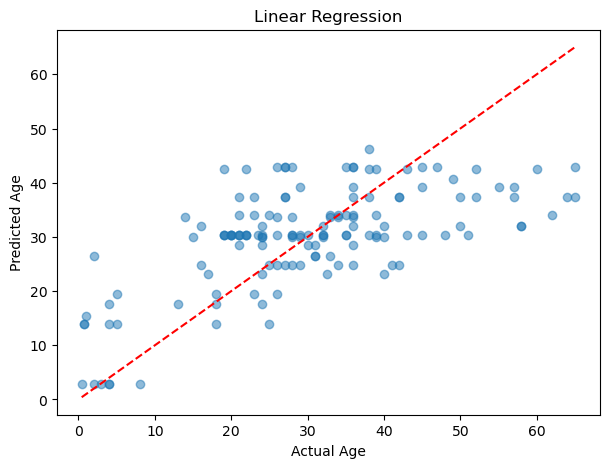

In [ ]:
# # Optimization / Evaluation - Linear Regression - selected_features = ["Title","IsAlone","Pclass"]


# 1. Preprocessing - Linear Regression

selected_features = ["Title","FamilySize", "IsAlone","Pclass"]

def build_preprocessor_lr(selected_features):
    onehot_cols = [c for c in selected_features if c in ["Title","IsAlone","Pclass"]]

    transformers = []


    if onehot_cols:
        transformers.append((
            "oh",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            onehot_cols
        ))

    return ColumnTransformer(transformers)


# 2. Final Linear Regression Features

selected_features_lr = ["Title","IsAlone","Pclass"]


# ensure that only existing columns are used
selected_features_lr = [c for c in selected_features_lr if c in X_train_rr.columns]

X_train_lr_sel = X_train_rr[selected_features_lr].copy()
X_valid_lr_sel = X_val_rr[selected_features_lr].copy()

y_train_lr = y_train.loc[X_train_lr_sel.index]
y_valid_lr = y_valid.loc[X_valid_lr_sel.index]

preprocessor_lr = build_preprocessor_lr(selected_features_lr)

baseline_lr = Pipeline([
    ("prep", preprocessor_lr),
    ("model", LinearRegression())
])


# 3. Cross-validation

cv = KFold(n_splits=5, shuffle=True, random_state=0)

cv_scores = cross_val_score(
    baseline_lr,
    X_train_lr_sel,
    y_train_lr,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rmse_scores = -cv_scores

print("=== Linear Regression - Cross-Validation ===")
print("RMSE por fold:", np.round(rmse_scores, 4))
print(f"Mean CV RMSE: {rmse_scores.mean():.4f}")
print(f"Std CV RMSE : {rmse_scores.std():.4f}")


# 4. Train final model

baseline_lr.fit(X_train_lr_sel, y_train_lr)


# 5. Evaluation on the validation set

y_pred_lr = baseline_lr.predict(X_valid_lr_sel)

mae_lr = mean_absolute_error(y_valid_lr, y_pred_lr)
mse_lr = mean_squared_error(y_valid_lr, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_valid_lr, y_pred_lr)

print("\n=== Linear Regression - Validation Metrics ===")
print(f"MAE  : {mae_lr:.4f}")
print(f"MSE  : {mse_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")


# 6. Predicted vs Actual

plt.figure(figsize=(7, 5))
plt.scatter(y_valid_lr, y_pred_lr, alpha=0.5)
plt.plot(
    [y_valid_lr.min(), y_valid_lr.max()],
    [y_valid_lr.min(), y_valid_lr.max()],
    "r--"
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Linear Regression")
plt.show()

=== Linear Regression - Cross-Validation ===
RMSE por fold: [12.2069 10.0841 11.3849 10.8123 12.3005]
Mean CV RMSE: 11.3577
Std CV RMSE : 0.8403

=== Linear Regression - Validation Metrics ===
MAE  : 8.6451
MSE  : 121.5828
RMSE : 11.0265
R²   : 0.4159


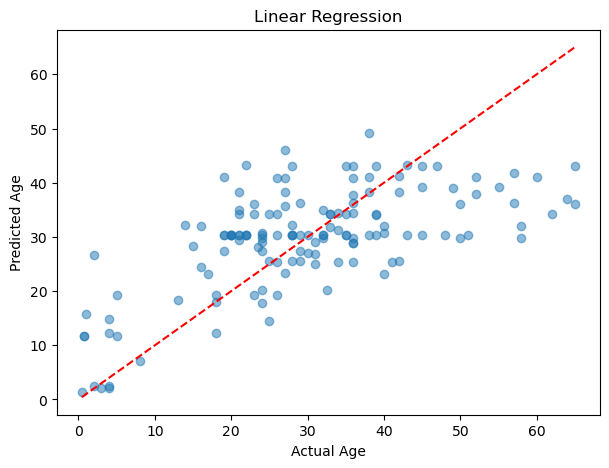

In [ ]:
# Optimization / Evaluation - Linear Regression - selected_features = ["Title","FamilySize","IsAlone","Pclass","HasCabin"]


# 1. Preprocessing - Linear Regression

selected_features = ["Title","FamilySize", "IsAlone","Pclass","Embarked","HasCabin"]

def build_preprocessor_lr(selected_features):
    num_cols = [c for c in selected_features if c in ["FamilySize"]]
    onehot_cols = [c for c in selected_features if c in ["Title","IsAlone","Pclass","Embarked","HasCabin"]]

    transformers = []

    if num_cols:
        transformers.append(("num", StandardScaler(), num_cols))

    if onehot_cols:
        transformers.append((
            "oh",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            onehot_cols
        ))

    return ColumnTransformer(transformers)


# 2. Final Linear Regression Features

selected_features_lr = ["FamilySize","Title","IsAlone","Pclass","Embarked","HasCabin"]


# ensure that only existing columns are used
selected_features_lr = [c for c in selected_features_lr if c in X_train_rr.columns]

X_train_lr_sel = X_train_rr[selected_features_lr].copy()
X_valid_lr_sel = X_val_rr[selected_features_lr].copy()

y_train_lr = y_train.loc[X_train_lr_sel.index]
y_valid_lr = y_valid.loc[X_valid_lr_sel.index]

preprocessor_lr = build_preprocessor_lr(selected_features_lr)

baseline_lr = Pipeline([
    ("prep", preprocessor_lr),
    ("model", LinearRegression())
])


# 3. Cross-validation

cv = KFold(n_splits=5, shuffle=True, random_state=0)

cv_scores = cross_val_score(
    baseline_lr,
    X_train_lr_sel,
    y_train_lr,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rmse_scores = -cv_scores

print("=== Linear Regression - Cross-Validation ===")
print("RMSE por fold:", np.round(rmse_scores, 4))
print(f"Mean CV RMSE: {rmse_scores.mean():.4f}")
print(f"Std CV RMSE : {rmse_scores.std():.4f}")


# 4. Train final model

baseline_lr.fit(X_train_lr_sel, y_train_lr)


# 5. Evaluation on the validation set

y_pred_lr = baseline_lr.predict(X_valid_lr_sel)

mae_lr = mean_absolute_error(y_valid_lr, y_pred_lr)
mse_lr = mean_squared_error(y_valid_lr, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_valid_lr, y_pred_lr)

print("\n=== Linear Regression - Validation Metrics ===")
print(f"MAE  : {mae_lr:.4f}")
print(f"MSE  : {mse_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")


# 6. Predicted vs Actual

plt.figure(figsize=(7, 5))
plt.scatter(y_valid_lr, y_pred_lr, alpha=0.5)
plt.plot(
    [y_valid_lr.min(), y_valid_lr.max()],
    [y_valid_lr.min(), y_valid_lr.max()],
    "r--"
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Linear Regression")
plt.show()

=== Linear Regression - Cross-Validation ===
RMSE por fold: [12.1686 10.1648 11.4006 10.8398 12.2469]
Mean CV RMSE: 11.3641
Std CV RMSE : 0.7926

=== Linear Regression - Validation Metrics ===
MAE  : 8.6266
MSE  : 120.3083
RMSE : 10.9685
R²   : 0.4220


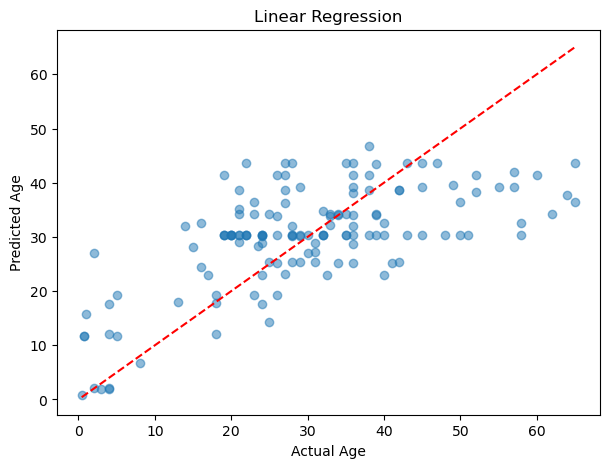

In [ ]:
# Optimization / Evaluation - Linear Regression - selected_features = ["Title","FamilySize","IsAlone","Pclass","Embarked"]


# 1. Preprocessing - Linear Regression

selected_features = ["Title","FamilySize", "IsAlone","Pclass","Embarked"]

def build_preprocessor_lr(selected_features):
    num_cols = [c for c in selected_features if c in ["FamilySize"]]
    onehot_cols = [c for c in selected_features if c in ["Title","IsAlone","Pclass","Embarked"]]

    transformers = []

    if num_cols:
        transformers.append(("num", StandardScaler(), num_cols))

    if onehot_cols:
        transformers.append((
            "oh",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            onehot_cols
        ))

    return ColumnTransformer(transformers)


# 2. Final Linear Regression Features

selected_features_lr = ["FamilySize","Title","IsAlone","Pclass","Embarked"]


# ensure that only existing columns are used
selected_features_lr = [c for c in selected_features_lr if c in X_train_rr.columns]

X_train_lr_sel = X_train_rr[selected_features_lr].copy()
X_valid_lr_sel = X_val_rr[selected_features_lr].copy()

y_train_lr = y_train.loc[X_train_lr_sel.index]
y_valid_lr = y_valid.loc[X_valid_lr_sel.index]

preprocessor_lr = build_preprocessor_lr(selected_features_lr)

baseline_lr = Pipeline([
    ("prep", preprocessor_lr),
    ("model", LinearRegression())
])


# 3. Cross-validation

cv = KFold(n_splits=5, shuffle=True, random_state=0)

cv_scores = cross_val_score(
    baseline_lr,
    X_train_lr_sel,
    y_train_lr,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rmse_scores = -cv_scores

print("=== Linear Regression - Cross-Validation ===")
print("RMSE por fold:", np.round(rmse_scores, 4))
print(f"Mean CV RMSE: {rmse_scores.mean():.4f}")
print(f"Std CV RMSE : {rmse_scores.std():.4f}")


# 4. Train final model

baseline_lr.fit(X_train_lr_sel, y_train_lr)


# 5. Evaluation on the validation set

y_pred_lr = baseline_lr.predict(X_valid_lr_sel)

mae_lr = mean_absolute_error(y_valid_lr, y_pred_lr)
mse_lr = mean_squared_error(y_valid_lr, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_valid_lr, y_pred_lr)

print("\n=== Linear Regression - Validation Metrics ===")
print(f"MAE  : {mae_lr:.4f}")
print(f"MSE  : {mse_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")


# 6. Predicted vs Actual

plt.figure(figsize=(7, 5))
plt.scatter(y_valid_lr, y_pred_lr, alpha=0.5)
plt.plot(
    [y_valid_lr.min(), y_valid_lr.max()],
    [y_valid_lr.min(), y_valid_lr.max()],
    "r--"
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Linear Regression")
plt.show()

=== Linear Regression - Cross-Validation ===
RMSE por fold: [12.2069 10.0841 11.3849 10.8123 12.3005]
Mean CV RMSE: 11.3577
Std CV RMSE : 0.8403

=== Linear Regression - Validation Metrics ===
MAE  : 8.6451
MSE  : 121.5828
RMSE : 11.0265
R²   : 0.4159


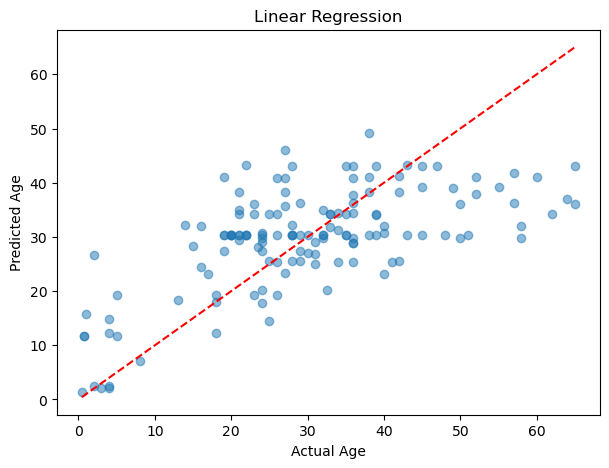

In [ ]:
# Optimization / Evaluation - Linear Regression - selected_features = ["Title","FamilySize","IsAlone","Pclass","Embarked","HasCabin"]


# 1. Preprocessing - Linear Regression

selected_features = ["Title","FamilySize", "IsAlone","Pclass","Embarked","HasCabin"]

def build_preprocessor_lr(selected_features):
    num_cols = [c for c in selected_features if c in ["FamilySize"]]
    onehot_cols = [c for c in selected_features if c in ["Title","IsAlone","Pclass","Embarked","HasCabin"]]

    transformers = []

    if num_cols:
        transformers.append(("num", StandardScaler(), num_cols))

    if onehot_cols:
        transformers.append((
            "oh",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            onehot_cols
        ))

    return ColumnTransformer(transformers)


# 2. Final Linear Regression Features
selected_features_lr = ["FamilySize","Title","IsAlone","Pclass","Embarked","HasCabin"]


# ensure that only existing columns are used
selected_features_lr = [c for c in selected_features_lr if c in X_train_rr.columns]

X_train_lr_sel = X_train_rr[selected_features_lr].copy()
X_valid_lr_sel = X_val_rr[selected_features_lr].copy()

y_train_lr = y_train.loc[X_train_lr_sel.index]
y_valid_lr = y_valid.loc[X_valid_lr_sel.index]

preprocessor_lr = build_preprocessor_lr(selected_features_lr)

baseline_lr = Pipeline([
    ("prep", preprocessor_lr),
    ("model", LinearRegression())
])


# 3. Cross-validation

cv = KFold(n_splits=5, shuffle=True, random_state=0)

cv_scores = cross_val_score(
    baseline_lr,
    X_train_lr_sel,
    y_train_lr,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rmse_scores = -cv_scores

print("=== Linear Regression - Cross-Validation ===")
print("RMSE por fold:", np.round(rmse_scores, 4))
print(f"Mean CV RMSE: {rmse_scores.mean():.4f}")
print(f"Std CV RMSE : {rmse_scores.std():.4f}")


# 4. Train final model

baseline_lr.fit(X_train_lr_sel, y_train_lr)


# 5. Evaluation on the validation set
y_pred_lr = baseline_lr.predict(X_valid_lr_sel)

mae_lr = mean_absolute_error(y_valid_lr, y_pred_lr)
mse_lr = mean_squared_error(y_valid_lr, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_valid_lr, y_pred_lr)

print("\n=== Linear Regression - Validation Metrics ===")
print(f"MAE  : {mae_lr:.4f}")
print(f"MSE  : {mse_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")


# 6. Predicted vs Actual

plt.figure(figsize=(7, 5))
plt.scatter(y_valid_lr, y_pred_lr, alpha=0.5)
plt.plot(
    [y_valid_lr.min(), y_valid_lr.max()],
    [y_valid_lr.min(), y_valid_lr.max()],
    "r--"
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Linear Regression")
plt.show()

>After applying feature selection to Linear Regression, different combinations of variables were tested, with slight improvements observed in the model’s performance. The best result was achieved with an RMSE of approximately 10.9685 and an R² of 0.4220.


=== Ridge Regression Summary ===
MAE  : 8.6180
MSE  : 120.2295
RMSE : 10.9649
R²   : 0.4224


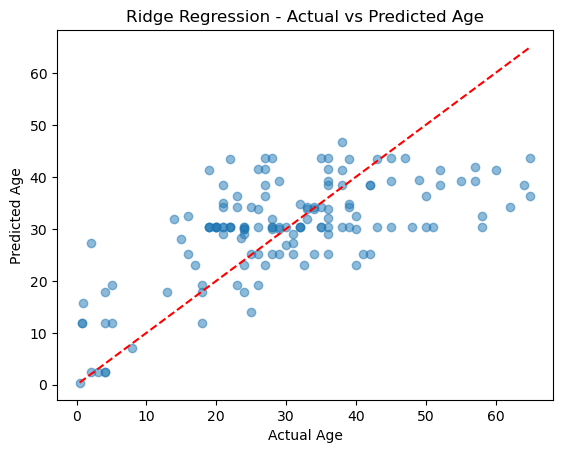

In [ ]:
# Optimized Ridge Regression


# 1. Define features

selected_features = ["Title","IsAlone", "Pclass","Embarked"] 

X_train_sel = X_train_full[selected_features].copy()
X_val_sel = X_valid_full[selected_features].copy()

y_train_aligned = y_train.loc[X_train_sel.index]
y_val_aligned = y_valid.loc[X_val_sel.index]


# 2. Define column types

onehot_cols = ["Title","IsAlone", "Pclass","Embarked"]


# 3. Pipelines by variable type

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 4. Preprocessor

preprocessor = ColumnTransformer([
    ("oh", onehot_pipeline, onehot_cols)
])


# 5. Final Pipeline with Ridge Regression

model_ridge = Pipeline([
    ("prep", preprocessor),
    ("model", Ridge(
        alpha=0.001,          #optimal regularization value obtained via GridSearchCV
    ))
])


# 6. Train model

model_ridge.fit(X_train_sel, y_train_aligned)


# 7. Predictions

y_pred_ridge = model_ridge.predict(X_val_sel)


# 8. Metrics

mae = mean_absolute_error(y_val_aligned, y_pred_ridge)
mse = mean_squared_error(y_val_aligned, y_pred_ridge)
rmse = np.sqrt(mse)
r2 = r2_score(y_val_aligned, y_pred_ridge)

print("\n=== Ridge Regression Summary ===")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


# 9. Predicted vs actual values

plt.scatter(y_val_aligned, y_pred_ridge, alpha=0.5)
plt.plot(
    [y_val_aligned.min(), y_val_aligned.max()],
    [y_val_aligned.min(), y_val_aligned.max()],
    'r--'
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Ridge Regression - Actual vs Predicted Age")
plt.show()

>The optimized Ridge model, using only the variables Title, IsAlone, Pclass, and Embarked, demonstrated solid performance, with an RMSE of approximately 10.96 and an R² of 0.422. These results are comparable — and slightly superior — to those previously obtained with a larger set of variables, indicating that a reduced set of features is sufficient to capture most of the relevant information. This suggests a simpler, more interpretable model with good generalization capability.


=== Detailed Linear Regression Summary ===
Mean Absolute Error (MAE): 8.6266
Mean Squared Error (MSE): 120.3083
Root Mean Squared Error (RMSE): 10.9685
R² Score: 0.4220


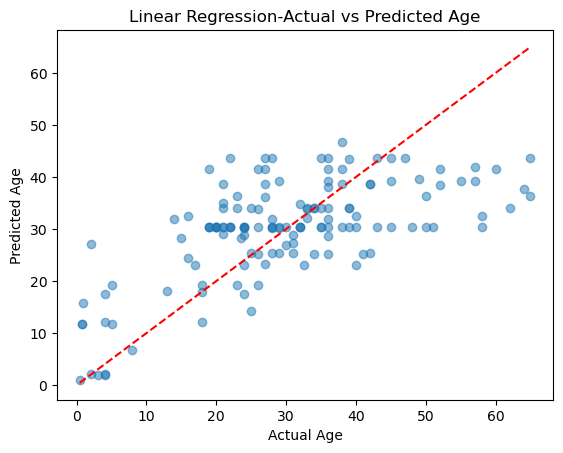

In [ ]:
# Optimized Linear Regression


# 1. Define features

selected_features = ["FamilySize","Title", "IsAlone", "Embarked", "Pclass"] #Linear Regression otimizada com o conjunto final de features selecionadas

X_train_sel = X_train_full[selected_features].copy()
X_val_sel = X_valid_full[selected_features].copy()

y_train_aligned = y_train.loc[X_train_sel.index]
y_val_aligned = y_valid.loc[X_val_sel.index]


# 2. Define column types

numeric_cols = ["FamilySize"]
onehot_cols = ["Title", "IsAlone", "Embarked", "Pclass"]


# 3. Pipelines by variable type

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 4. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 5. Final Pipeline with Linear Regression

model_lr = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])


# 6. Train model

model_lr.fit(X_train_sel, y_train_aligned)


# 7. Predictions

y_pred_lr = model_lr.predict(X_val_sel)


# 8. Metrics

mae = mean_absolute_error(y_val_aligned, y_pred_lr)
mse = mean_squared_error(y_val_aligned, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_val_aligned, y_pred_lr)

print("\n=== Detailed Linear Regression Summary ===")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


# 9. Predicted vs actual values

plt.scatter(y_val_aligned, y_pred_lr, alpha=0.5)
plt.plot(
    [y_val_aligned.min(), y_val_aligned.max()],
    [y_val_aligned.min(), y_val_aligned.max()],
    'r--'
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Linear Regression-Actual vs Predicted Age")
plt.show()

>The optimized Linear Regression model showed solid performance, with an RMSE of approximately 10.9685 and an R² of 0.4220. These results are virtually identical to those obtained with Ridge Regression.</p>

In [ ]:
# Final comparison - Linear vs Ridge

results = pd.DataFrame({
    "Modelo": ["Linear Regression", "Ridge Regression"],
    "MAE": [8.6266, 8.6180],
    "RMSE": [10.9685, 10.9649],
    "R2": [0.4220, 0.4224]
})

# display table
print(results)

              Modelo     MAE     RMSE      R2
0  Linear Regression  8.6266  10.9685  0.4220
1   Ridge Regression  8.6180  10.9649  0.4224


>The final comparison between the optimized models highlights very similar performance between Linear Regression and Ridge Regression. Both models present close values in the error metrics and in the coefficient of determination (R² ≈ 0.42), with Ridge Regression performing slightly better, which justifies its selection as the final model.

In [ ]:
# Variables that most influence the model's predictions


# 1. Feature names after preprocessing

feature_names = model_ridge.named_steps["prep"].get_feature_names_out()

# 2. Ridge model coefficients

coefficients = model_ridge.named_steps["model"].coef_

# 3.  Combine everything

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)
})

# 4. Sort by absolute impact
coef_df = coef_df.sort_values(by="abs_coefficient", ascending=False)

# 5. Display
print(coef_df)

           feature  coefficient  abs_coefficient
2    oh__Title_Mrs    27.601266        27.601266
3  oh__Title_Other    25.703533        25.703533
1     oh__Title_Mr    22.635131        22.635131
6     oh__Pclass_3   -13.330523        13.330523
0   oh__Title_Miss    11.456675        11.456675
5     oh__Pclass_2    -9.472853         9.472853
7   oh__Embarked_Q     6.789350         6.789350
4    oh__IsAlone_1     5.265727         5.265727
8   oh__Embarked_S     2.094416         2.094416


>This code extracts the coefficients from the Ridge model after preprocessing, allowing the evaluation of the importance of each variable in predicting age. The features are sorted by the absolute value of the coefficients, identifying the most influential ones. The results show that variables related to Title have the greatest impact, followed by Pclass, while Embarked, IsAlone, and FamilySize exhibit lower influence on the model.
</p>

X_processed_df shape: (570, 9)
SHAP shape: (570, 9)


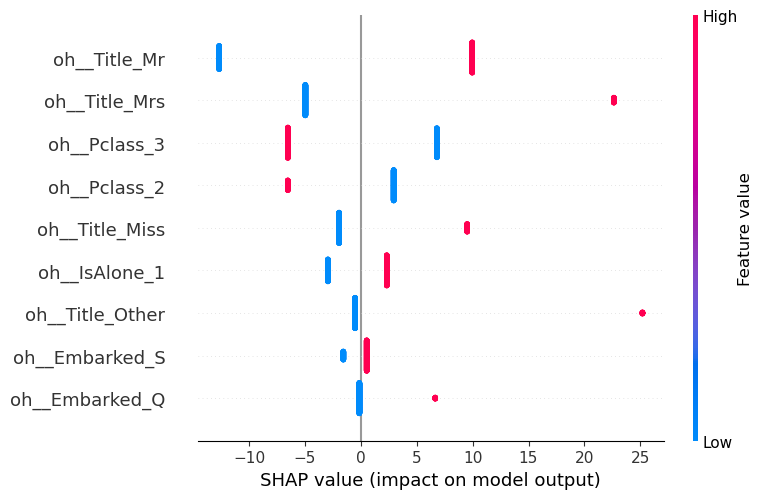

In [ ]:
# Interpretation of the Ridge Regression Model with SHAP (Feature Importance and Impact on Predictions)


# 1. Apply the pipeline preprocessing to the data used in the model

X_processed = model_ridge.named_steps["prep"].transform(X_train_sel)

# 2.If in sparse format, convert to array

if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()

# 3. Get feature names after preprocessing

feature_names = model_ridge.named_steps["prep"].get_feature_names_out()

# 4. Create DataFrame with transformed features

X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

# 5. Extract only the final Ridge model

ridge_model = model_ridge.named_steps["model"]

# 6. Create SHAP explainer for linear model

explainer = shap.LinearExplainer(ridge_model, X_processed_df)

# 7. Compute SHAP values

shap_values = explainer.shap_values(X_processed_df)

# 8. Check shapes

sv = np.array(shap_values)
print("X_processed_df shape:", X_processed_df.shape)
print("SHAP shape:", sv.shape)

# 9. Summary plot

if sv.ndim == 2:
    if sv.shape[0] == X_processed_df.shape[0] and sv.shape[1] == X_processed_df.shape[1]:
        shap.summary_plot(sv, X_processed_df)
    else:
        print("Formato 2D não compatível:", sv.shape)
else:
    print("Formato inesperado:", sv.shape)

This code uses SHAP to interpret the Ridge model, allowing the analysis of the impact of each variable on age predictions. After applying preprocessing to the data, SHAP values are computed, indicating how much each feature contributes positively or negatively to the prediction for each observation. Positive SHAP values indicate that a given feature contributes to predicting higher ages, while negative values point to lower predicted ages. <br><br>

Although there is some tendency for the Mr category to be associated with higher SHAP values and Mrs and Miss with lower values, this relationship is not consistent, as both positive and negative impacts are observed across all categories. Thus, the influence of Title on age prediction depends on the context of the other variables in the model. <br><br>

Regarding the Pclass variable, lower classes (2nd and 3rd class) are associated with negative SHAP values, contributing to predictions of lower ages, particularly for Pclass 3. <br><br>

The variables Embarked and IsAlone show a more limited impact.


In [ ]:
#Evaluation of Ridge Regression Model Robustness with Repeated K-Fold


# 1. Preprocessing

def build_preprocessor(selected_features):

    onehot_cols = [c for c in selected_features if c in ["Title", "IsAlone", "Pclass", "Embarked"]]

    onehot_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
    ])

    return ColumnTransformer([
        ("oh", onehot_pipeline, onehot_cols)
    ])


# 2. Data

selected_features = ["Title", "IsAlone", "Pclass", "Embarked"]


# combine train + validation
X_dev = pd.concat([
    X_train_full[selected_features],
    X_valid_full[selected_features]
], axis=0)

y_dev = pd.concat([
    y_train.loc[X_train_full.index],
    y_valid.loc[X_valid_full.index]
], axis=0)

X_dev = X_dev.loc[y_dev.index]


# 3. Ridge Model

preprocessor = build_preprocessor(selected_features)

final_model_ridge = Pipeline([
    ("prep", preprocessor),
    ("model", Ridge(alpha=0.001))
])


# 4. Repeated K-Fold

rkf = RepeatedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=0
)

results = []

for fold_idx, (train_idx, valid_idx) in enumerate(rkf.split(X_dev), start=1):

    X_train_fold = X_dev.iloc[train_idx]
    X_valid_fold = X_dev.iloc[valid_idx]
    y_train_fold = y_dev.iloc[train_idx]
    y_valid_fold = y_dev.iloc[valid_idx]

    # train
    final_model_ridge.fit(X_train_fold, y_train_fold)


    # train metrics
    y_train_pred = final_model_ridge.predict(X_train_fold)

    train_mae = mean_absolute_error(y_train_fold, y_train_pred)
    train_mse = mean_squared_error(y_train_fold, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train_fold, y_train_pred)


    # validation metrics
    y_valid_pred = final_model_ridge.predict(X_valid_fold)

    valid_mae = mean_absolute_error(y_valid_fold, y_valid_pred)
    valid_mse = mean_squared_error(y_valid_fold, y_valid_pred)
    valid_rmse = np.sqrt(valid_mse)
    valid_r2 = r2_score(y_valid_fold, y_valid_pred)

    results.append({
        "fold": fold_idx,
        "train_mae": train_mae,
        "train_mse": train_mse,
        "train_rmse": train_rmse,
        "train_r2": train_r2,
        "valid_mae": valid_mae,
        "valid_mse": valid_mse,
        "valid_rmse": valid_rmse,
        "valid_r2": valid_r2
    })

results_df = pd.DataFrame(results)


# 5. Results

print("=== Resultados por fold (amostra) ===")
print(results_df.head())

metric_cols = [
    "train_mae", "train_mse", "train_rmse", "train_r2",
    "valid_mae", "valid_mse", "valid_rmse", "valid_r2"
]

print("\n=== Média ===")
print(results_df[metric_cols].mean().round(4))

print("\n=== Desvio padrão ===")
print(results_df[metric_cols].std().round(4))


# 6. Train - Validation gap

gap = pd.Series({
    "mae_gap": results_df["train_mae"].mean() - results_df["valid_mae"].mean(),
    "mse_gap": results_df["train_mse"].mean() - results_df["valid_mse"].mean(),
    "rmse_gap": results_df["train_rmse"].mean() - results_df["valid_rmse"].mean(),
    "r2_gap": results_df["train_r2"].mean() - results_df["valid_r2"].mean()
})

print("\n=== Diferença média treino - validação ===")
print(gap.round(4))


# 7. Automatic interpretation

print("\n=== Interpretação ===")

for metric in ["mae", "mse", "rmse", "r2"]:

    train_mean = results_df[f"train_{metric}"].mean()
    valid_mean = results_df[f"valid_{metric}"].mean()
    gap_value = train_mean - valid_mean

    if metric == "r2":
        relative_gap = abs(gap_value)
    else:
        relative_gap = abs(gap_value) / valid_mean

    print(f"{metric}_gap: {gap_value:.4f}")

    if relative_gap > 0.05:
        print(" -> possível overfitting")
    elif relative_gap > 0.02:
        print(" -> ligeiro sinal de overfitting")
    else:
        print(" -> modelo estável")

=== Resultados por fold (amostra) ===
   fold  train_mae   train_mse  train_rmse  train_r2  valid_mae   valid_mse  \
0     1   8.586637  117.673380   10.847736  0.428983   9.000453  136.218052   
1     2   8.814394  125.391214   11.197822  0.403189   8.302512  108.186147   
2     3   8.619524  117.777959   10.852555  0.429282   8.868328  137.006558   
3     4   8.650685  122.178808   11.053452  0.419873   8.942275  118.571509   
4     5   8.599316  120.193481   10.963279  0.441917   9.170773  128.733938   

   valid_rmse  valid_r2  
0   11.671249  0.388325  
1   10.401257  0.479750  
2   11.704980  0.385854  
3   10.889055  0.425276  
4   11.346098  0.304376  

=== Média ===
train_mae       8.6594
train_mse     120.6970
train_rmse     10.9848
train_r2        0.4242
valid_mae       8.8298
valid_mse     125.2435
valid_rmse     11.1689
valid_r2        0.3968
dtype: float64

=== Desvio padrão ===
train_mae      0.1356
train_mse      3.9457
train_rmse     0.1798
train_r2       0.0151
valid_

To evaluate the robustness of the optimized <b>Ridge model</b>, a cross-validation procedure was applied using <b>Repeated K-Fold (5 folds and 10 repetitions)</b>, allowing the model’s performance to be tested across multiple data splits. In each iteration, the model was trained and evaluated based on the metrics <b>MAE, MSE, RMSE, and R²</b>. The average results obtained on the validation set (<b>MAE ≈ 8.83, RMSE ≈ 11.17, and R² ≈ 0.397</b>) are consistent across different folds, indicating stable performance. <br><br>

Additionally, the relatively low <b>standard deviations</b> (notably <b>RMSE ≈ 0.71</b>) indicate low variability across samples, reinforcing the model’s <b>generalization</b> capability. The difference between training and validation performance is minimal, with only slight indications of <b>overfitting</b>. Overall, the model demonstrates a good balance between <b>bias and variance</b>, showing robustness and reliability in its predictions.
</p>


# Attachments

## Attachment PART B

In the presented code, a test was conducted using the <b>Logistic Regression</b> algorithm, with the aim of identifying the most appropriate strategy for imputing missing values in the <b>Age variable</b>. <br><br>

Different imputation approaches were compared, and it was found that the most effective strategy consists of grouping the Age variable by the Title variable, calculating the <b>median</b> age for each group, and using this value to fill the corresponding missing values. This approach enables a more informed imputation, as it considers characteristics associated with the passengers’ <b>social and demographic context</b>, leading to improved model performance. <br><br>

<b>Note:</b> It is important to highlight that at this stage the <b>imputation of missing values</b> in the Age variable had not yet been performed. This step was carried out only after the <b>dataset was split</b> into training and testing data, thus ensuring the absence of <b>data leakage</b>.
</p>


In [ ]:
# CODE TO SPLIT DATASET INTO 2

mlflow.autolog(disable=True)

data = train_df


# Separate the target variable from the predictor variables

y = data["Survived"]
X = data.drop(["Survived"], axis=1)


# Split the data into training and validation subsets

X_train_full, X_valid_full, y_train, y_valid = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=0,
    stratify=y
)

In [ ]:
# 1.  Transformer to select columns

class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[self.columns].copy()


# 2. Transformer to recreate AgeGroup after imputation

class AgeGroupCreator(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X["AgeGroup"] = pd.cut(
            X["Age"],
            bins=[0, 12, 18, 60, float("inf")],
            labels=["Child", "Teen", "Adult", "Senior"],
            right=False
        )

        return X


# 3. Age variable imputer

class AgeImputer(BaseEstimator, TransformerMixin):
    def __init__(self, strategy="median"):
        self.strategy = strategy
        self.global_value_ = None
        self.title_map_ = None

    def fit(self, X, y=None):
        X = X.copy()

        if self.strategy == "median":
            self.global_value_ = X["Age"].median()

        elif self.strategy == "mean":
            self.global_value_ = X["Age"].mean()

        elif self.strategy == "title_median":
            self.title_map_ = X.groupby("Title")["Age"].median()
            self.global_value_ = X["Age"].median()

        elif self.strategy == "title_mean":
            self.title_map_ = X.groupby("Title")["Age"].mean()
            self.global_value_ = X["Age"].mean()

        else:
            raise ValueError(
                "Estratégia inválida. Use: 'median', 'mean', 'title_median' ou 'title_mean'."
            )

        return self

    def transform(self, X):
        X = X.copy()

        if self.strategy in ["median", "mean"]:
            X["Age"] = X["Age"].fillna(self.global_value_)

        elif self.strategy in ["title_median", "title_mean"]:
            missing_mask = X["Age"].isna()
            X.loc[missing_mask, "Age"] = X.loc[missing_mask, "Title"].map(self.title_map_)
            X["Age"] = X["Age"].fillna(self.global_value_)

        return X


# 4. Imputation strategies

imputation_strategies = {
    "median": AgeImputer(strategy="median"),
    "mean": AgeImputer(strategy="mean"),
    "title_median": AgeImputer(strategy="title_median"),
    "title_mean": AgeImputer(strategy="title_mean")
}


# 5. Fixed features to use in comparison

selected_cols = [
    "Age",
    "Fare",
    "Title",
    "FamilySize",
    "Embarked",
    "Pclass",
    "HasCabin"
]


# 6. Variable types

numeric_features = ["Age", "Fare", "FamilySize"]
onehot_features = ["Embarked", "Title", "Pclass", "HasCabin"]


# 7. Function to create the preprocessor

def build_preprocessor(selected_cols):
    num_cols = [col for col in selected_cols if col in numeric_features]
    oh_cols = [col for col in selected_cols if col in onehot_features]

    transformers = []

    if num_cols:
        transformers.append(("num", StandardScaler(), num_cols))

    if oh_cols:
        transformers.append(
            ("oh", OneHotEncoder(handle_unknown="ignore", drop="first"), oh_cols)
        )

    return ColumnTransformer(transformers)


# 8. Evaluation of the 4 imputation strategies

results = []

preprocessor = build_preprocessor(selected_cols)

for imputation_name, age_imputer in imputation_strategies.items():

    pipe = Pipeline([
        ("age_imputer", age_imputer),
        ("selector", ColumnSelector(selected_cols)),
        ("prep", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=0))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

    score = cross_val_score(
        pipe,
        X_train_full.copy(),
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=1
    ).mean()

    results.append({
        "Imputation": imputation_name,
        "Features": selected_cols,
        "ROC_AUC": score
    })


# 9. Sorted results

results_df = (
    pd.DataFrame(results)
    .sort_values(by="ROC_AUC", ascending=False)
    .reset_index(drop=True)
)

print(results_df)

     Imputation                                           Features   ROC_AUC
0  title_median  [Age, Fare, Title, FamilySize, Embarked, Pclas...  0.871811
1    title_mean  [Age, Fare, Title, FamilySize, Embarked, Pclas...  0.871638
2          mean  [Age, Fare, Title, FamilySize, Embarked, Pclas...  0.871408
3        median  [Age, Fare, Title, FamilySize, Embarked, Pclas...  0.871281


>According to the results obtained, the imputation strategy for missing values in the Age variable that achieved the best performance, as evaluated by the ROC-AUC metric, was filling with the median by Title group.

A test was also conducted to train the <b>Logistic Regression (LR)</b> model and analyze the metrics on the validation dataset, assuming that missing values in the <b>Embarked</b> variable were imputed using the <b>mode</b>. <br><br>

Subsequently, the model was trained by <b>removing records with missing values</b> (removal of 2 rows from the dataset). <br><br>

The objective of this analysis was to determine which technique ensured better performance in the validation metrics, as demonstrated in the code blocks below.
</p>

In [ ]:
# CODE TO SPLIT DATASET INTO 2

mlflow.autolog(disable=True)

data = train_df


# Separate the target variable from the predictor variables

y = data["Survived"]
X = data.drop(["Survived"], axis=1)


# Split the data into training and validation subsets

X_train_full, X_valid_full, y_train, y_valid = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=0,
    stratify=y
)

In [ ]:
# AGE IMPUTATION


# Learn values from the training set

title_age_map = X_train_full.groupby("Title")["Age"].median()
global_age_median = X_train_full["Age"].median()


# 1. TRAINING PHASE


# impute Age

X_train_full["Age"] = X_train_full["Age"].fillna(
    X_train_full["Title"].map(title_age_map)
)

X_train_full["Age"] = X_train_full["Age"].fillna(global_age_median)


# create AgeGroup

X_train_full["AgeGroup"] = pd.cut(
    X_train_full["Age"],
    bins=[0, 12, 18, 60, float("inf")],
    labels=["Child", "Teen", "Adult", "Senior"],
    right=False
)


# 2. VALIDATION PHASE


# impute Age using training information

X_valid_full["Age"] = X_valid_full["Age"].fillna(
    X_valid_full["Title"].map(title_age_map)
)

X_valid_full["Age"] = X_valid_full["Age"].fillna(global_age_median)


# create AgeGroup

X_valid_full["AgeGroup"] = pd.cut(
    X_valid_full["Age"],
    bins=[0, 12, 18, 60, float("inf")],
    labels=["Child", "Teen", "Adult", "Senior"],
    right=False
)


# 3. CHECK

print("=== NaNs ===")
print("Train Age:", X_train_full["Age"].isna().sum())
print("Train AgeGroup:", X_train_full["AgeGroup"].isna().sum())
print("Valid Age:", X_valid_full["Age"].isna().sum())
print("Valid AgeGroup:", X_valid_full["AgeGroup"].isna().sum())

print("\n=== Distribuição AgeGroup (Train) ===")
print(X_train_full["AgeGroup"].value_counts(dropna=False))

print("\n=== Distribuição AgeGroup (Valid) ===")
print(X_valid_full["AgeGroup"].value_counts(dropna=False))

=== NaNs ===
Train Age: 0
Train AgeGroup: 0
Valid Age: 0
Valid AgeGroup: 0

=== Distribuição AgeGroup (Train) ===
AgeGroup
Adult     595
Child      58
Teen       39
Senior     20
Name: count, dtype: int64

=== Distribuição AgeGroup (Valid) ===
AgeGroup
Adult     153
Child      14
Teen        6
Senior      6
Name: count, dtype: int64


=== Logistic Regression - Validation Metrics ===
Accuracy : 0.6704
Precision: 0.5926
Recall   : 0.4638
F1-score : 0.5203
ROC-AUC  : 0.7367

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.70      0.80      0.75       110
           1       0.59      0.46      0.52        69

    accuracy                           0.67       179
   macro avg       0.65      0.63      0.63       179
weighted avg       0.66      0.67      0.66       179


=== Confusion Matrix ===
[[88 22]
 [37 32]]


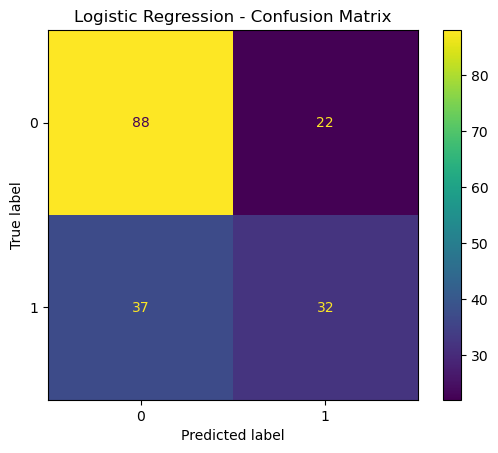

In [ ]:
# 1st Strategy - Age imputation + replacing missing values in the Embarked variable with the mode


# Learn values from the training set

title_age_map = X_train_full.groupby("Title")["Age"].median()
global_age_median = X_train_full["Age"].median()
mode_embarked = X_train_full["Embarked"].mode()[0]


# 1. TRAINING PHASE


# impute Age

X_train_full["Age"] = X_train_full["Age"].fillna(
    X_train_full["Title"].map(title_age_map)
)

X_train_full["Age"] = X_train_full["Age"].fillna(global_age_median)


# create AgeGroup

X_train_full["AgeGroup"] = pd.cut(
    X_train_full["Age"],
    bins=[0, 12, 18, 60, float("inf")],
    labels=["Child", "Teen", "Adult", "Senior"],
    right=False
)


# impute Embarked - replace missing values in the Embarked variable with the mode

X_train_full["Embarked"] = X_train_full["Embarked"].fillna(mode_embarked)


# 2. VALIDATION PHASE


# impute Age using training information

X_valid_full["Age"] = X_valid_full["Age"].fillna(
    X_valid_full["Title"].map(title_age_map)
)

X_valid_full["Age"] = X_valid_full["Age"].fillna(global_age_median)


# create AgeGroup

X_valid_full["AgeGroup"] = pd.cut(
    X_valid_full["Age"],
    bins=[0, 12, 18, 60, float("inf")],
    labels=["Child", "Teen", "Adult", "Senior"],
    right=False
)


# impute Embarked (use value from training set!)

X_valid_full["Embarked"] = X_valid_full["Embarked"].fillna(mode_embarked)


# 3. Define features

selected_features = ["Pclass", "Age","FamilySize", "Embarked"]

X_train_sel = X_train_full[selected_features].copy()
X_val_sel = X_valid_full[selected_features].copy()

y_train_aligned = y_train.loc[X_train_sel.index]
y_val_aligned = y_valid.loc[X_val_sel.index]


# 4.  Define column types

numeric_cols = ["FamilySize", "Age"]
onehot_cols = ["Pclass", "Embarked"]


# 5. Pipelines by variable type

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 6. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 7. Final Pipeline with Logistic Regression

model_lr = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=0
    ))
])


# 8. Train model

model_lr.fit(X_train_sel, y_train_aligned)


# 9. Predictions

y_pred_lr = model_lr.predict(X_val_sel)
y_prob_lr = model_lr.predict_proba(X_val_sel)[:, 1]


# 10. Metrics

accuracy_lr = accuracy_score(y_val_aligned, y_pred_lr)
precision_lr = precision_score(y_val_aligned, y_pred_lr)
recall_lr = recall_score(y_val_aligned, y_pred_lr)
f1_lr = f1_score(y_val_aligned, y_pred_lr)
roc_auc_lr = roc_auc_score(y_val_aligned, y_prob_lr)

print("=== Logistic Regression - Validation Metrics ===")
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1-score : {f1_lr:.4f}")
print(f"ROC-AUC  : {roc_auc_lr:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_val_aligned, y_pred_lr))


# 11. Confusion Matrix

cm_lr = confusion_matrix(y_val_aligned, y_pred_lr)
print("\n=== Confusion Matrix ===")
print(cm_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [ ]:
# CODE TO SPLIT DATASET INTO 2

mlflow.autolog(disable=True)

data = train_df


# Separate target from predictors

y = data["Survived"]
X = data.drop(["Survived"], axis=1)


# Divide data into training and validation subsets

X_train_full, X_valid_full, y_train, y_valid = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=0,
    stratify=y
)

=== Logistic Regression - Validation Metrics ===
Accuracy : 0.6760
Precision: 0.6038
Recall   : 0.4638
F1-score : 0.5246
ROC-AUC  : 0.7374

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.71      0.81      0.75       110
           1       0.60      0.46      0.52        69

    accuracy                           0.68       179
   macro avg       0.66      0.64      0.64       179
weighted avg       0.67      0.68      0.67       179


=== Confusion Matrix ===
[[89 21]
 [37 32]]


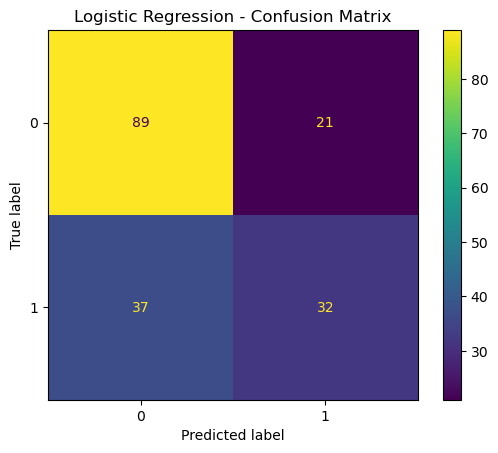

In [ ]:
# 2nd Strategy - Age imputation + removal of missing values in the Embarked variable


# Learn values from the training set

title_age_map = X_train_full.groupby("Title")["Age"].median()
global_age_median = X_train_full["Age"].median()


# 1. TRAINING PHASE


# remove rows with missing Embarked values (X and y aligned)

mask_train = X_train_full["Embarked"].notna()
X_train_full = X_train_full[mask_train]
y_train = y_train[mask_train]


# impute Age

X_train_full["Age"] = X_train_full["Age"].fillna(
    X_train_full["Title"].map(title_age_map)
)

X_train_full["Age"] = X_train_full["Age"].fillna(global_age_median)


# create AgeGroup

X_train_full["AgeGroup"] = pd.cut(
    X_train_full["Age"],
    bins=[0, 12, 18, 60, float("inf")],
    labels=["Child", "Teen", "Adult", "Senior"],
    right=False
)


# 2. VALIDATION PHASE


# remove rows with missing Embarked values (X and y aligned)

mask_valid = X_valid_full["Embarked"].notna()
X_valid_full = X_valid_full[mask_valid]
y_valid = y_valid[mask_valid]


# impute Age using training information

X_valid_full["Age"] = X_valid_full["Age"].fillna(
    X_valid_full["Title"].map(title_age_map)
)

X_valid_full["Age"] = X_valid_full["Age"].fillna(global_age_median)


# create AgeGroup

X_valid_full["AgeGroup"] = pd.cut(
    X_valid_full["Age"],
    bins=[0, 12, 18, 60, float("inf")],
    labels=["Child", "Teen", "Adult", "Senior"],
    right=False
)


# 3. Define features

selected_features = ["Pclass", "Age","FamilySize", "Embarked"]

X_train_sel = X_train_full[selected_features].copy()
X_val_sel = X_valid_full[selected_features].copy()

y_train_aligned = y_train.loc[X_train_sel.index]
y_val_aligned = y_valid.loc[X_val_sel.index]


# 4. Define column types

numeric_cols = ["FamilySize", "Age"]
onehot_cols = ["Pclass", "Embarked"]


# 5. Pipelines by variable type

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 6. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 7. Final Pipeline with Logistic Regression

model_lr = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=0
    ))
])


# 8. Train model

model_lr.fit(X_train_sel, y_train_aligned)


# 9. Predictions

y_pred_lr = model_lr.predict(X_val_sel)
y_prob_lr = model_lr.predict_proba(X_val_sel)[:, 1]


# 10. Metrics

accuracy_lr = accuracy_score(y_val_aligned, y_pred_lr)
precision_lr = precision_score(y_val_aligned, y_pred_lr)
recall_lr = recall_score(y_val_aligned, y_pred_lr)
f1_lr = f1_score(y_val_aligned, y_pred_lr)
roc_auc_lr = roc_auc_score(y_val_aligned, y_prob_lr)

print("=== Logistic Regression - Validation Metrics ===")
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1-score : {f1_lr:.4f}")
print(f"ROC-AUC  : {roc_auc_lr:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_val_aligned, y_pred_lr))


# 11. Confusion Matrix

cm_lr = confusion_matrix(y_val_aligned, y_pred_lr)
print("\n=== Confusion Matrix ===")
print(cm_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

>The strategy that produced the best results was the second one — removing missing values from the Embarked variable — as a slight improvement is observed in the Logistic Regression model’s performance metrics, particularly in Precision (1st strategy: 0.5926; 2nd strategy: 0.6038).

## Attachment Part C

In [ ]:
#Random Forest model pipeline including logarithmic transformation of the Fare variable and standard scaling of numerical variables

# 1. Create Fare_log

X_train_full = X_train_full.copy()
X_valid_full = X_valid_full.copy()

X_train_full["Fare_log"] = np.log1p(X_train_full["Fare"])
X_valid_full["Fare_log"] = np.log1p(X_valid_full["Fare"])


# 2. Preprocessing

def build_preprocessor(selected_features):

    num_cols = [c for c in selected_features if c in ["Fare_log", "Age", "FamilySize"]]
    onehot_cols = [c for c in selected_features if c in ["Title", "Pclass", "Sex"]]

    transformers = []

    if num_cols:
        transformers.append(("num", StandardScaler(), num_cols))

    if onehot_cols:
        transformers.append(
            ("oh", OneHotEncoder(handle_unknown="ignore", drop="first"), onehot_cols)
        )

    return ColumnTransformer(transformers)


# 3. Data

selected_features = ["Title", "Pclass", "Age", "Sex", "Fare_log", "FamilySize"]

# combine train + validation
X_dev = pd.concat([
    X_train_full[selected_features],
    X_valid_full[selected_features]
], axis=0)

y_dev = pd.concat([
    y_train.loc[X_train_full.index],
    y_valid.loc[X_valid_full.index]
], axis=0)

X_dev = X_dev.loc[y_dev.index]


# 3. Random Forest Model

preprocessor = build_preprocessor(selected_features)

final_model_rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        min_samples_split=8,
        min_samples_leaf=3,
        max_features=0.7,
        random_state=0
    ))
])

best_threshold = 0.4


# 4. Repeated Stratified K-Fold

rskf = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=0
)

results = []

for fold_idx, (train_idx, valid_idx) in enumerate(rskf.split(X_dev, y_dev), start=1):

    X_train_fold = X_dev.iloc[train_idx]
    X_valid_fold = X_dev.iloc[valid_idx]
    y_train_fold = y_dev.iloc[train_idx]
    y_valid_fold = y_dev.iloc[valid_idx]

    # train model
    final_model_rf.fit(X_train_fold, y_train_fold)


    # train metrics
    y_train_prob = final_model_rf.predict_proba(X_train_fold)[:, 1]
    y_train_pred = (y_train_prob >= best_threshold).astype(int)

    train_accuracy = accuracy_score(y_train_fold, y_train_pred)
    train_precision = precision_score(y_train_fold, y_train_pred, zero_division=0)
    train_recall = recall_score(y_train_fold, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_train_fold, y_train_pred, zero_division=0)
    train_roc_auc = roc_auc_score(y_train_fold, y_train_prob)

   
    # validation metrics
    y_valid_prob = final_model_rf.predict_proba(X_valid_fold)[:, 1]
    y_valid_pred = (y_valid_prob >= best_threshold).astype(int)

    valid_accuracy = accuracy_score(y_valid_fold, y_valid_pred)
    valid_precision = precision_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_recall = recall_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_f1 = f1_score(y_valid_fold, y_valid_pred, zero_division=0)
    valid_roc_auc = roc_auc_score(y_valid_fold, y_valid_prob)


    # store results
    results.append({
        "fold": fold_idx,

        "train_accuracy": train_accuracy,
        "train_precision": train_precision,
        "train_recall": train_recall,
        "train_f1": train_f1,
        "train_roc_auc": train_roc_auc,

        "valid_accuracy": valid_accuracy,
        "valid_precision": valid_precision,
        "valid_recall": valid_recall,
        "valid_f1": valid_f1,
        "valid_roc_auc": valid_roc_auc
    })

results_df = pd.DataFrame(results)


# 5. Results

print("=== Resultados por fold (amostra) ===")
print(results_df.head())

print("\n=== Média treino ===")
print(results_df[
    ["train_accuracy", "train_precision", "train_recall", "train_f1", "train_roc_auc"]
].mean().round(4))

print("\n=== Média validação ===")
print(results_df[
    ["valid_accuracy", "valid_precision", "valid_recall", "valid_f1", "valid_roc_auc"]
].mean().round(4))

print("\n=== Desvio padrão treino ===")
print(results_df[
    ["train_accuracy", "train_precision", "train_recall", "train_f1", "train_roc_auc"]
].std().round(4))

print("\n=== Desvio padrão validação ===")
print(results_df[
    ["valid_accuracy", "valid_precision", "valid_recall", "valid_f1", "valid_roc_auc"]
].std().round(4))


# 6. Train - Validation Gap

gap = pd.Series({
    "accuracy_gap": results_df["train_accuracy"].mean() - results_df["valid_accuracy"].mean(),
    "precision_gap": results_df["train_precision"].mean() - results_df["valid_precision"].mean(),
    "recall_gap": results_df["train_recall"].mean() - results_df["valid_recall"].mean(),
    "f1_gap": results_df["train_f1"].mean() - results_df["valid_f1"].mean(),
    "roc_auc_gap": results_df["train_roc_auc"].mean() - results_df["valid_roc_auc"].mean()
})

print("\n=== Diferença média treino - validação ===")
print(gap.round(4))


# 7. Simple automatic interpretation

print("\n=== Interpretação ===")
for metric_name, gap_value in gap.items():
    print(f"{metric_name}: {gap_value:.4f}")

    if gap_value > 0.07:
        print(" -> possível overfitting")
    elif gap_value > 0.03:
        print(" -> ligeiro sinal de overfitting")
    else:
        print(" -> sem sinal forte de overfitting")

=== Resultados por fold (amostra) ===
   fold  train_accuracy  train_precision  train_recall  train_f1  \
0     1        0.901547         0.882576      0.856618  0.869403   
1     2        0.884669         0.868217      0.823529  0.845283   
2     3        0.891702         0.851986      0.867647  0.859745   
3     4        0.887482         0.852941      0.852941  0.852941   
4     5        0.886236         0.842294      0.863971  0.852995   

   train_roc_auc  valid_accuracy  valid_precision  valid_recall  valid_f1  \
0       0.962783        0.814607         0.746479      0.779412  0.762590   
1       0.958039        0.853933         0.838710      0.764706  0.800000   
2       0.964148        0.837079         0.819672      0.735294  0.775194   
3       0.956347        0.853933         0.828125      0.779412  0.803030   
4       0.956634        0.841808         0.763158      0.852941  0.805556   

   valid_roc_auc  
0       0.844920  
1       0.894184  
2       0.824799  
3       0.9151

>The inclusion of the logarithmic transformation of the Fare variable and the normalization of numerical variables did not result in significant improvements in the performance of the Random Forest model. The observed differences in the metrics are marginal and can be attributed to statistical variability, not justifying the inclusion of these steps in the final pipeline.

## Attachment PART D

In [ ]:
#Split dataset into passengers with known and unknown age + Train and Test

mlflow.autolog(disable=True)


# 1. Separate data with and without Age

df_age = train_df[train_df["Age"].notnull()].copy()
missing_age = train_df[train_df["Age"].isnull()].copy()


# 2. Define X and y (only with known Age)

X = df_age.drop("Age", axis=1)
y = df_age["Age"]


# 3. Split into training and validation sets

X_train_full, X_valid_full, y_train, y_valid = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=0
)


# 4. REMOVE MISSING VALUES IN EMBARKED

# train
X_train_full = X_train_full.dropna(subset=["Embarked"])
y_train = y_train.loc[X_train_full.index]
 
# validation
X_valid_full = X_valid_full.dropna(subset=["Embarked"])
y_valid = y_valid.loc[X_valid_full.index]
 


=== Detailed Linear Regression Summary ===
Mean Absolute Error (MAE): 8.8438
Mean Squared Error (MSE): 127.3043
Root Mean Squared Error (RMSE): 11.2829
R² Score: 0.3884


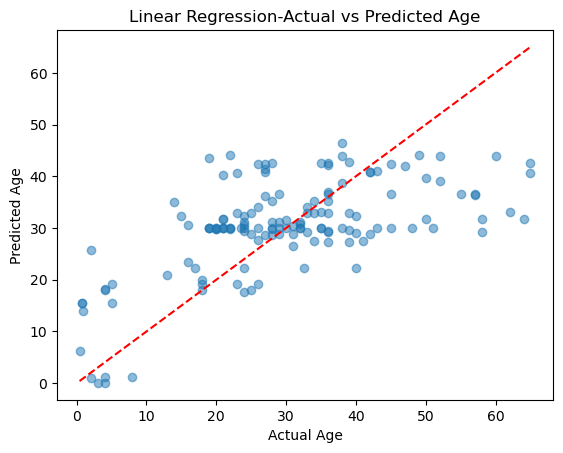

In [ ]:
# # 1. Create Fare_log
           
X_train_full = X_train_full.copy()
X_valid_full = X_valid_full.copy()

X_train_full["Fare_log"] = np.log1p(X_train_full["Fare"])
X_valid_full["Fare_log"] = np.log1p(X_valid_full["Fare"])


# 2. Define features

selected_features = ["Title", "Fare", "FamilySize", "Pclass"]

X_train_sel = X_train_full[selected_features].copy()
X_val_sel = X_valid_full[selected_features].copy()

y_train_aligned = y_train.loc[X_train_sel.index]
y_val_aligned = y_valid.loc[X_val_sel.index]


# 3. Define column types

numeric_cols = ["Fare", "FamilySize"]
onehot_cols = ["Title", "Pclass"]


# 4. Pipelines by variable types

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


# 5. Preprocessor

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("oh", onehot_pipeline, onehot_cols)
])


# 6. Final Pipeline with Linear Regression

model_lr = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])


# 7. Train model

model_lr.fit(X_train_sel, y_train_aligned)


# 8. Predictions

y_pred_lr = model_lr.predict(X_val_sel)


# 9. Metrics

mae = mean_absolute_error(y_val_aligned, y_pred_lr)
mse = mean_squared_error(y_val_aligned, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_val_aligned, y_pred_lr)

print("\n=== Detailed Linear Regression Summary ===")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


# 10. Predicted vs actual values

plt.scatter(y_val_aligned, y_pred_lr, alpha=0.5)
plt.plot(
    [y_val_aligned.min(), y_val_aligned.max()],
    [y_val_aligned.min(), y_val_aligned.max()],
    'r--'
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Linear Regression-Actual vs Predicted Age")
plt.show()

>In the tests conducted on the baseline Linear Regression model, performance was compared using the Fare variable and its logarithmic transformation, Fare_log. It was observed that the use of Fare_log leads to a slight improvement in performance metrics, namely a reduction in error (MAE and RMSE) and an increase in R².

>This improvement is due to the fact that the logarithmic transformation reduces skewness and the impact of outliers in the Fare variable, allowing the model to better capture its relationship with age. Therefore, Fare_log was chosen for use in subsequent versions of the model.